# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
#!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

In [19]:
!wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz

--2026-04-26 07:58:42--  http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘SUSY.csv.gz’

SUSY.csv.gz             [          <=>       ] 879.65M  4.66MB/s    in 2m 50s  

2026-04-26 08:01:48 (5.18 MB/s) - ‘SUSY.csv.gz’ saved [922377711]



In [2]:
#!rm SUSY.csv

In [20]:
!gunzip SUSY.csv.gz

In [22]:
ls -lh

total 2.3G
-rwxrwxrwx 1 fwakefield fwakefield 386K Apr 26 08:00 Lab.7.ipynb*
-rwxrwxrwx 1 fwakefield fwakefield 8.0M Apr 24 13:14 Lab.7.pdf*
-rwxrwxrwx 1 fwakefield fwakefield 2.3G Apr 26 08:01 SUSY.csv*


The data is provided as a comma separated file.

In [23]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [24]:
ls -lh

total 2.3G
-rwxrwxrwx 1 fwakefield fwakefield 386K Apr 26 08:02 Lab.7.ipynb*
-rwxrwxrwx 1 fwakefield fwakefield 8.0M Apr 24 13:14 Lab.7.pdf*
-rwxrwxrwx 1 fwakefield fwakefield 2.3G Apr 26 08:01 SUSY.csv*


We see that we have 5 million datapoints.

In [25]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [26]:
!head -500000 SUSY.csv > SUSY-small.csv

In [29]:
ls -lh

total 2.5G
-rwxrwxrwx 1 fwakefield fwakefield 386K Apr 26 08:02 Lab.7.ipynb*
-rwxrwxrwx 1 fwakefield fwakefield 8.0M Apr 24 13:14 Lab.7.pdf*
-rwxrwxrwx 1 fwakefield fwakefield 228M Apr 26 08:04 SUSY-small.csv*
-rwxrwxrwx 1 fwakefield fwakefield 2.3G Apr 26 08:01 SUSY.csv*


In [30]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [31]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [32]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [33]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [34]:
FeatureNames

['MET_rel',
 'dPhi_r_b',
 'axial_MET',
 'M_R',
 'M_TR_2',
 'R',
 'M_Delta_R',
 'cos_theta_r1',
 'MT2',
 'S_R']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [37]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [39]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [41]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


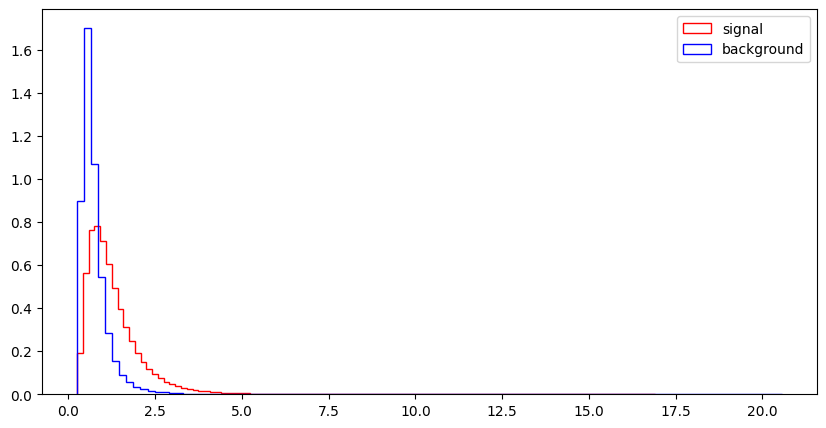

l_1_eta


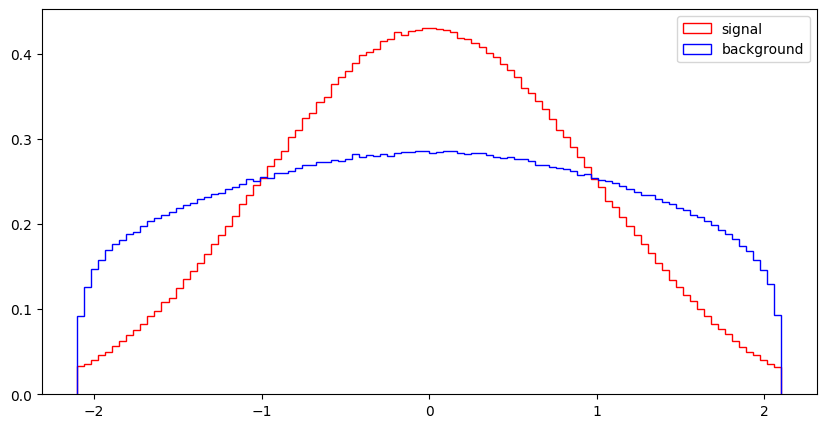

l_1_phi


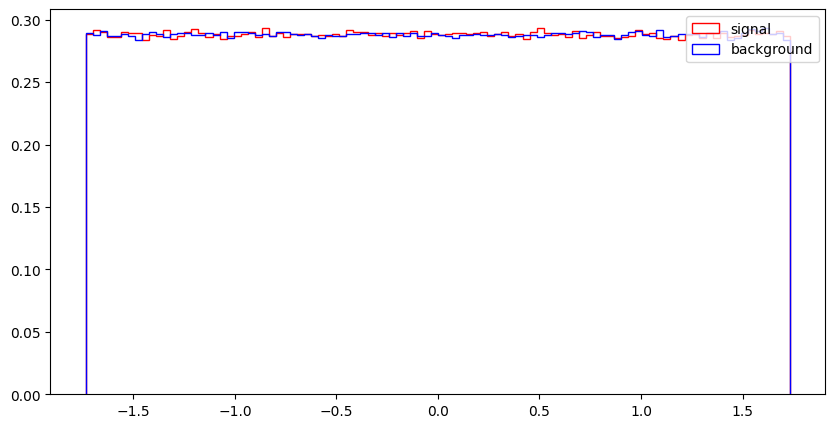

l_2_pT


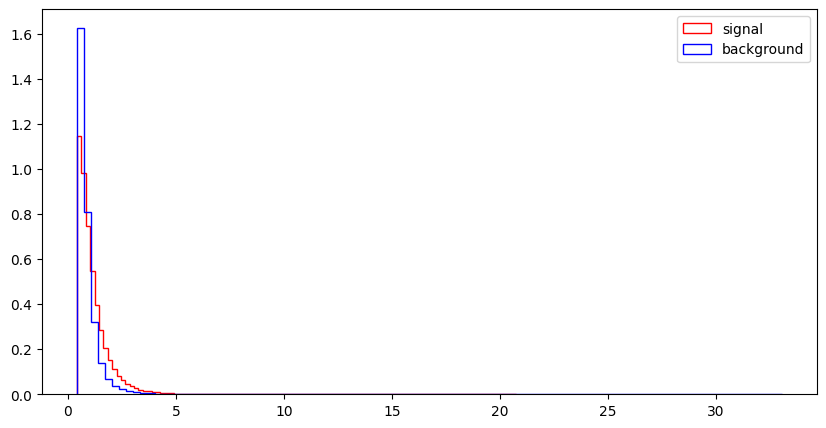

l_2_eta


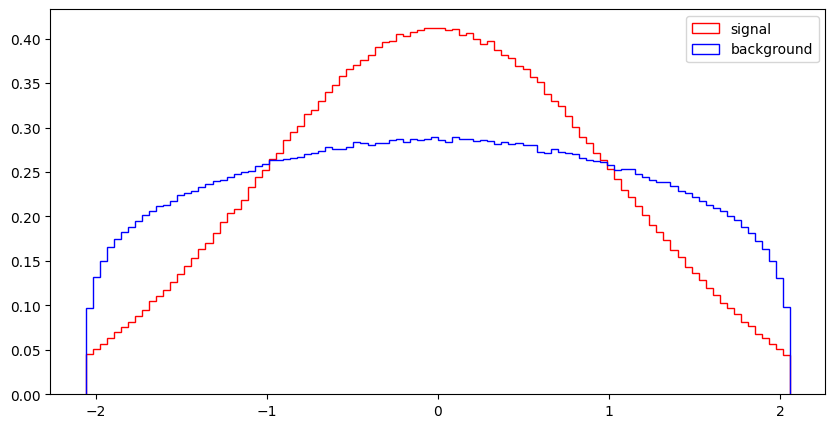

l_2_phi


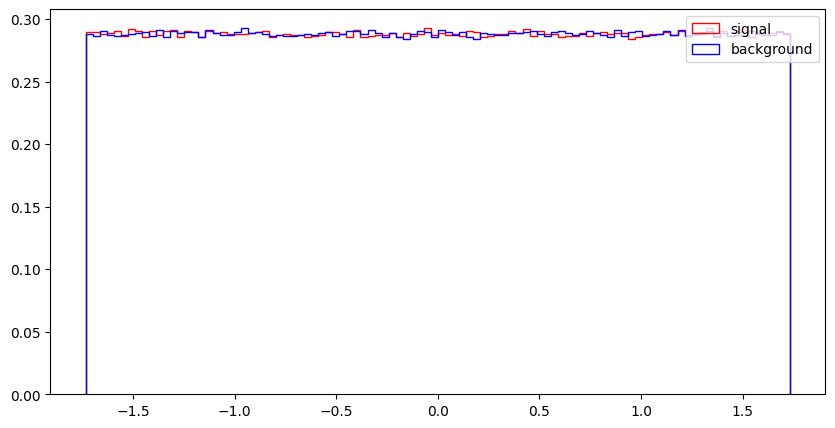

MET


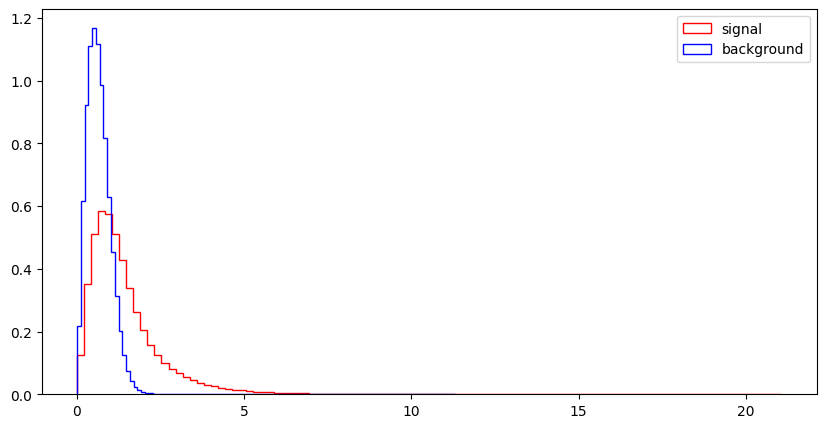

MET_phi


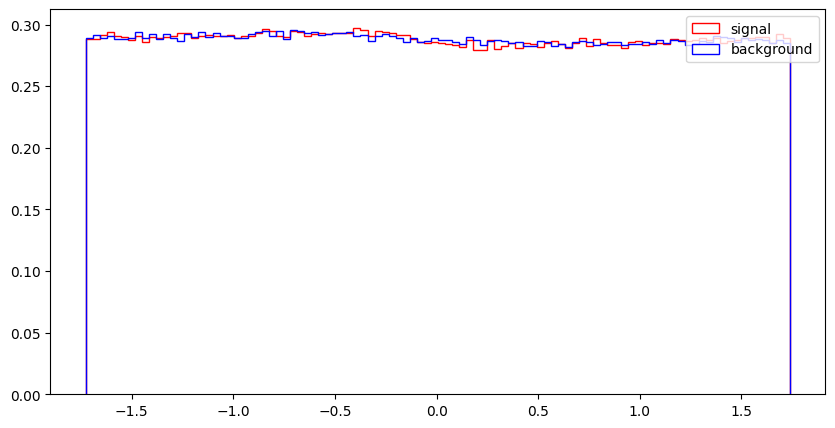

MET_rel


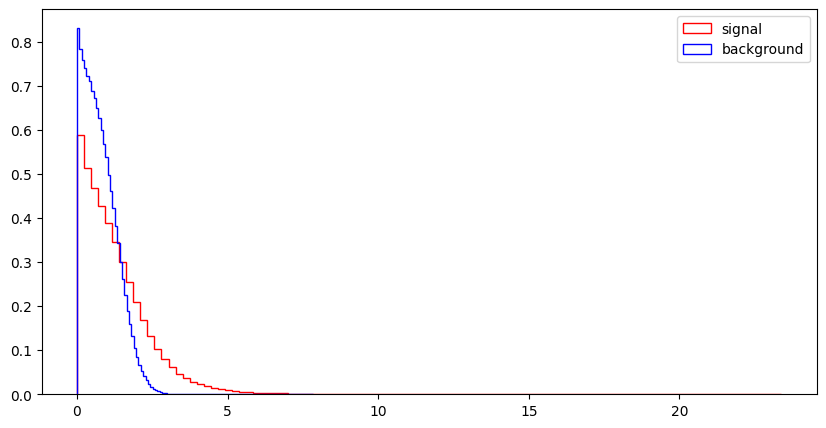

axial_MET


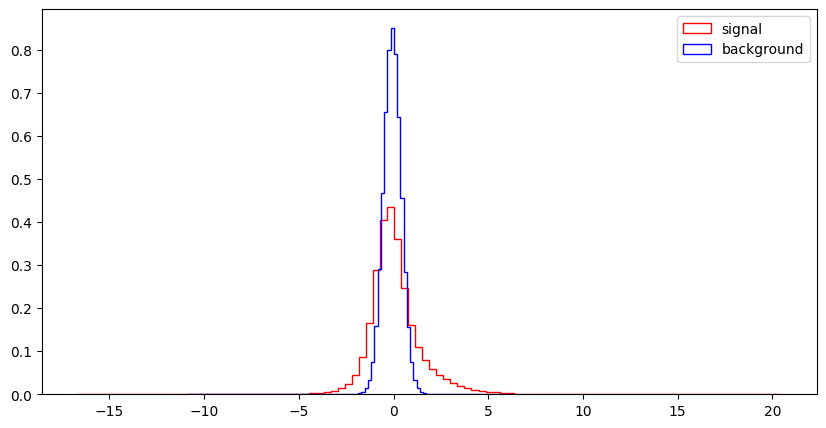

M_R


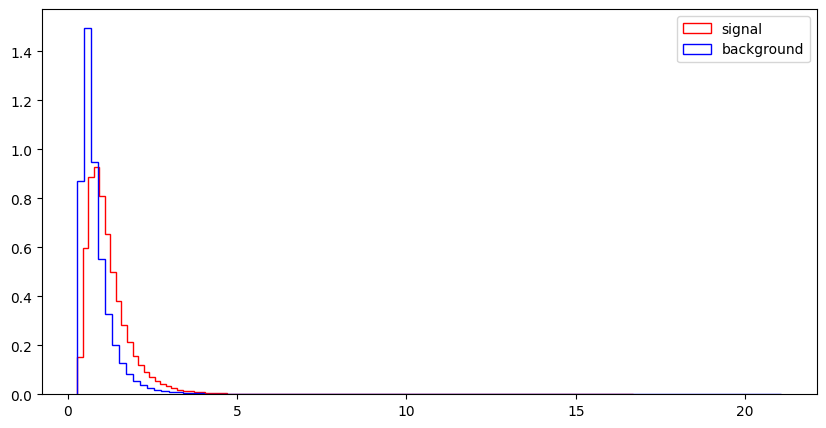

M_TR_2


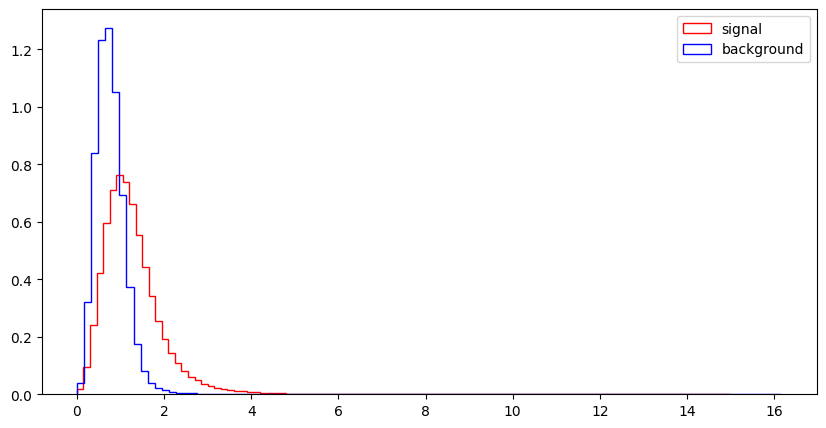

R


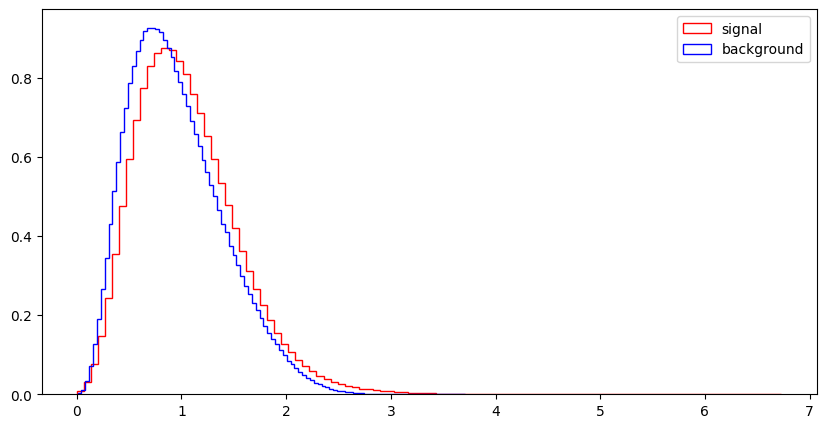

MT2


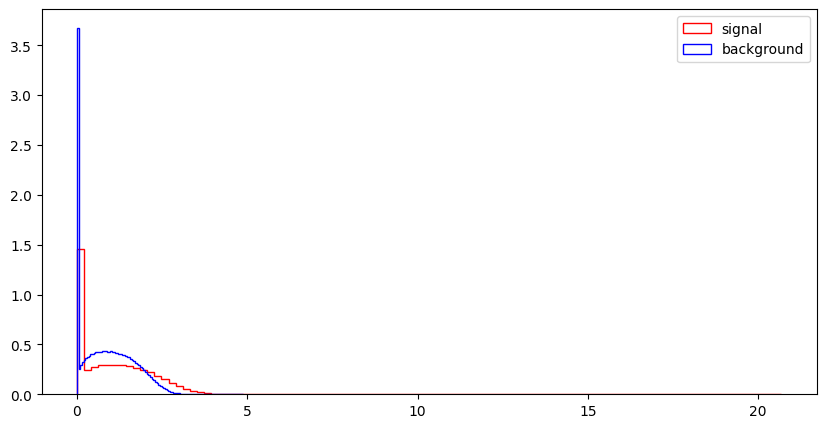

S_R


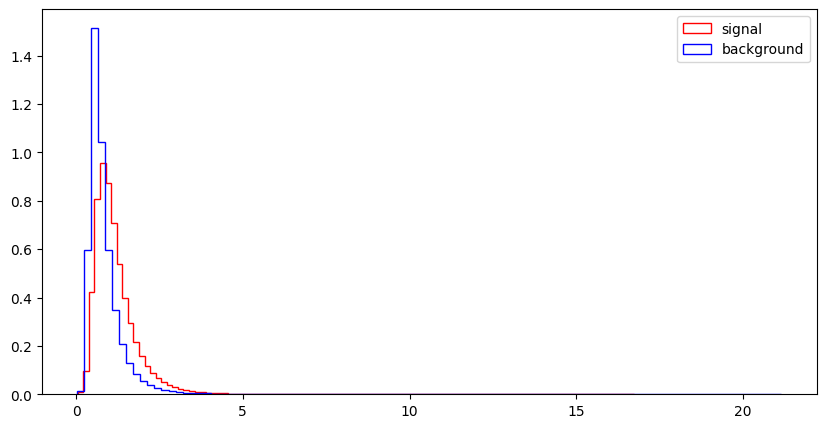

M_Delta_R


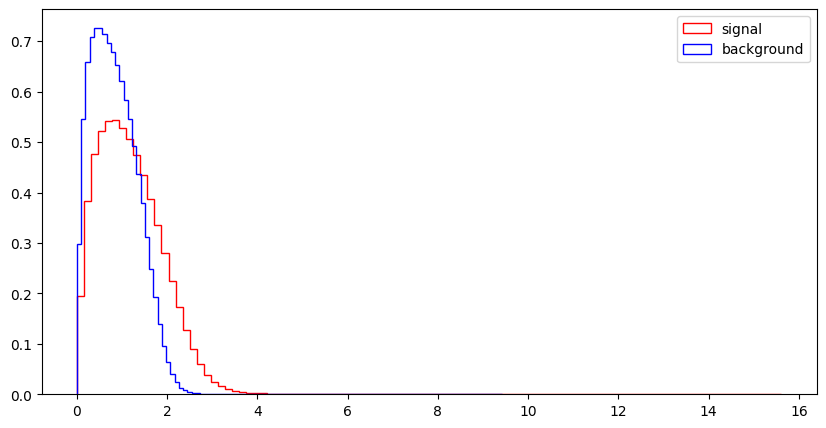

dPhi_r_b


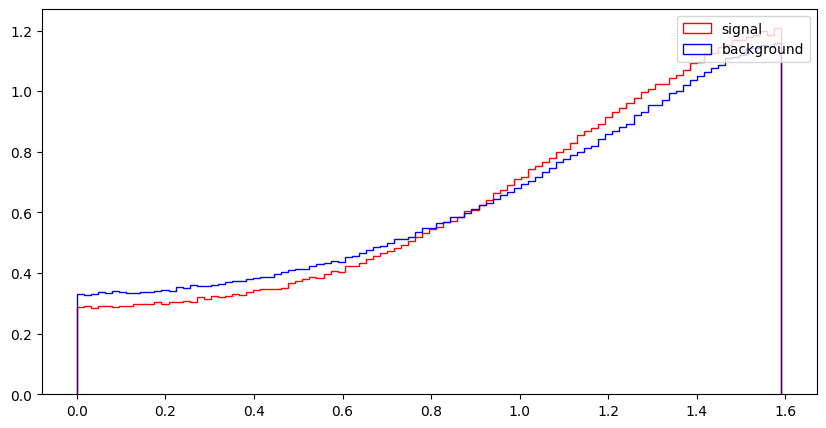

cos_theta_r1


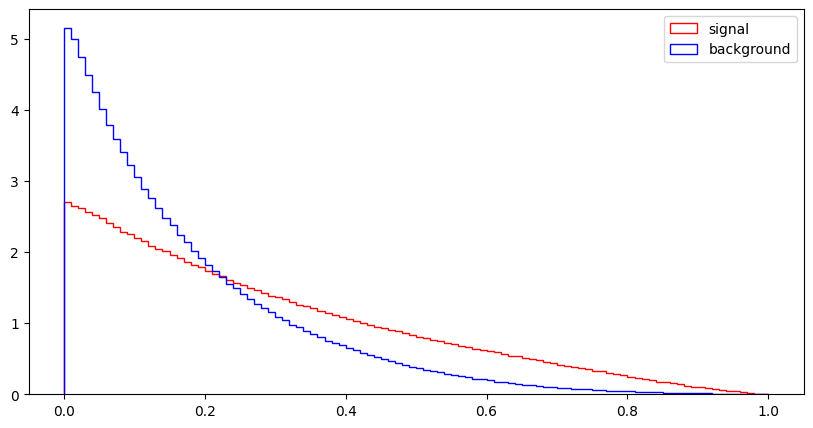

In [42]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

In [53]:
df.head()

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859


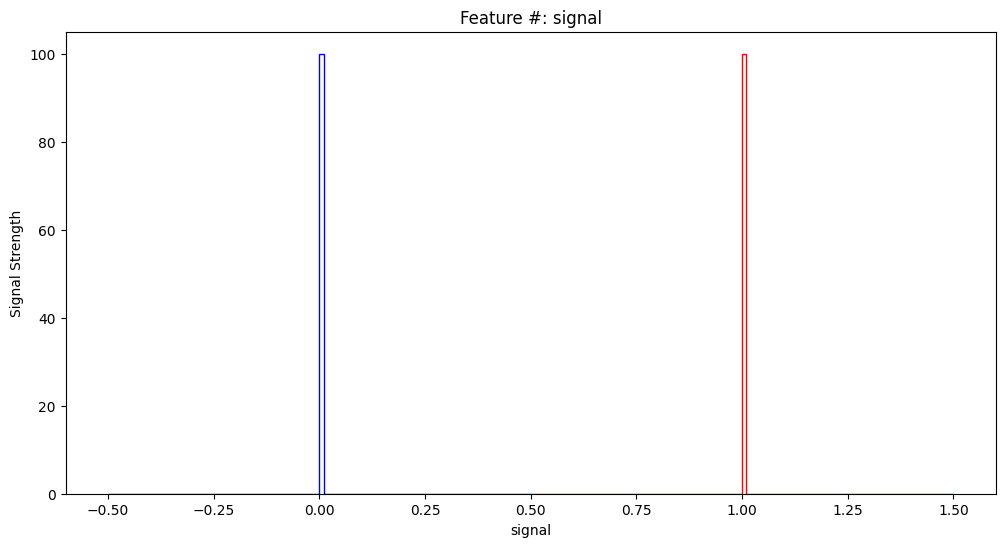

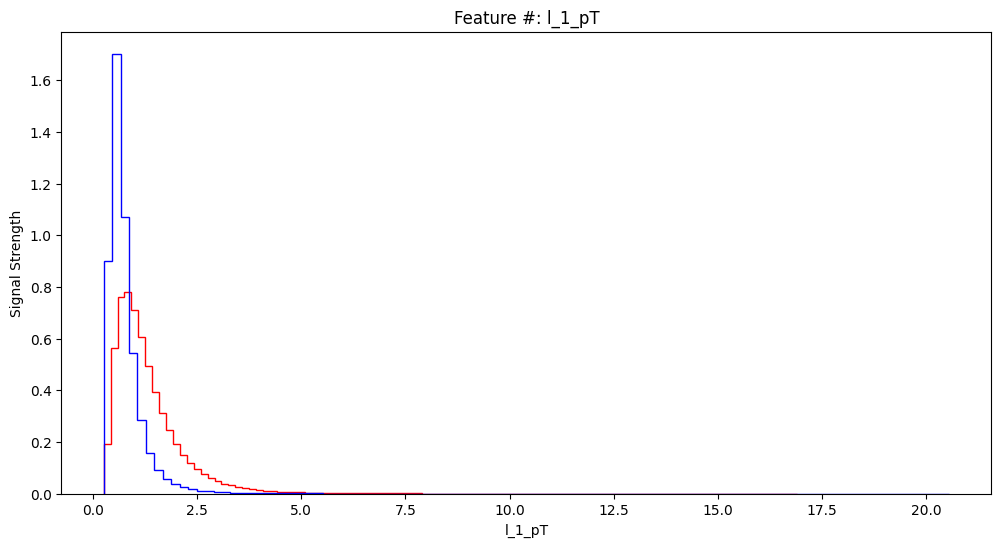

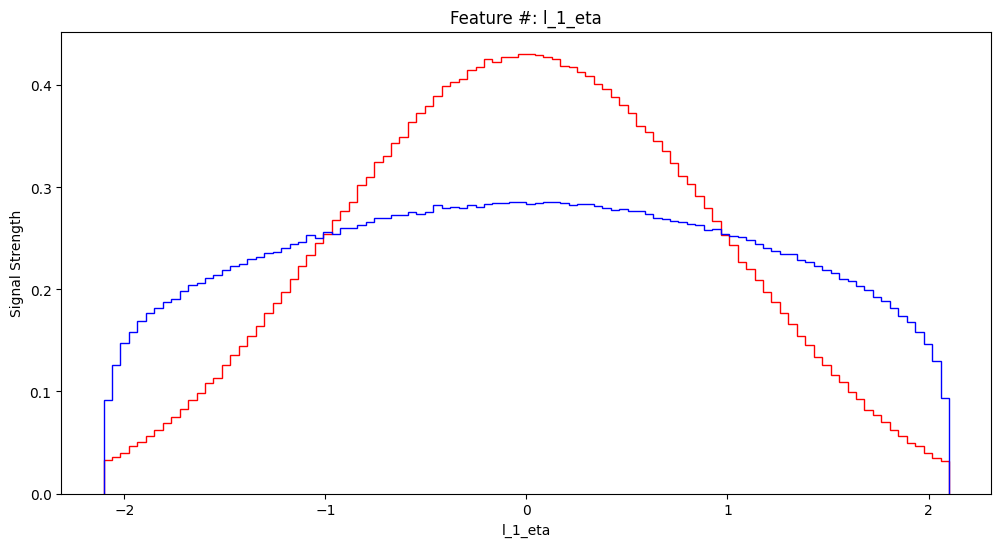

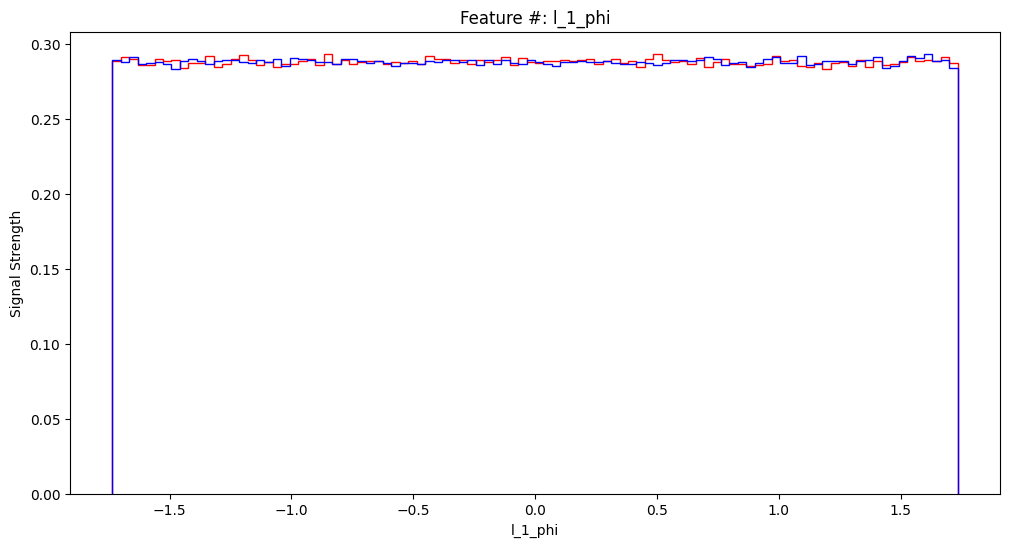

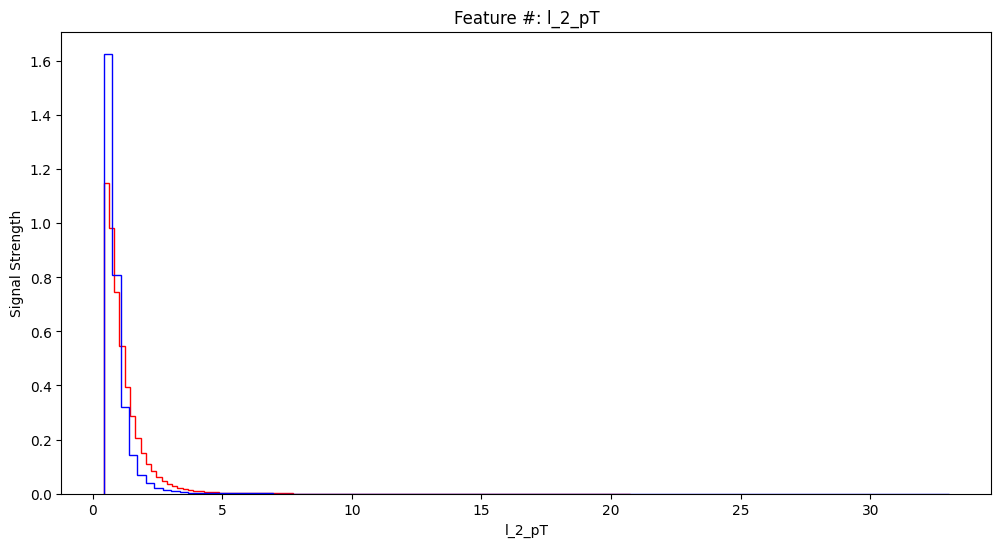

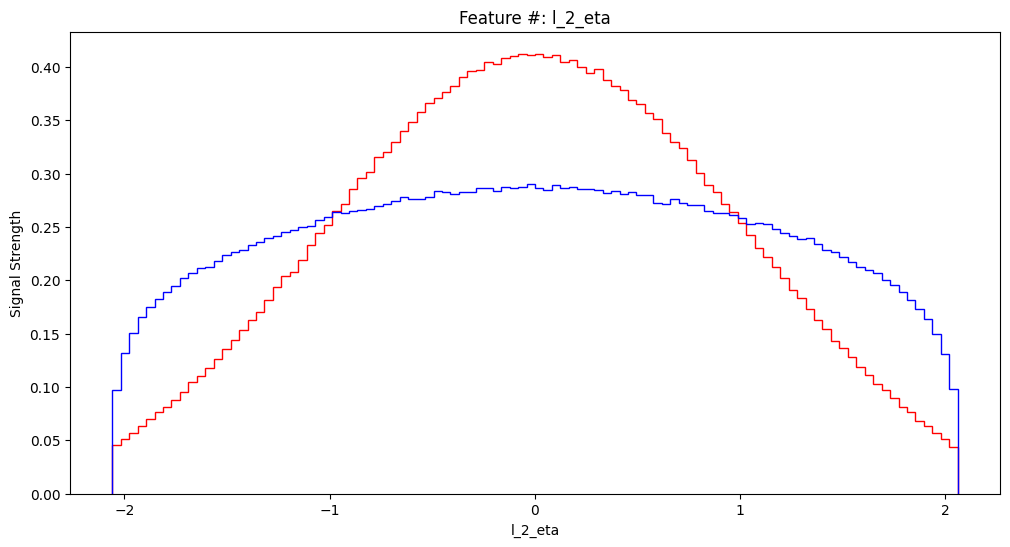

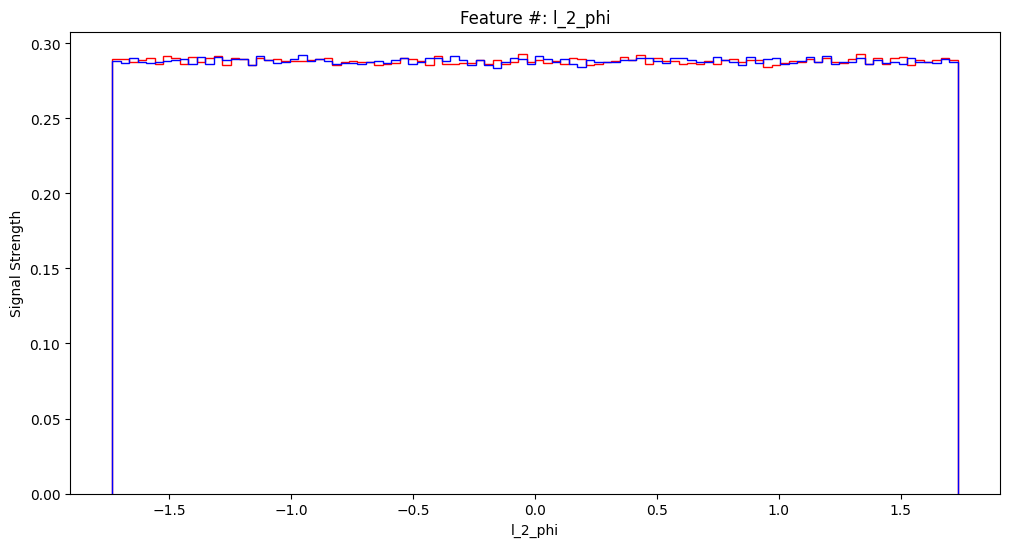

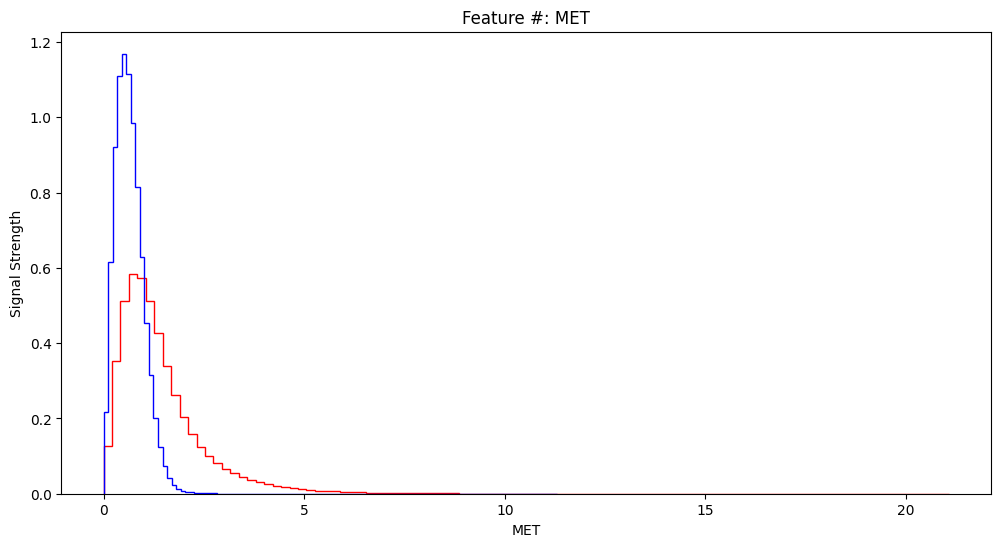

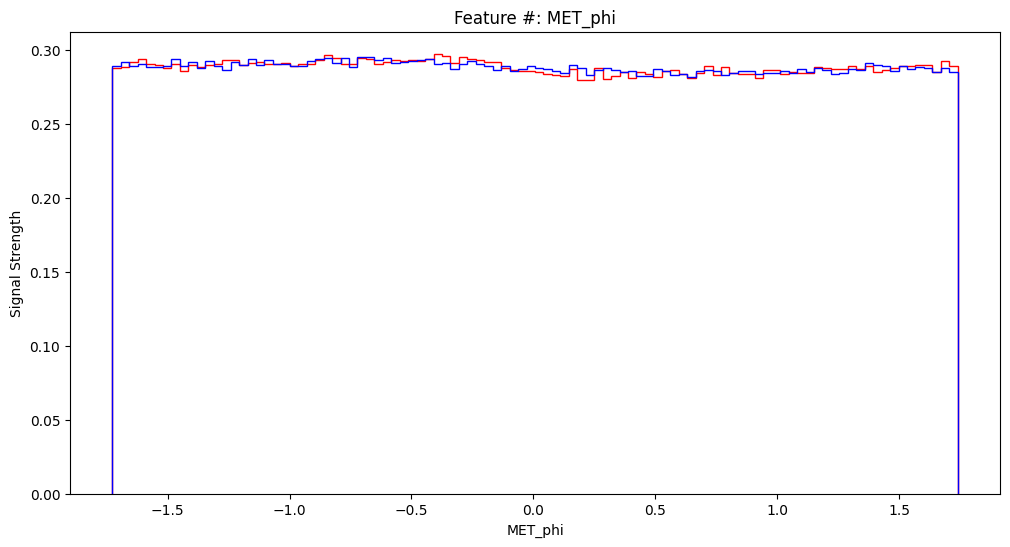

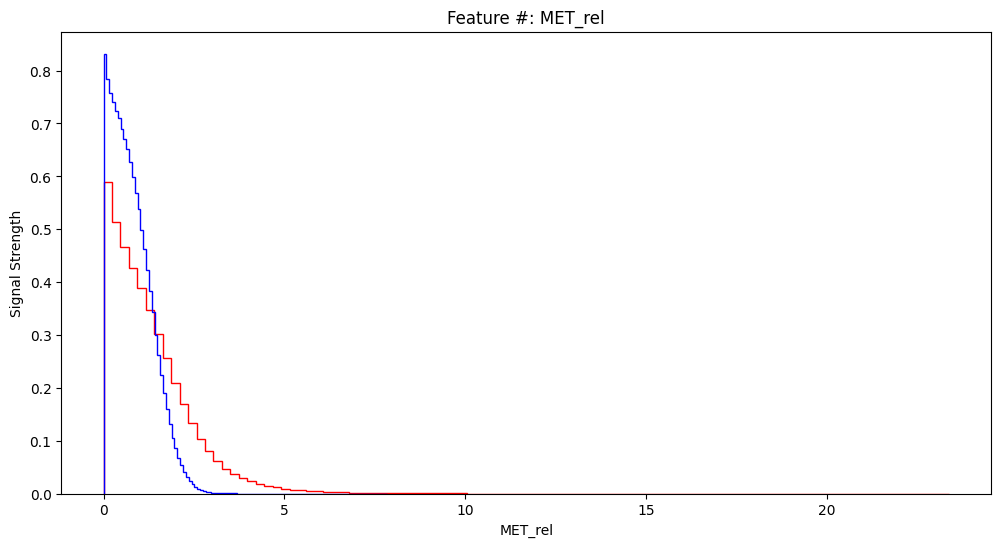

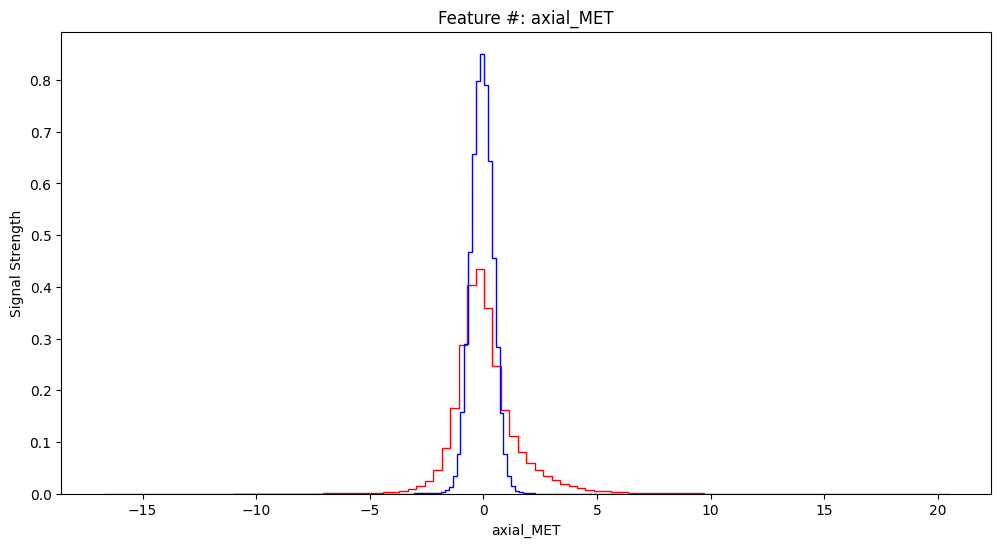

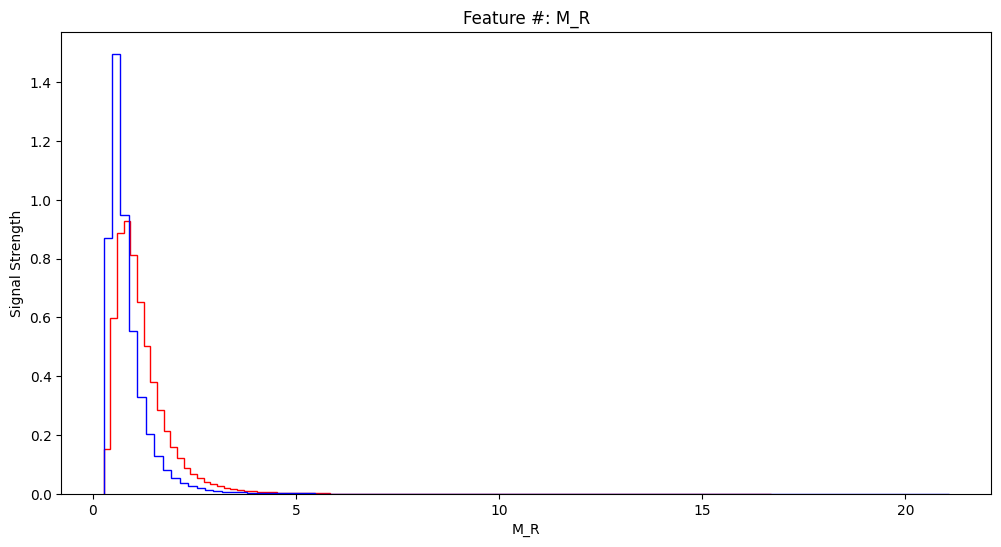

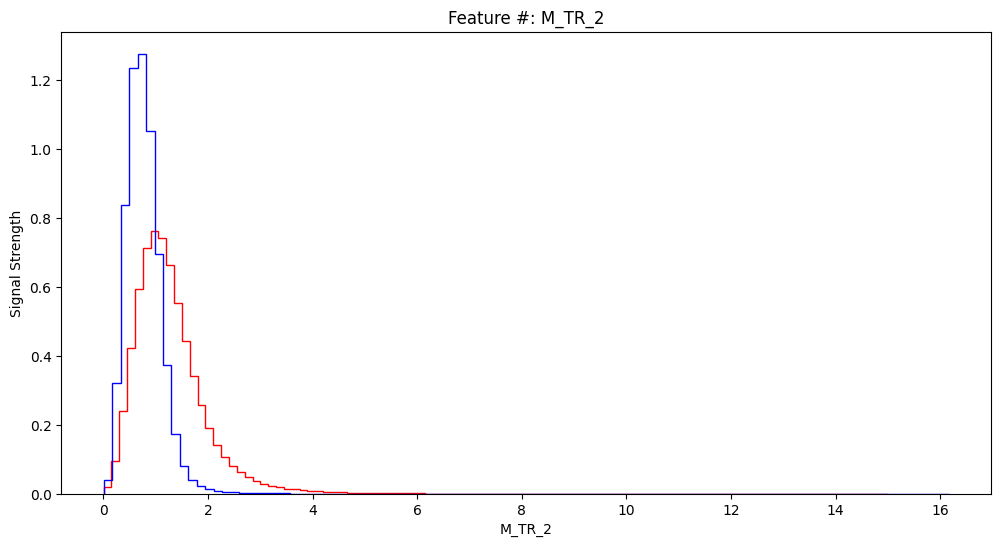

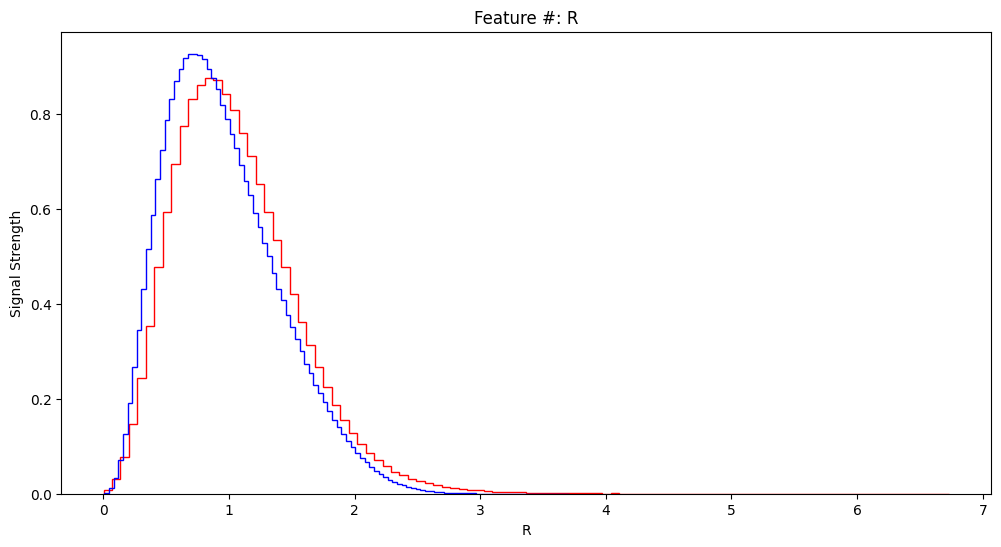

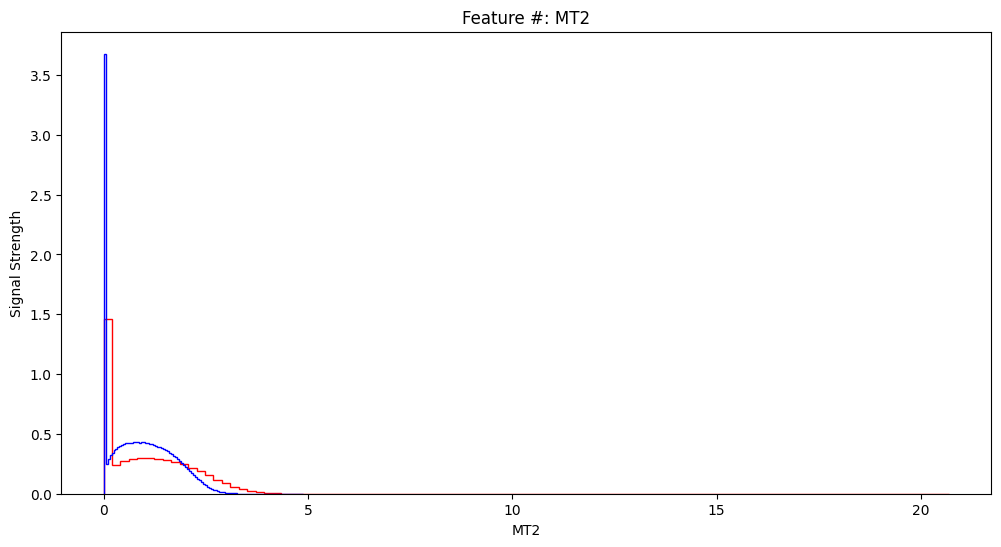

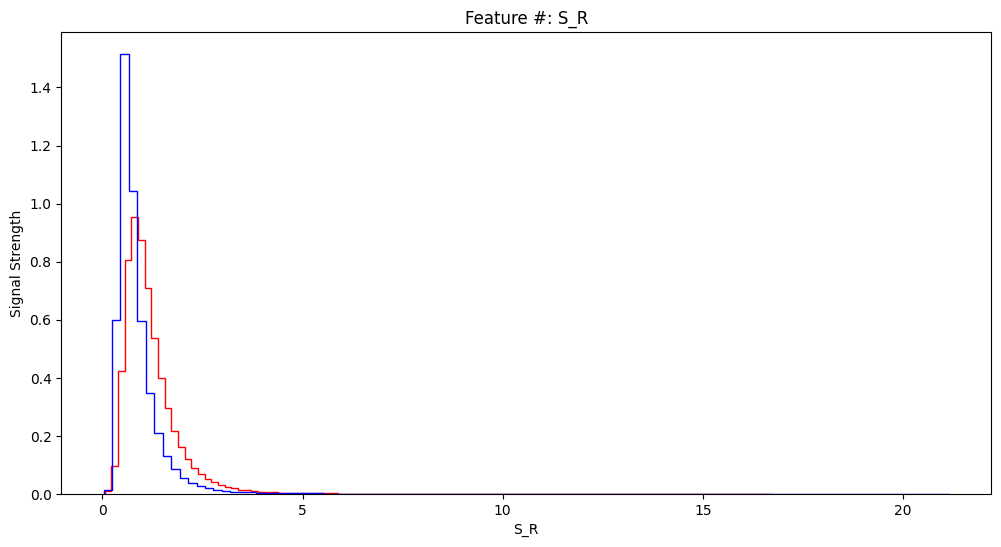

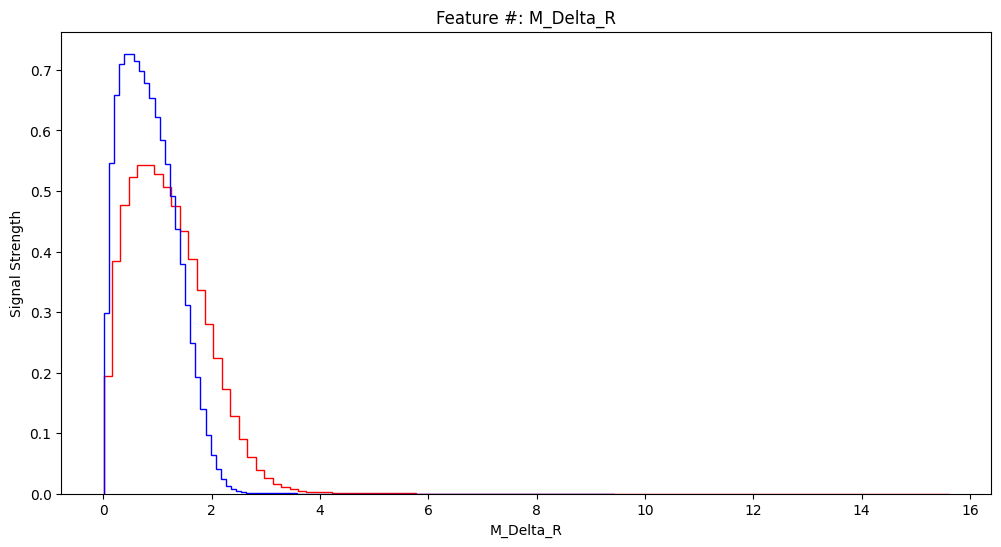

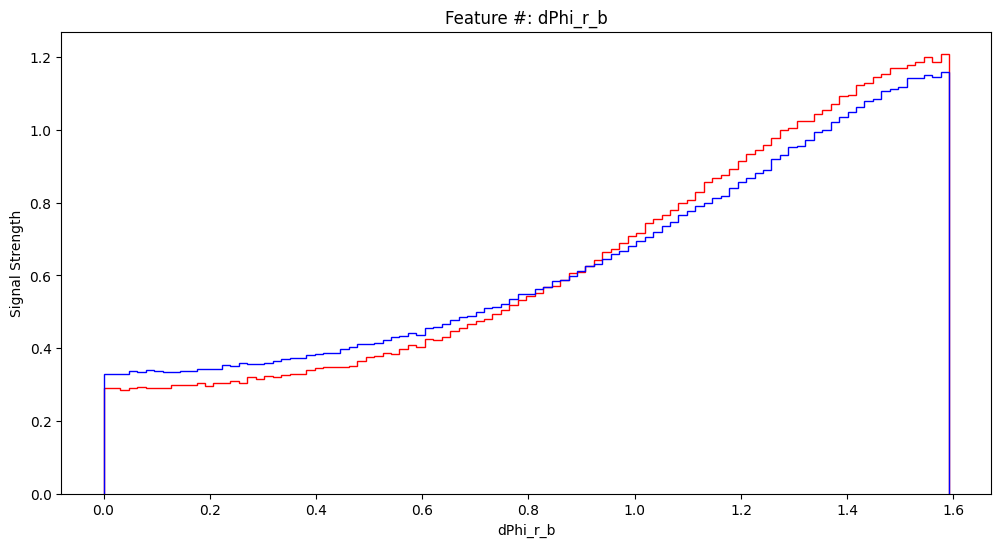

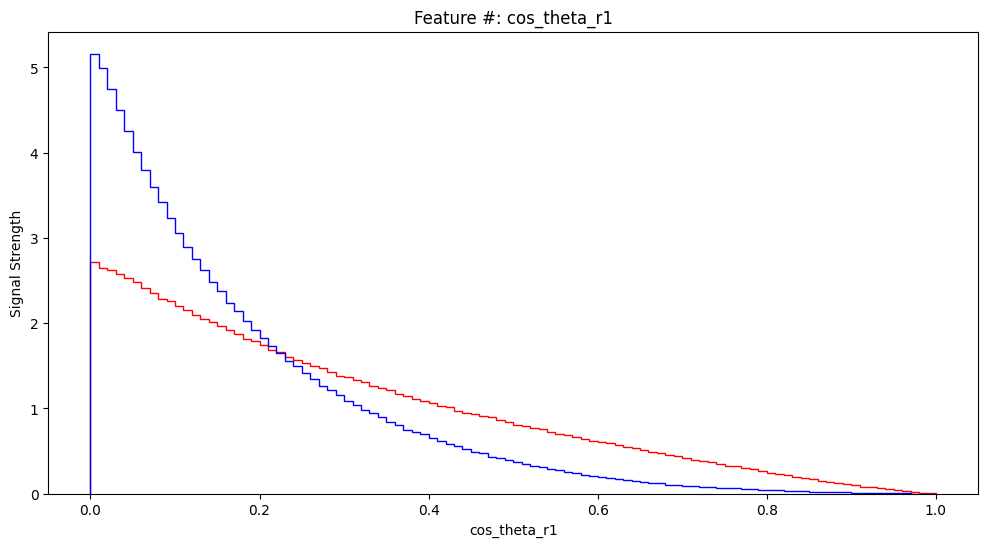

In [55]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]


for var in VarNames[1:]: # Skips the first column.
    plt.figure(figsize=(12,6)) # Creates the figure
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=True, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=True, stacked=True)
    plt.xlabel(var) # X-axis marked w/ variable name
    plt.ylabel("Signal Strength")
    plt.title(f"Feature #: {var}")
    plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

In [ ]:
Part A/B: I got stuck here so I asked chatGPT to help give me an outline.

In [ ]:
"How can i compare these variables in the SUSY sample here? Show & Explain how it would work." was the question i asked.

In [ ]:
This is where I got stuck.

In [ ]:
def pairplot(df, columns, title, sample_size=3000):
    # Use a sample so the plot runs faster
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=7)

    # Split the sample into signal and background
    signal = sample_df[sample_df["signal"] == 1]
    background = sample_df[sample_df["signal"] == 0]

    n = len(columns)
    plt.figure(figsize=(3*n, 3*n))

    plot_number = 1

    for row in range(n):
        for col in range(n):
            plt.subplot(n, n, plot_number)

In [ ]:
def pairplot(df, columns, title, sample_size=3000):
    """
    Creates a pair plot for a list of variables.

    A pair plot is an n by n grid of plots where n is the number of variables.
    - The diagonal plots show the 1D distribution of each variable.
    - The off-diagonal plots show relationships between pairs of variables.

    This version compares signal events and background events from the SUSY dataset.
    """

    # Randomly sample the dataframe before plotting.
    # This is the main speed improvement for Part B.
    #
    # The SUSY dataset can contain hundreds of thousands or millions of rows.
    # If we used the full dataframe, every scatter plot would try to draw every row.
    # Since a pair plot has n*n subplots, the cost grows quickly as the number of variables grows.
    #
    # Example:
    # If n = 4 variables, we make 16 subplots.
    # If n = 8 variables, we make 64 subplots.
    #
    # Sampling reduces the number of points drawn in each subplot from len(df) to sample_size.
    # random_state=7 makes the random sample reproducible, so the plot looks the same each run.
    # min(sample_size, len(df)) prevents an error if the dataframe has fewer rows than sample_size.
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=7)

    # Split the sampled data into signal and background events.
    #
    # In this dataset, the "signal" column is the truth label:
    # signal == 1 means the event is signal.
    # signal == 0 means the event is background.
    #
    # Splitting the data lets us draw signal and background separately on each plot,
    # which is necessary for comparing how well variables separate the two classes.
    signal = sample_df[sample_df["signal"] == 1]
    background = sample_df[sample_df["signal"] == 0]

    # n is the number of variables being compared.
    # The pair plot will contain n rows and n columns of subplots.
    n = len(columns)

    # Create the full figure.
    # The figure size scales with n so larger variable lists get more plotting space.
    plt.figure(figsize=(3*n, 3*n))

    # Matplotlib subplot numbering starts at 1, not 0.
    # This counter tracks the current subplot position in the n by n grid.
    plot_number = 1

    # Loop over the rows of the pair plot.
    # Each row corresponds to a y-axis variable.
    for row in range(n):

        # Loop over the columns of the pair plot.
        # Each column corresponds to an x-axis variable.
        for col in range(n):

            # Create the next subplot in the grid.
            # plt.subplot(n, n, plot_number) means:
            # - n rows
            # - n columns
            # - activate subplot number plot_number
            plt.subplot(n, n, plot_number)

            # Pick the variable for the x-axis from the column index.
            x_col = columns[col]

            # Pick the variable for the y-axis from the row index.
            y_col = columns[row]

            # The diagonal positions are where row == col.
            # That means the same variable is on the x-axis and y-axis.
            #
            # Instead of plotting a variable against itself, we plot a histogram.
            # This shows the 1D distribution of that variable for signal and background.
            if row == col:
                plt.hist(
                    signal[x_col],
                    bins=40,          # Number of intervals used to group the data
                    density=True,     # Normalize area so signal/background shapes can be compared
                    alpha=0.5,        # Transparency so overlapping histograms are visible
                    label="signal"
                )

                plt.hist(
                    background[x_col],
                    bins=40,
                    density=True,
                    alpha=0.5,
                    label="background"
                )

                # Add a legend so we know which histogram is signal and background.
                plt.legend()

            # Off-diagonal positions are where row != col.
            # These compare two different variables using a scatter plot.
            #
            # Each point is one collision event.
            # The x-coordinate is one variable and the y-coordinate is another variable.
            # If signal and background occupy different regions, those variables may be useful.
            else:
                plt.scatter(
                    signal[x_col],
                    signal[y_col],
                    s=2,              # Small marker size because there are many points
                    alpha=0.25,       # Transparency reduces overplotting
                    label="signal"
                )

                plt.scatter(
                    background[x_col],
                    background[y_col],
                    s=2,
                    alpha=0.25,
                    label="background"
                )

            # Only label x-axes on the bottom row.
            #
            # Without this, every subplot would have x-axis labels,
            # which would make the grid crowded and difficult to read.
            if row == n - 1:
                plt.xlabel(x_col)
            else:
                plt.xticks([])

            # Only label y-axes on the leftmost column.
            #
            # This keeps the plot readable while still showing which variables
            # correspond to each row and column.
            if col == 0:
                plt.ylabel(y_col)
            else:
                plt.yticks([])

            # Move to the next subplot position.
            plot_number += 1

    # Add one overall title for the whole pair plot.
    plt.suptitle(title)

    # Automatically adjust spacing so labels and subplots do not overlap.
    plt.tight_layout()

    # Display the completed figure.
    plt.show()

In [ ]:
This is my code after.

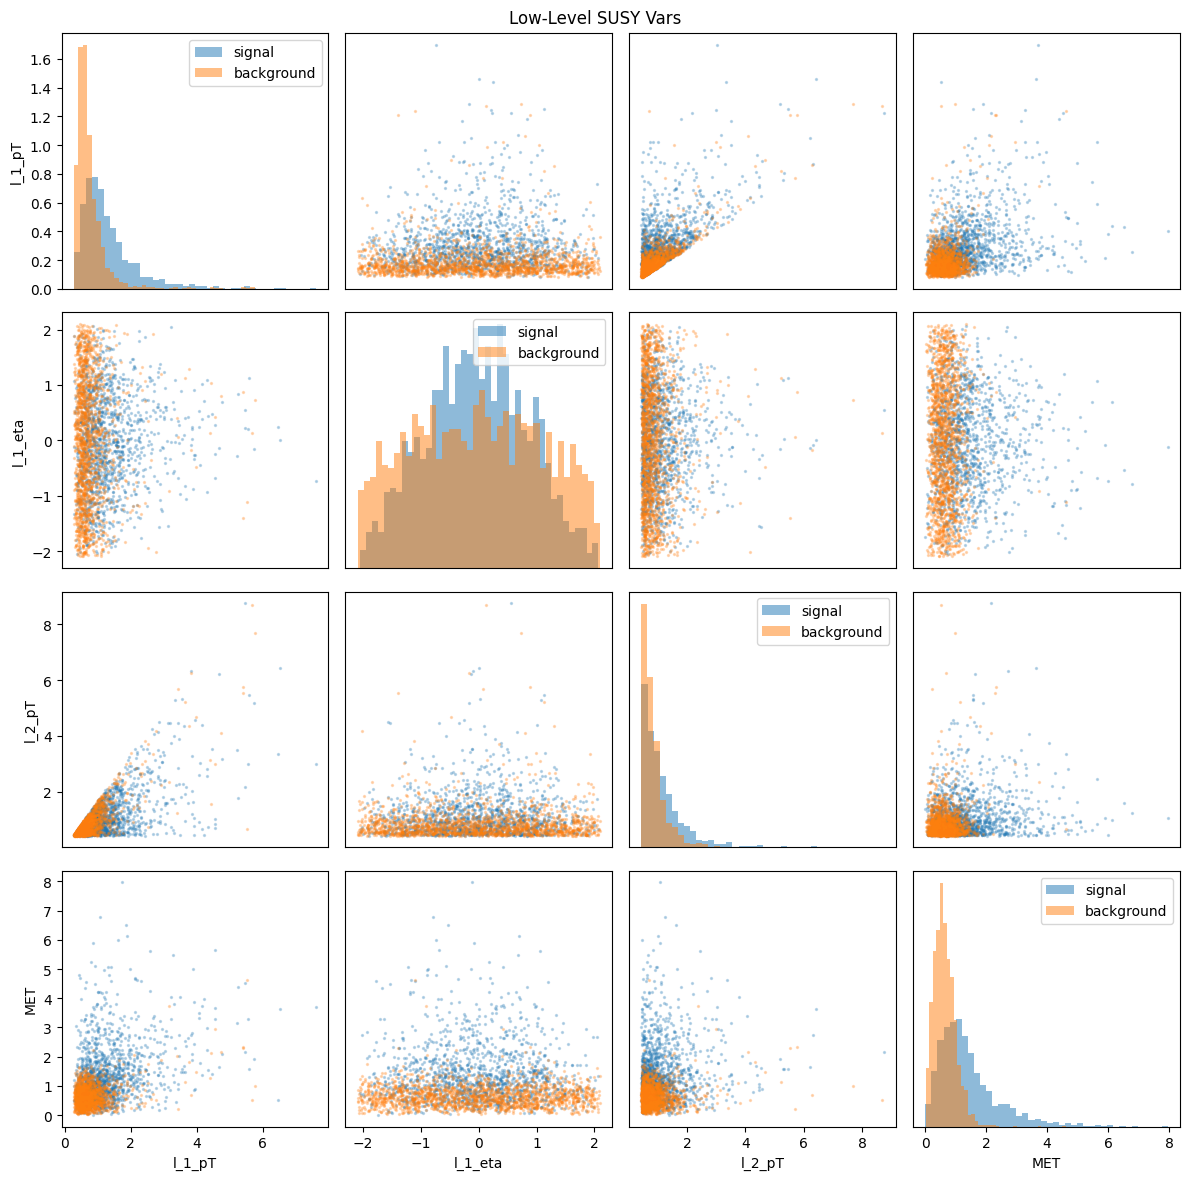

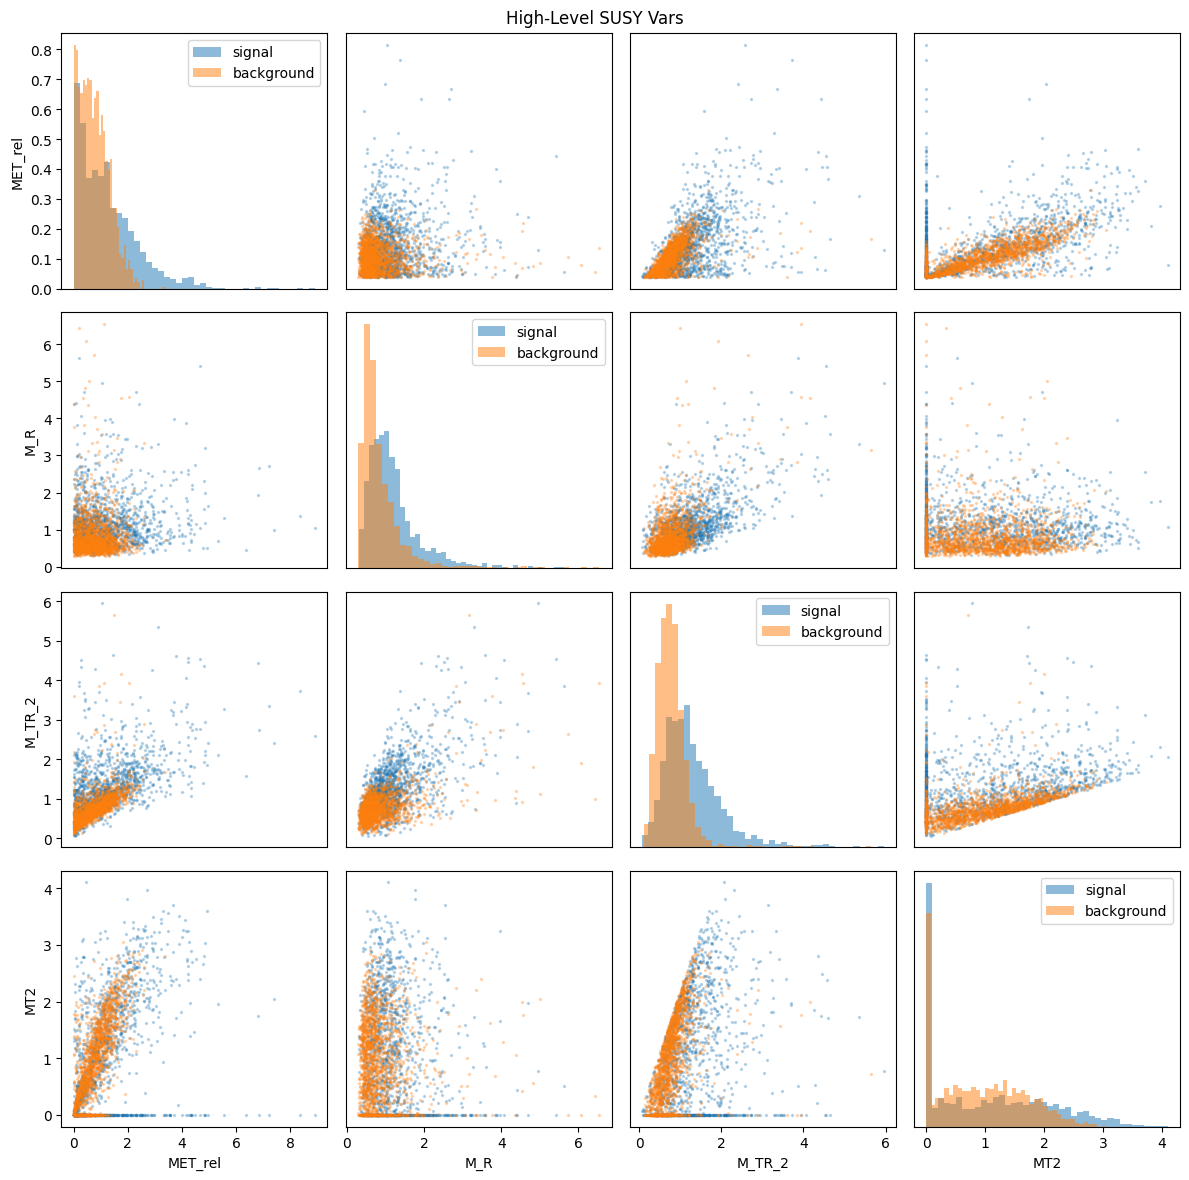

In [58]:
def pairplot(df, columns, title, sample_size=3000):
    # Use a sample so the plot runs faster
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=7)

    # Split the sample into signal and background
    signal = sample_df[sample_df["signal"] == 1]
    background = sample_df[sample_df["signal"] == 0]

    n = len(columns)
    plt.figure(figsize=(3*n, 3*n))

    plot_number = 1

    for row in range(n):
        for col in range(n):
            plt.subplot(n, n, plot_number)

            x_col = columns[col]
            y_col = columns[row]

            # Diagonal: histogram
            if row == col:
                plt.hist(signal[x_col], bins=40, density=True, alpha=0.5, label="signal")
                plt.hist(background[x_col], bins=40, density=True, alpha=0.5, label="background")
                plt.legend()

            # Off-diagonal: scatter plot
            else:
                plt.scatter(signal[x_col], signal[y_col], s=2, alpha=0.25, label="signal")
                plt.scatter(background[x_col], background[y_col], s=2, alpha=0.25, label="background")

            # Only label the outside edges
            if row == n - 1:
                plt.xlabel(x_col)
            else:
                plt.xticks([])

            if col == 0:
                plt.ylabel(y_col)
            else:
                plt.yticks([])

            plot_number += 1

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

low_level = ["l_1_pT", "l_1_eta", "l_2_pT", "MET"]
high_level = ["MET_rel", "M_R", "M_TR_2", "MT2"]

pairplot(df, low_level, "Low-Level SUSY Vars")
pairplot(df, high_level, "High-Level SUSY Vars")

In [ ]:
I learned that high-level features tend to be more useful to classify things than some of the raw variables, because their signal and background distributions overlap less.
I also learned how to separate the dataframe into signal and background rows using the label column.

In [ ]:
Part C: Which observables appear to be best for separating signal from background? 

The features from the high level observables look like they are better for separating signal from the background noise than the low level ones.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [ ]:
Part a
(.venv) fwakefield@VersasykPC:/mnt/c/Users/Francis/Desktop/data3402/DATA3402.Spring.2026/Labs$ pip install tabulate
Collecting tabulate
  Downloading tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
Downloading tabulate-0.10.0-py3-none-any.whl (39 kB)
Installing collected packages: tabulate
Successfully installed tabulate-0.10.0
(.venv) fwakefield@VersasykPC:/mnt/c/Users/Francis/Desktop/data3402/DATA3402.Spring.2026/Labs$

Hint: Example code for embedding a `tabulate` table into a notebook:

In [ ]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

In [ ]:
I also got stuck here. I used ChatGPT for this as well.

My question was: "How do I use Numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.? And can you show me an example on how to do this? and explain it to me?"

In [ ]:
This is what ChatGPT output

In [ ]:
# Import NumPy for numerical calculations like covariance and correlation
import numpy as np

# Import pandas so we can turn the NumPy matrices back into labeled tables
import pandas as pd

# Import tabulate so the output tables look cleaner in the notebook
import tabulate

# Import display tools so tabulate can be shown as an HTML table in Jupyter
from IPython.display import HTML, display


def show_matrices(df, variables, title):
    """
    Compute and display the covariance and correlation matrices
    for a selected group of variables.

    Parameters:
        df:
            The full pandas dataframe holding the SUSY data.

        variables:
            A list of column names we want to analyze.

        title:
            A title used when printing the tables.

    Returns:
        cov_df:
            A labeled pandas dataframe containing the covariance matrix.

        corr_df:
            A labeled pandas dataframe containing the correlation matrix.
    """

    # Select only the columns we want from the dataframe.
    # For example, variables might be RawNames, FeatureNames, or VarNames[1:].
    #
    # df[variables] gives us only those selected columns.
    # .to_numpy() converts the pandas dataframe into a NumPy array.
    #
    # The original shape is:
    #     rows = collision events
    #     columns = observables
    #
    # NumPy's np.cov() and np.corrcoef() expect:
    #     rows = variables
    #     columns = observations
    #
    # So we use .T to transpose the array.
    data = df[variables].to_numpy().T

    # Compute the covariance matrix.
    #
    # Covariance tells us whether two variables tend to move together.
    # A positive covariance means they tend to increase together.
    # A negative covariance means one tends to decrease as the other increases.
    # A value near zero means there is not much linear relationship.
    cov = np.cov(data)

    # Compute the correlation matrix.
    #
    # Correlation is like covariance, but normalized.
    # This makes it easier to compare because values are always between -1 and 1.
    #
    #  1 means strong positive relationship.
    #  0 means little or no linear relationship.
    # -1 means strong negative relationship.
    corr = np.corrcoef(data)

    # Convert the covariance matrix into a pandas dataframe.
    #
    # This adds variable names as row and column labels.
    # Without this, the matrix would just be numbers with no labels.
    #
    # .round(3) keeps only 3 decimal places so the table is readable.
    cov_df = pd.DataFrame(
        cov,
        index=variables,
        columns=variables
    ).round(3)

    # Do the same thing for the correlation matrix.
    corr_df = pd.DataFrame(
        corr,
        index=variables,
        columns=variables
    ).round(3)

    # Print a title for the covariance matrix.
    print(title + ": Covariance Matrix")

    # Use tabulate to display the covariance dataframe as an HTML table.
    # headers="keys" means use the dataframe column names as table headers.
    # showindex=True means show the row labels.
    display(
        HTML(
            tabulate.tabulate(
                cov_df,
                headers="keys",
                tablefmt="html",
                showindex=True
            )
        )
    )

    # Print a title for the correlation matrix.
    print(title + ": Correlation Matrix")

    # Display the correlation dataframe as an HTML table.
    display(
        HTML(
            tabulate.tabulate(
                corr_df,
                headers="keys",
                tablefmt="html",
                showindex=True
            )
        )
    )

    # Return both dataframes in case we want to use them later.
    return cov_df, corr_df

In [ ]:
And here is my code after.

In [62]:
import numpy as np
import pandas as pd
import tabulate
from IPython.display import HTML, display

def show_matrix(df, variables, title):
    data = df[variables].to_numpy().T
    cov = np.cov(data)
    corr = np.corrcoef(data)

    # Put matrices into labeled dataframes and round them
    cov_df = pd.DataFrame(cov, index=variables, columns=variables).round(3)
    corr_df = pd.DataFrame(corr, index=variables, columns=variables).round(3)

    # Display covariance table
    print(title + ": Covariance Matrix")
    display(HTML(tabulate.tabulate(cov_df, headers="keys", tablefmt="html", showindex=True)))

    # Display correlation table
    print(title + ": Correlation Matrix")
    display(HTML(tabulate.tabulate(corr_df, headers="keys", tablefmt="html", showindex=True)))

    return cov_df, corr_df

all_observables = VarNames[1:]

cov_all, corr_all = show_matrix(df, all_observables, "All Observables")
cov_raw, corr_raw = show_matrix(df, RawNames, "Raw Variables")
cov_features, corr_features = show_matrix(df, FeatureNames, "High-Level Features")

All Observables: Covariance Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.472,-0,-0,0.308,-0,0,0.231,-0.001,0.099,-0.013,0.368,0.291,-0.059,-0.013,0.346,0.098,-0.047,0.023
l_1_eta,-0,1.006,0,-0,0.406,0,-0.001,-0.001,-0,-0,-0,-0,0,-0,-0,-0.001,0,0
l_1_phi,-0,0,1.003,-0,0.001,-0.268,0.001,-0.184,0.002,-0.002,-0,0.001,0.001,0.002,0,0.001,0.001,0
l_2_pT,0.308,-0,-0,0.428,-0,0,0.08,-0.001,-0.002,0.05,0.328,0.164,-0.099,-0.069,0.325,0.006,-0.004,-0.028
l_2_eta,-0,0.406,0.001,-0,1.006,-0,0,-0,0,-0,-0.001,-0,0,-0,-0.001,-0,-0,0
l_2_phi,0,0,-0.268,0,-0,1.003,0,-0.034,0,-0,0,0,0,0.001,0,0,0,-0
MET,0.231,-0.001,0.001,0.08,0,0,0.762,-0.002,0.548,0.145,0.146,0.368,0.189,0.156,0.167,0.317,0.145,0.073
MET_phi,-0.001,-0.001,-0.184,-0.001,-0,-0.034,-0.002,1.003,-0.003,-0.001,-0.001,-0.001,-0,0.001,-0.001,-0,-0.001,0
MET_rel,0.099,-0,0.002,-0.002,0,0,0.548,-0.003,0.792,-0.125,0.044,0.303,0.25,0.41,0.082,0.416,0.147,0.056
axial_MET,-0.013,-0,-0.002,0.05,-0,-0,0.145,-0.001,-0.125,1.003,0.015,-0.189,-0.182,-0.46,-0.043,-0.234,-0.026,-0.054


All Observables: Correlation Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0,-0,0.685,-0,0,0.385,-0.001,0.161,-0.018,0.852,0.724,-0.183,-0.022,0.812,0.229,-0.157,0.166
l_1_eta,-0,1,0,-0.001,0.403,0,-0.001,-0.001,-0.001,-0,-0,-0,0,-0,-0,-0.001,0,0.001
l_1_phi,-0,0,1,-0,0.001,-0.267,0.001,-0.184,0.002,-0.002,-0,0.001,0.002,0.002,0,0.002,0.002,0.002
l_2_pT,0.685,-0.001,-0,1,-0.001,0,0.14,-0.002,-0.004,0.076,0.798,0.43,-0.322,-0.123,0.799,0.014,-0.014,-0.216
l_2_eta,-0,0.403,0.001,-0.001,1,-0,0,-0,0,-0,-0.001,-0,0.001,-0,-0.001,-0,-0,0.001
l_2_phi,0,0,-0.267,0,-0,1,0,-0.034,0,-0,0,0,0,0.001,0.001,0.001,0.001,-0.001
MET,0.385,-0.001,0.001,0.14,0,0,1,-0.002,0.706,0.166,0.266,0.722,0.459,0.209,0.309,0.581,0.382,0.426
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.034,-0.002,1,-0.003,-0.001,-0.002,-0.001,-0,0.001,-0.002,-0.001,-0.003,0
MET_rel,0.161,-0.001,0.002,-0.004,0,0,0.706,-0.003,1,-0.141,0.078,0.583,0.595,0.536,0.149,0.749,0.378,0.317
axial_MET,-0.018,-0,-0.002,0.076,-0,-0,0.166,-0.001,-0.141,1,0.024,-0.323,-0.385,-0.535,-0.07,-0.375,-0.06,-0.274


Raw Variables: Covariance Matrix


...

,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0,-0,0.685,-0,0,0.385,-0.001
l_1_eta,-0,1,0,-0.001,0.403,0,-0.001,-0.001
l_1_phi,-0,0,1,-0,0.001,-0.267,0.001,-0.184
l_2_pT,0.685,-0.001,-0,1,-0.001,0,0.14,-0.002
l_2_eta,-0,0.403,0.001,-0.001,1,-0,0,-0
l_2_phi,0,0,-0.267,0,-0,1,0,-0.034
MET,0.385,-0.001,0.001,0.14,0,0,1,-0.002
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.034,-0.002,1


High-Level Features: Covariance Matrix


,MET_rel,dPhi_r_b,axial_MET,M_R,M_TR_2,R,M_Delta_R,cos_theta_r1,MT2,S_R
MET_rel,0.792,0.147,-0.125,0.044,0.303,0.25,0.416,0.056,0.41,0.082
dPhi_r_b,0.147,0.19,-0.026,-0.029,0.058,0.087,0.042,0.009,0.021,-0.004
axial_MET,-0.125,-0.026,1.003,0.015,-0.189,-0.182,-0.234,-0.054,-0.46,-0.043
M_R,0.044,-0.029,0.015,0.395,0.212,-0.113,0.074,-0.014,-0.037,0.383
M_TR_2,0.303,0.058,-0.189,0.212,0.341,0.104,0.242,0.052,0.189,0.23
R,0.25,0.087,-0.182,-0.113,0.104,0.222,0.166,0.058,0.232,-0.083
M_Delta_R,0.416,0.042,-0.234,0.074,0.242,0.166,0.389,0.039,0.433,0.096
cos_theta_r1,0.056,0.009,-0.054,-0.014,0.052,0.058,0.039,0.039,0.045,-0.01
MT2,0.41,0.021,-0.46,-0.037,0.189,0.232,0.433,0.045,0.738,-0.011
S_R,0.082,-0.004,-0.043,0.383,0.23,-0.083,0.096,-0.01,-0.011,0.385


High-Level Features: Correlation Matrix


,MET_rel,dPhi_r_b,axial_MET,M_R,M_TR_2,R,M_Delta_R,cos_theta_r1,MT2,S_R
MET_rel,1,0.378,-0.141,0.078,0.583,0.595,0.749,0.317,0.536,0.149
dPhi_r_b,0.378,1,-0.06,-0.106,0.228,0.424,0.156,0.106,0.056,-0.013
axial_MET,-0.141,-0.06,1,0.024,-0.323,-0.385,-0.375,-0.274,-0.535,-0.07
M_R,0.078,-0.106,0.024,1,0.578,-0.381,0.189,-0.115,-0.068,0.981
M_TR_2,0.583,0.228,-0.323,0.578,1,0.38,0.666,0.451,0.378,0.636
R,0.595,0.424,-0.385,-0.381,0.38,1,0.564,0.627,0.574,-0.285
M_Delta_R,0.749,0.156,-0.375,0.189,0.666,0.564,1,0.319,0.808,0.248
cos_theta_r1,0.317,0.106,-0.274,-0.115,0.451,0.627,0.319,1,0.263,-0.084
MT2,0.536,0.056,-0.535,-0.068,0.378,0.574,0.808,0.263,1,-0.021
S_R,0.149,-0.013,-0.07,0.981,0.636,-0.285,0.248,-0.084,-0.021,1


In [ ]:
I learned how to use NumPy to work with variables relationships in a dataset, and why the data has to be transposed here;
and more about numpy's other functions and that correlation shows whether two variables move together or not.
That it's easier to read them though because it's between -1 and 1 and values closer to 0 mean it's a weaker relationship between the variables.

## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

Finding... l_1_pT
Finding... l_1_eta
Finding... l_1_phi
Finding... l_2_pT
Finding... l_2_eta
Finding... l_2_phi
Finding... MET
Finding... MET_phi
Finding... MET_rel
Finding... axial_MET
Finding... M_R
Finding... M_TR_2
Finding... R
Finding... MT2
Finding... S_R
Finding... M_Delta_R
Finding... dPhi_r_b
Finding... cos_theta_r1


,variable,selection_type,xc,mu,signal_efficiency,background_efficiency,score
6,MET,x > xc,1.034312,1.001159,0.558202,0.134635,0.423567
4,l_1_pT,x > xc,0.917198,1.000488,0.621527,0.217126,0.404401
8,M_TR_2,x > xc,1.075458,0.999876,0.556226,0.154099,0.402127
204,axial_MET,|x - mu| > xc,0.699324,0.003071,0.483963,0.140049,0.343913
3,M_R,x > xc,0.771878,0.999661,0.721050,0.408587,0.312462
5,S_R,x > xc,0.884005,0.999196,0.621008,0.318026,0.302983
7,MET_rel,x > xc,1.360573,1.001566,0.375088,0.153556,0.221532
24,cos_theta_r1,x > xc,0.242424,0.225274,0.482379,0.267441,0.214938
13,M_Delta_R,x > xc,1.360262,1.000231,0.371594,0.167713,0.203881
208,MT2,|x - mu| > xc,0.952827,1.000240,0.482453,0.282104,0.200350


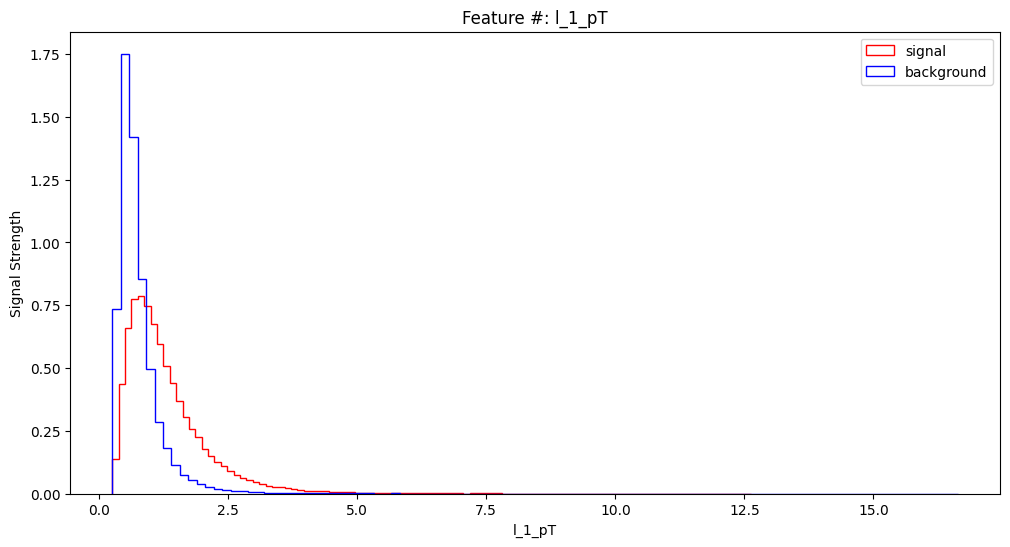

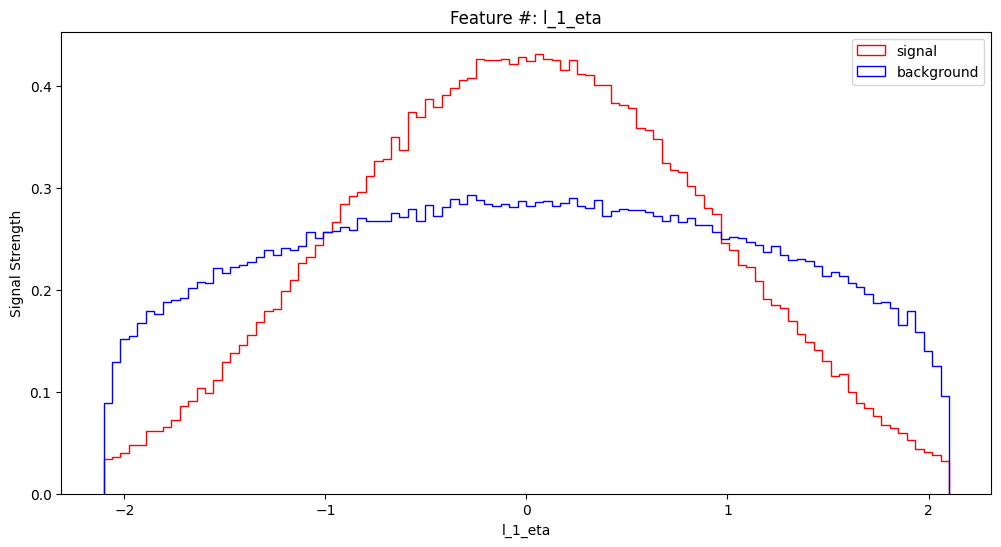

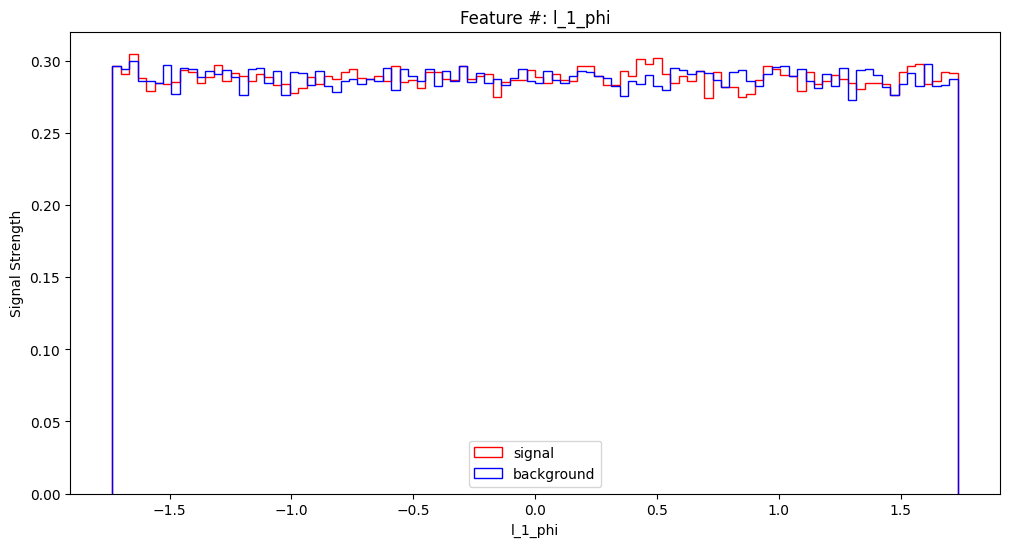

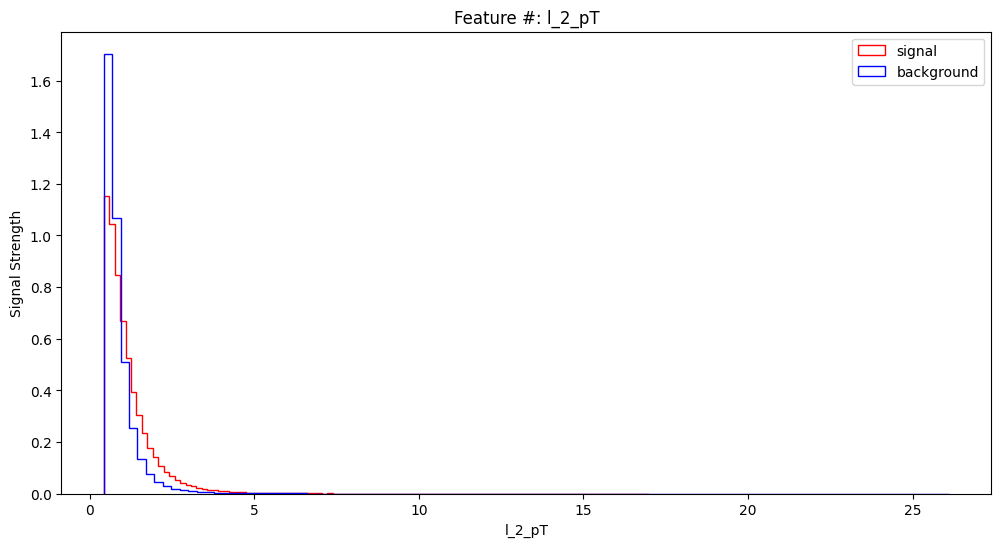

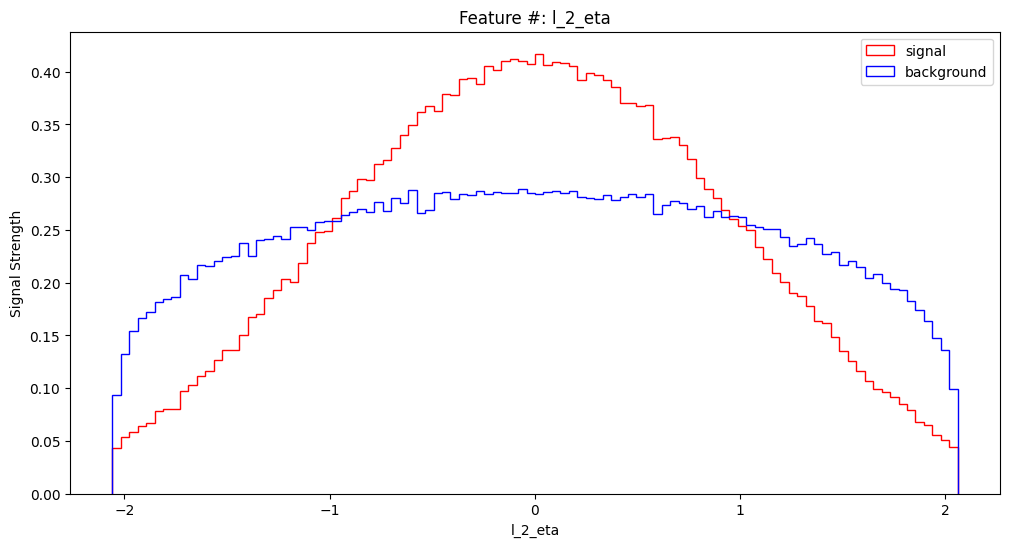

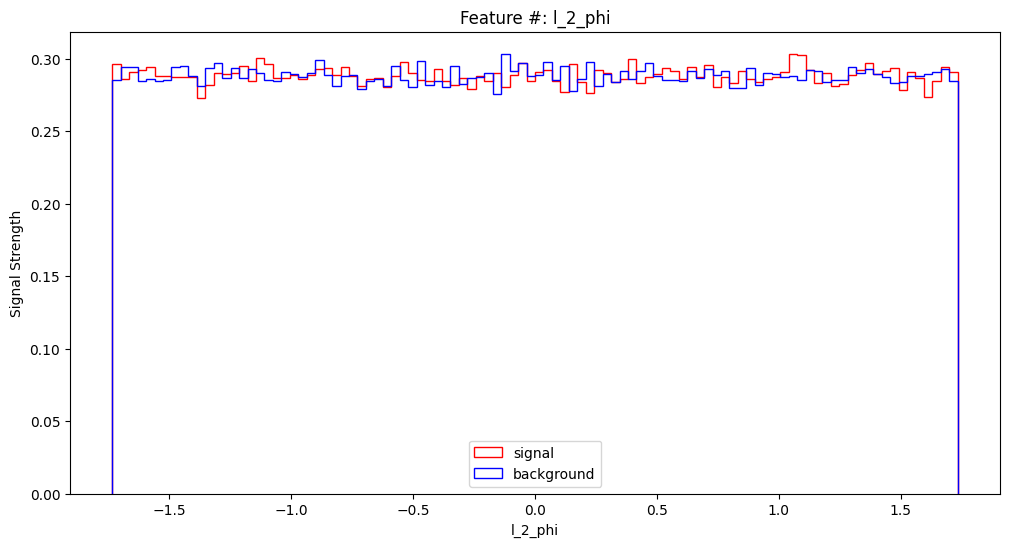

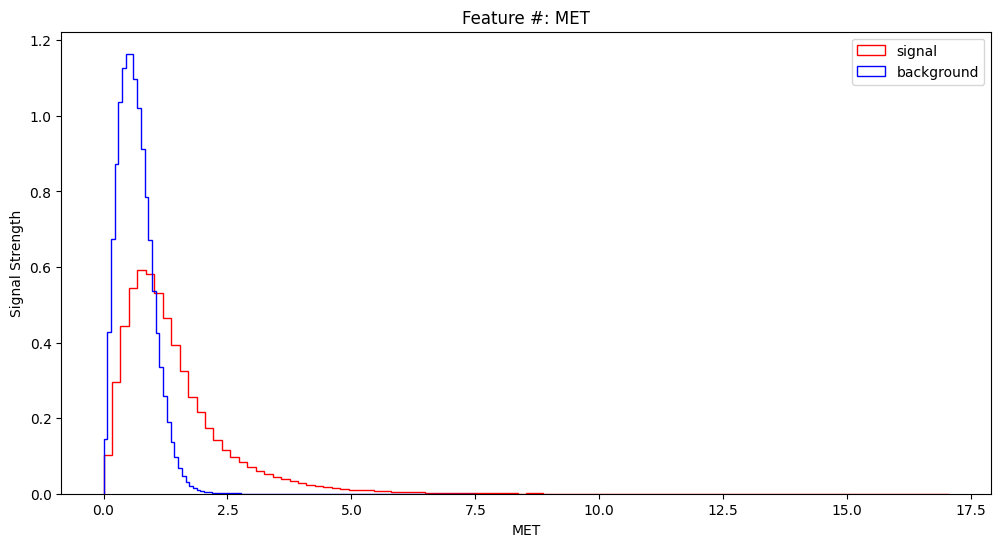

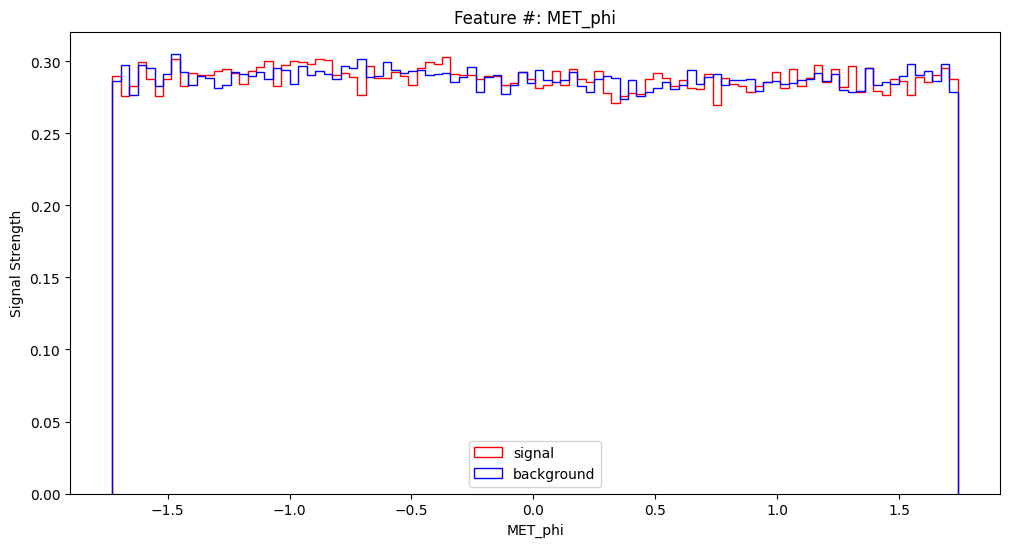

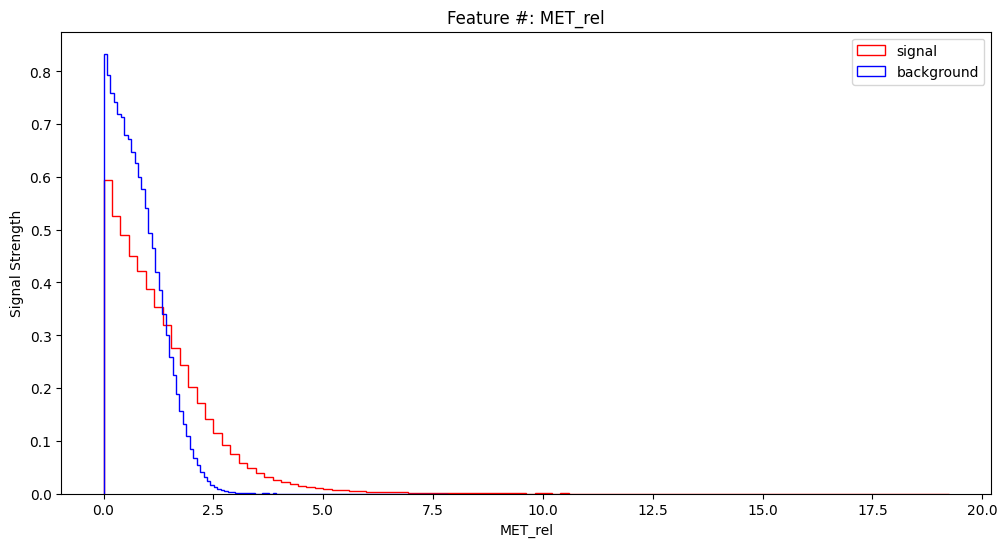

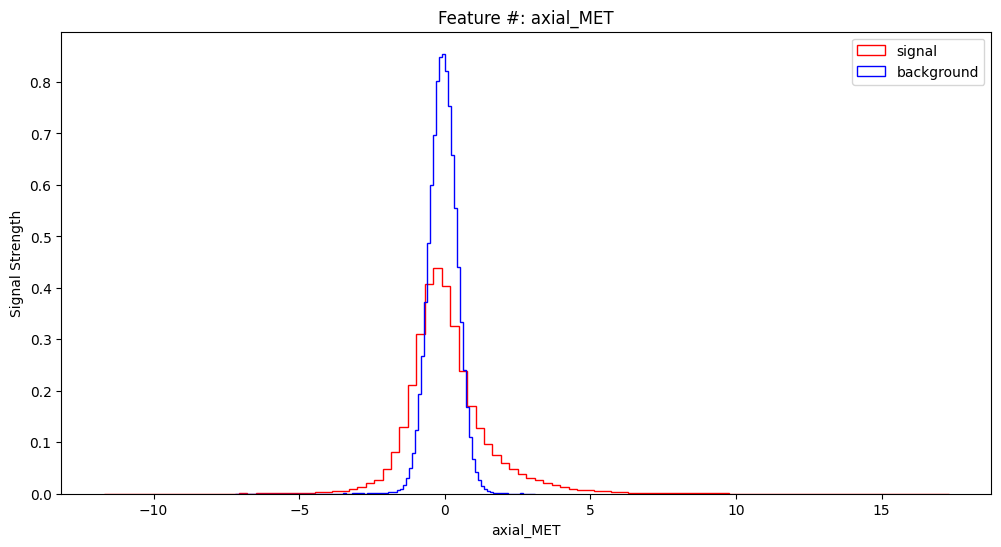

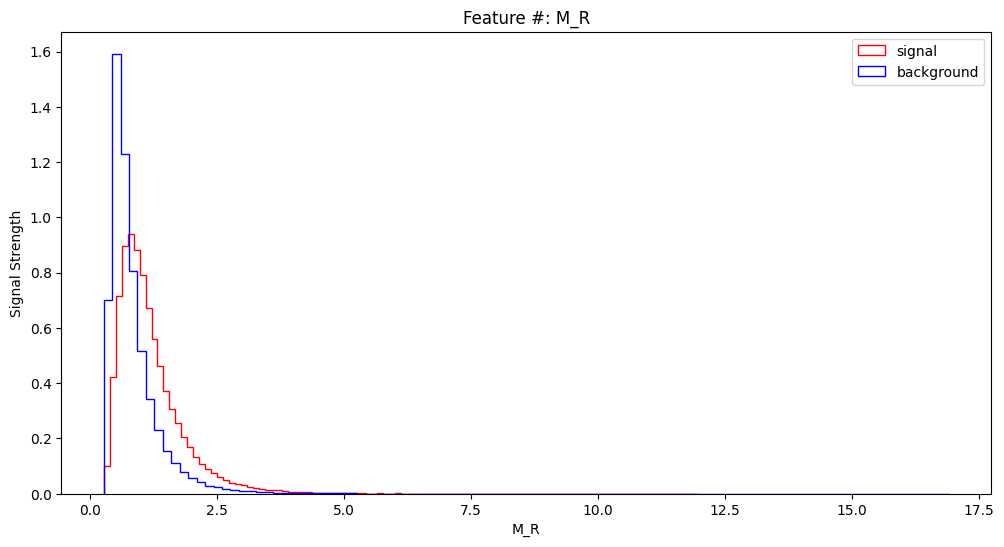

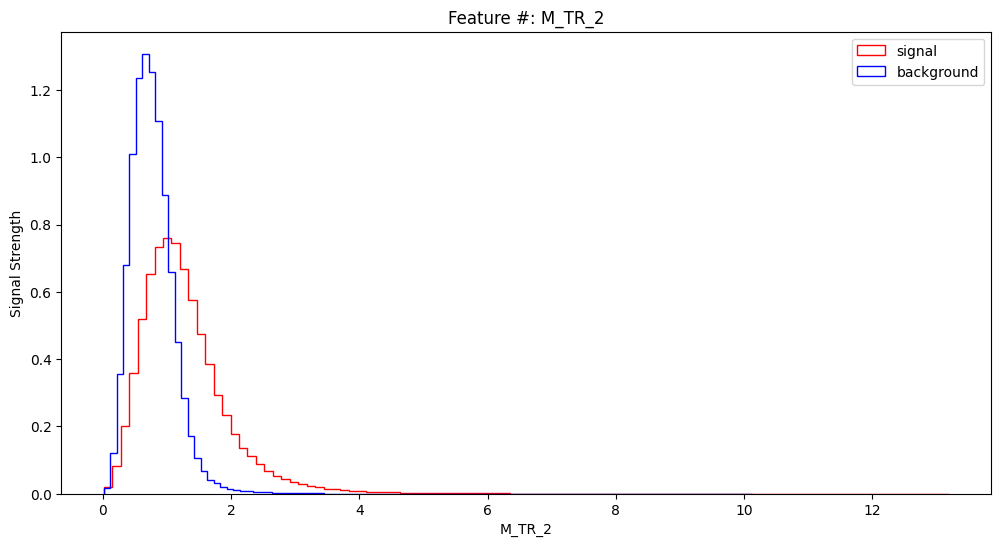

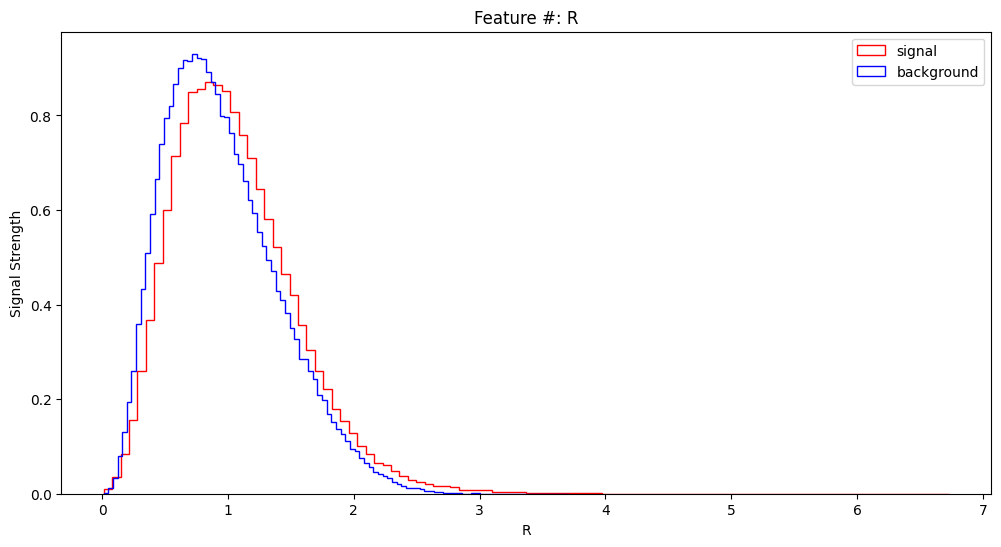

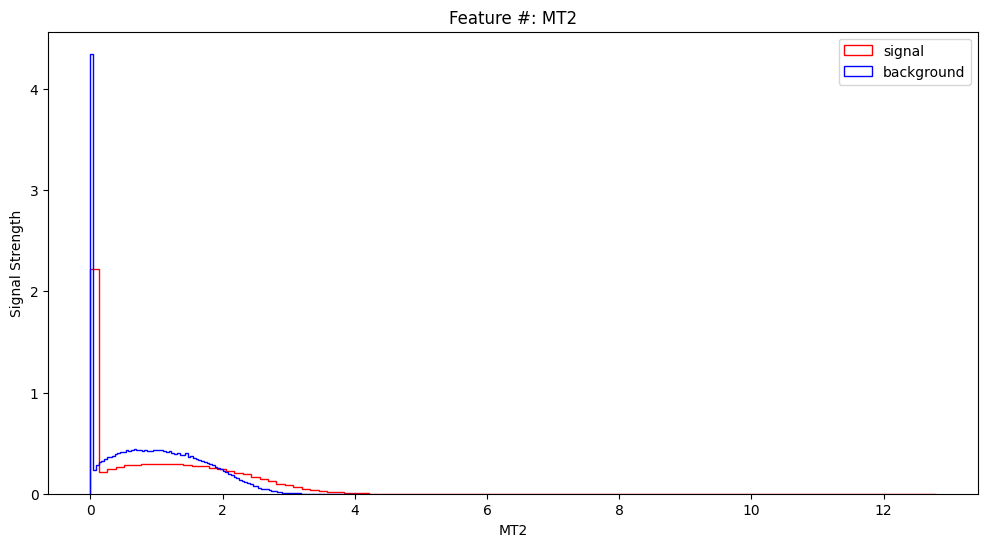

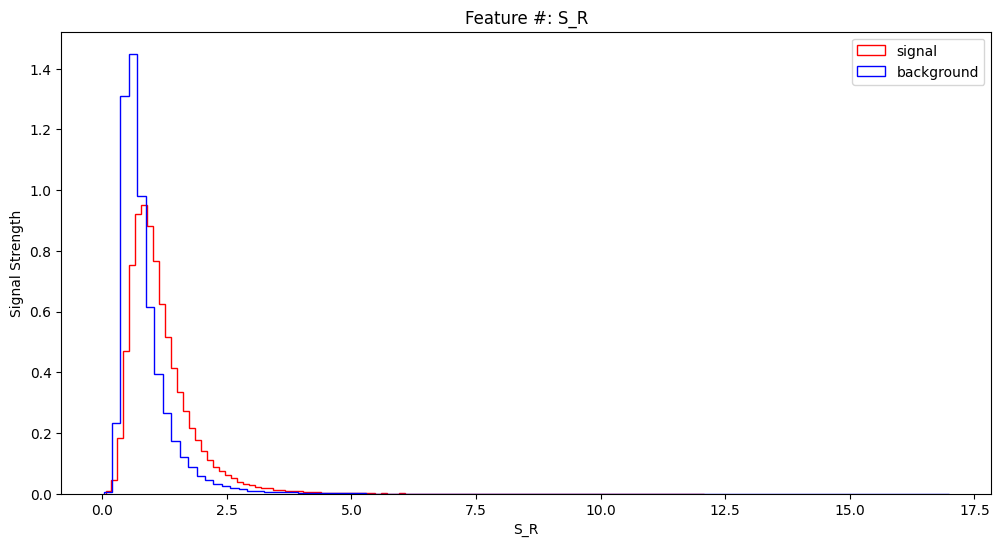

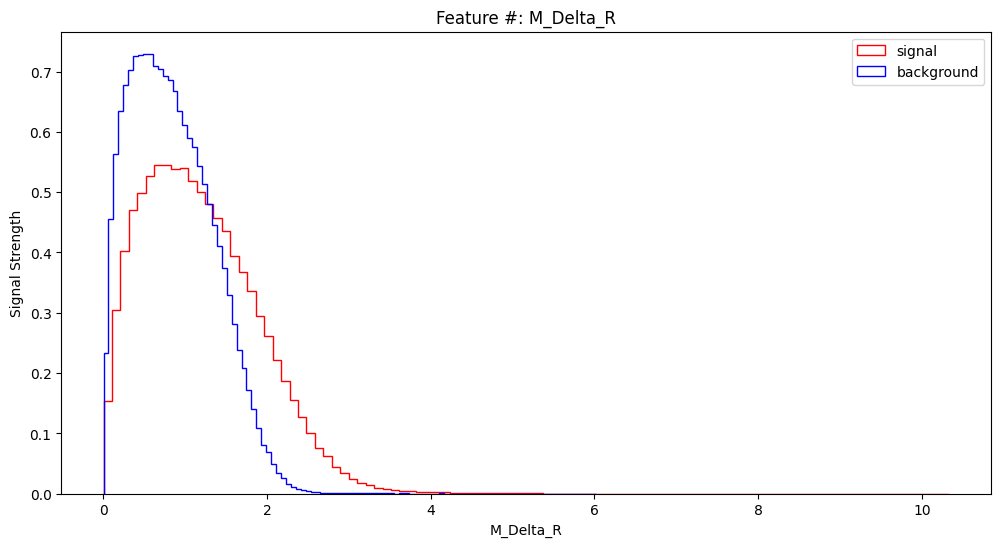

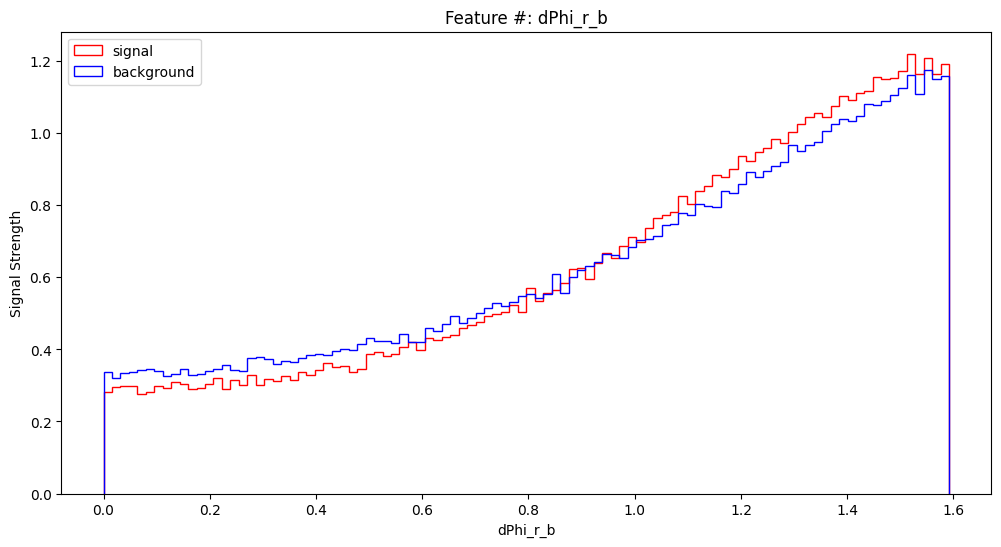

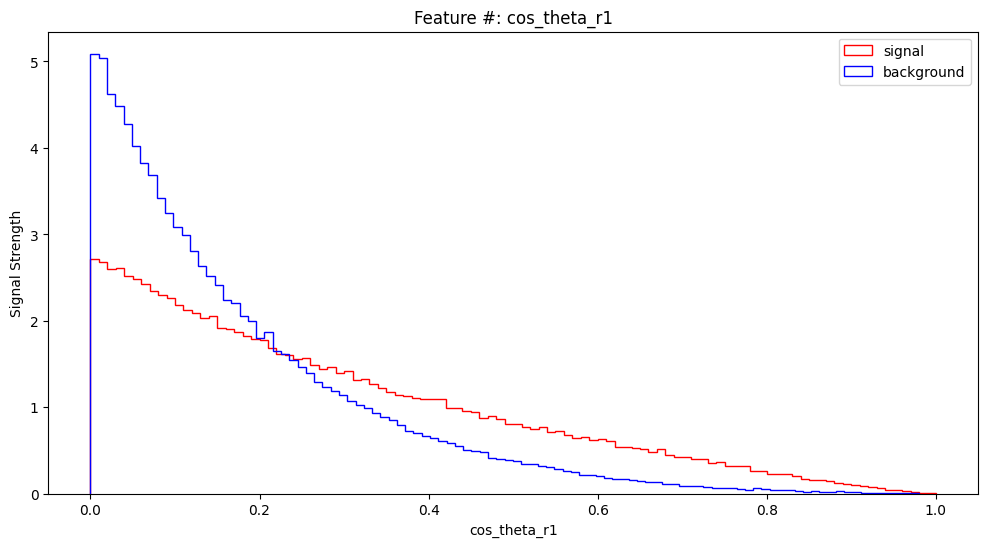

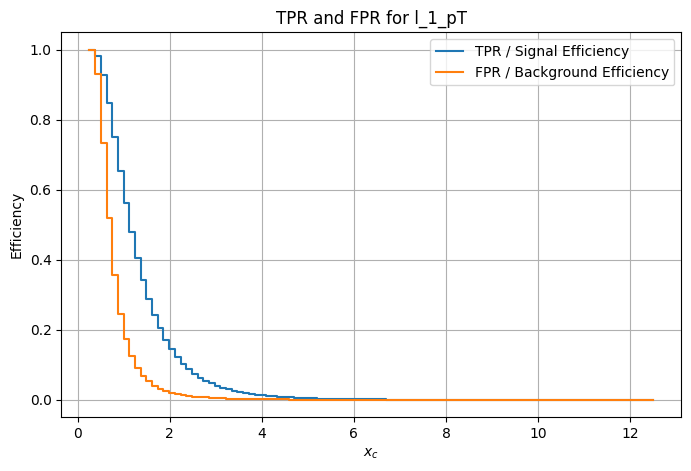

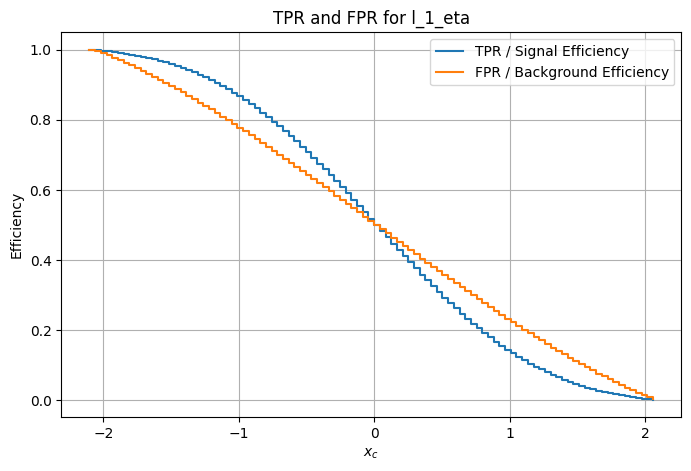

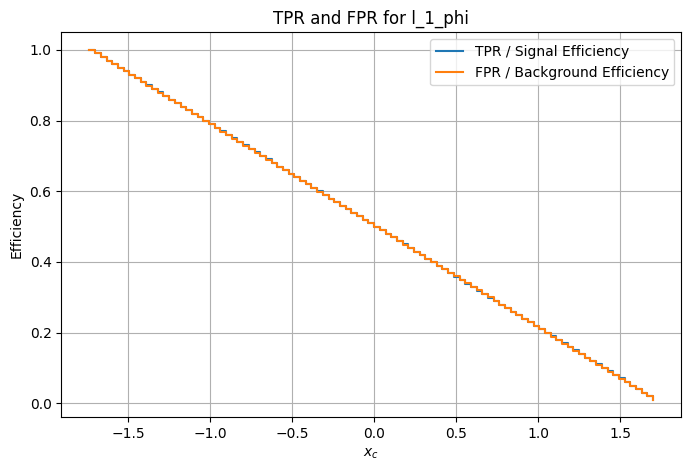

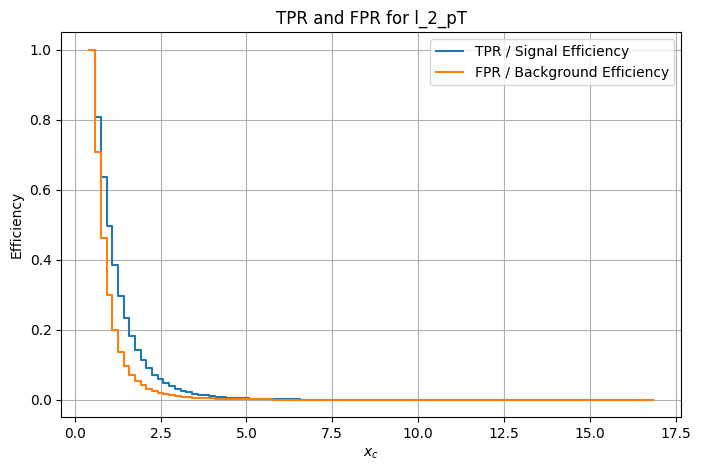

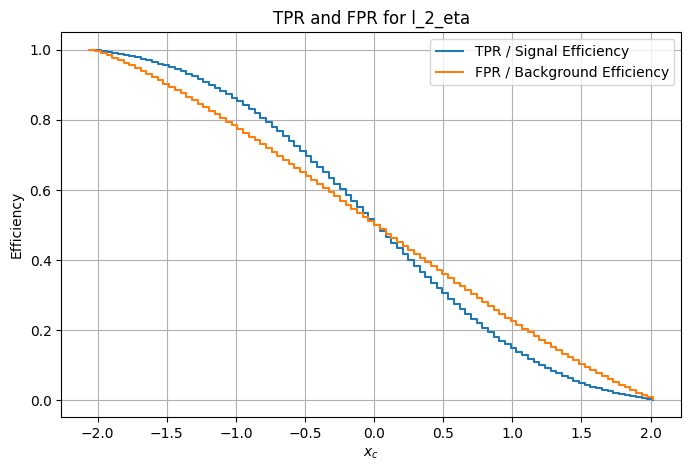

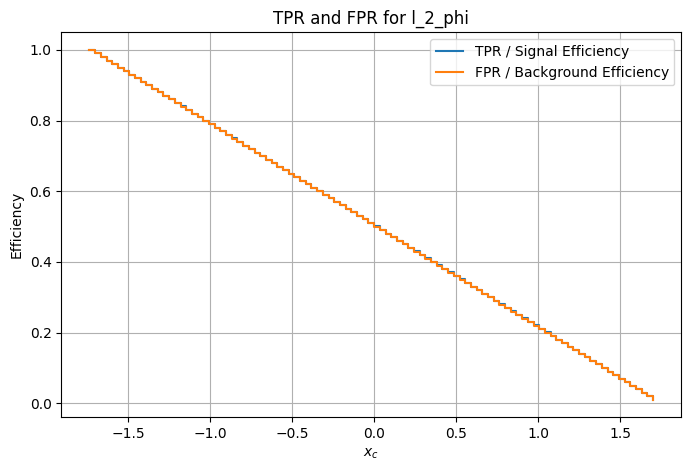

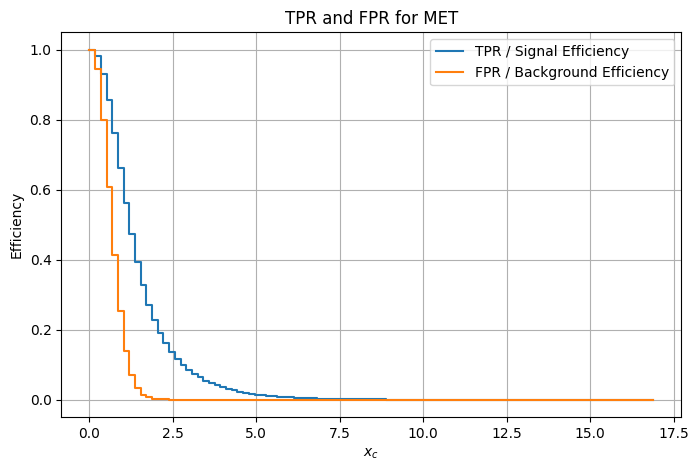

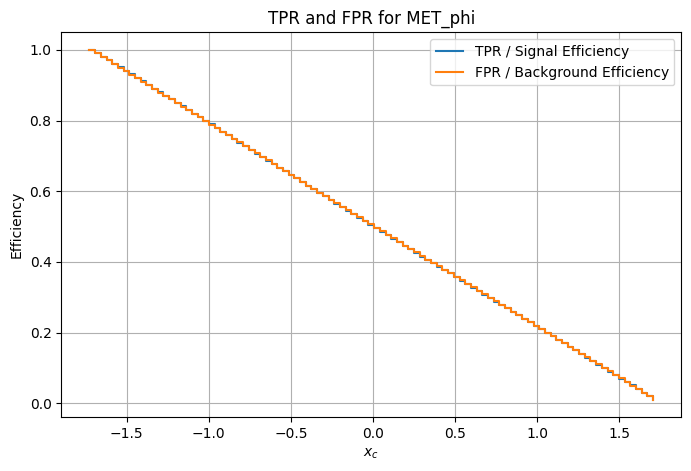

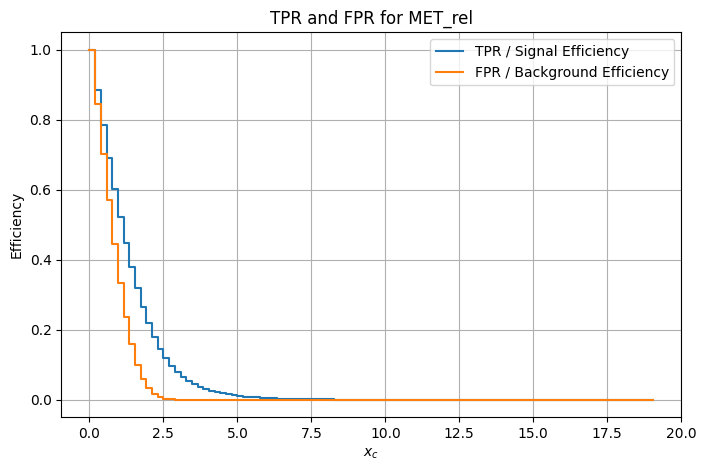

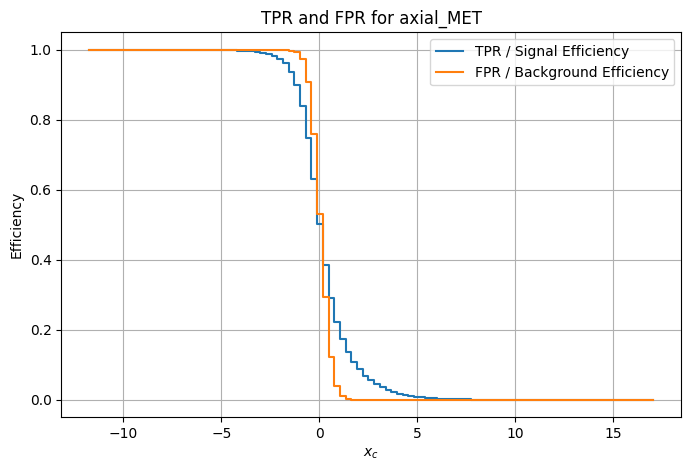

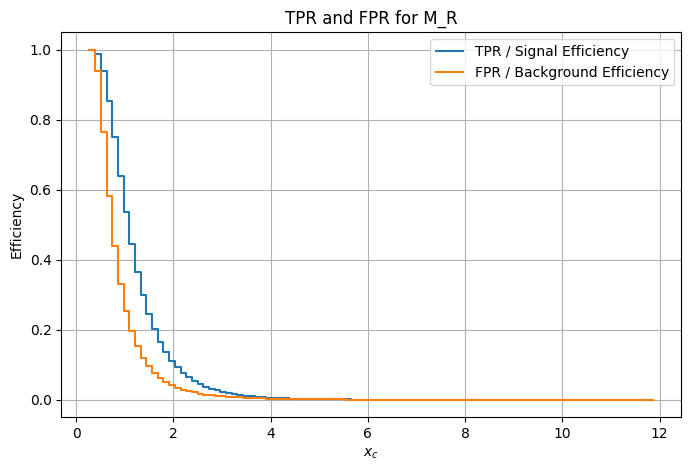

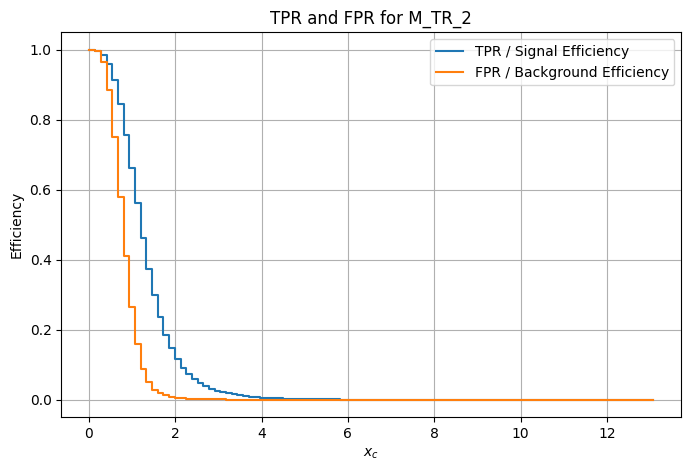

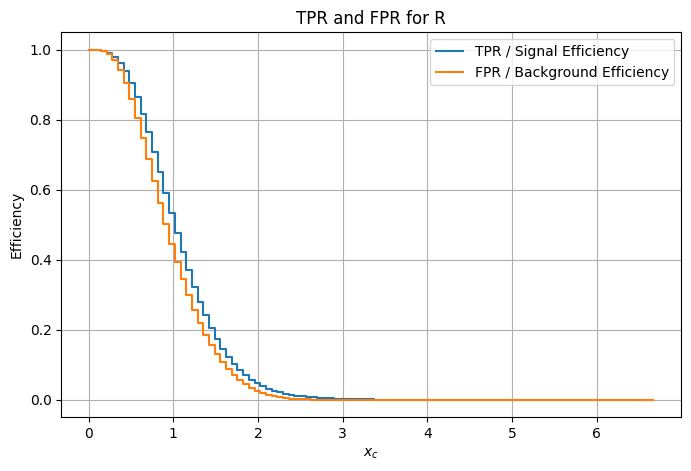

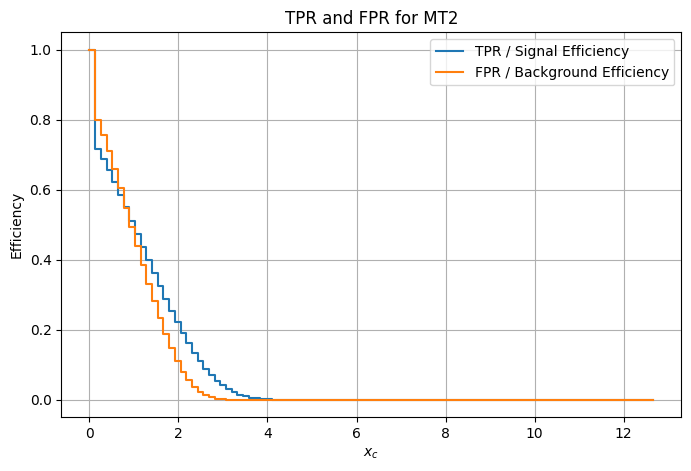

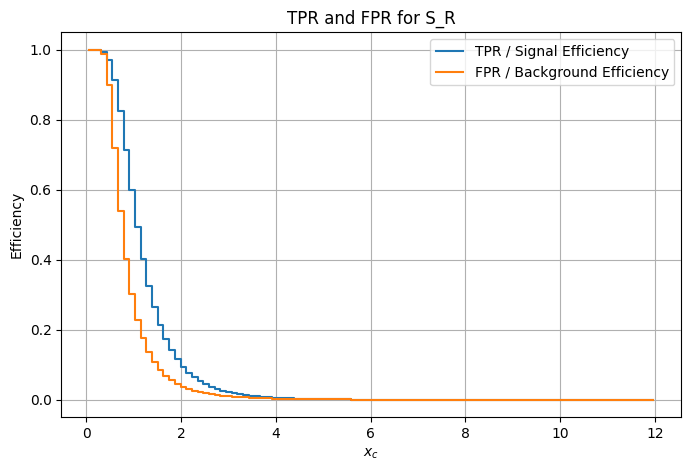

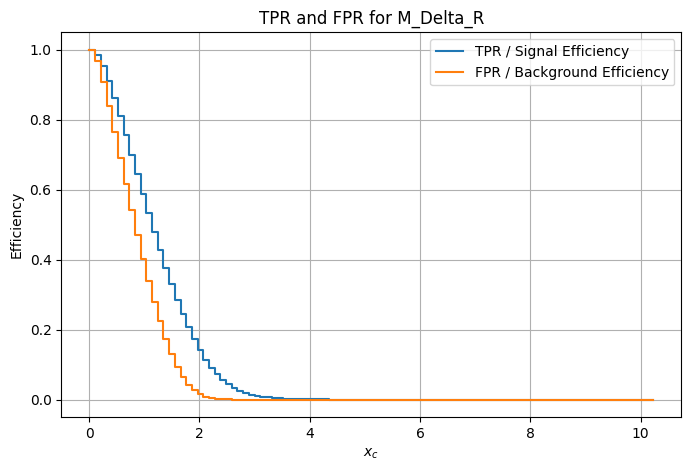

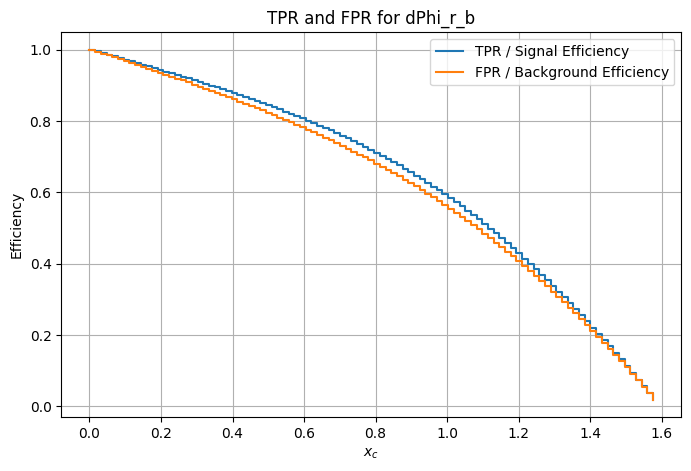

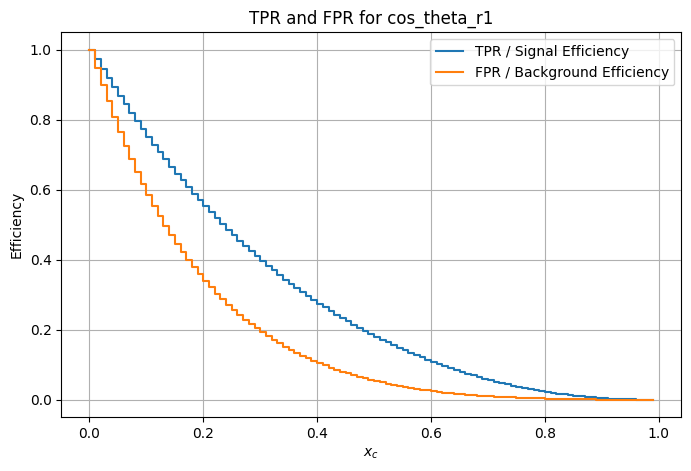

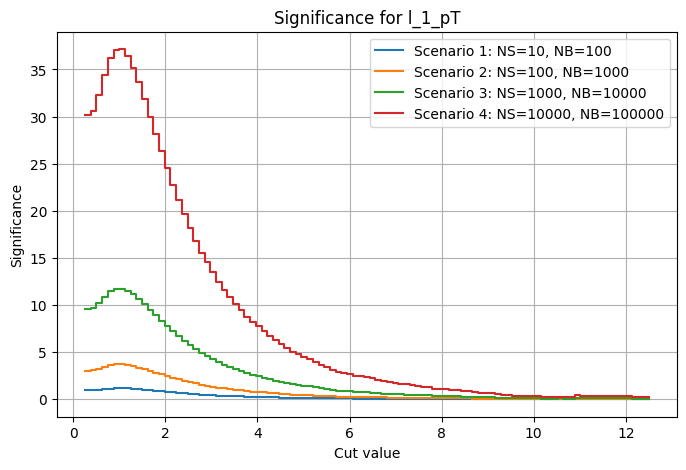

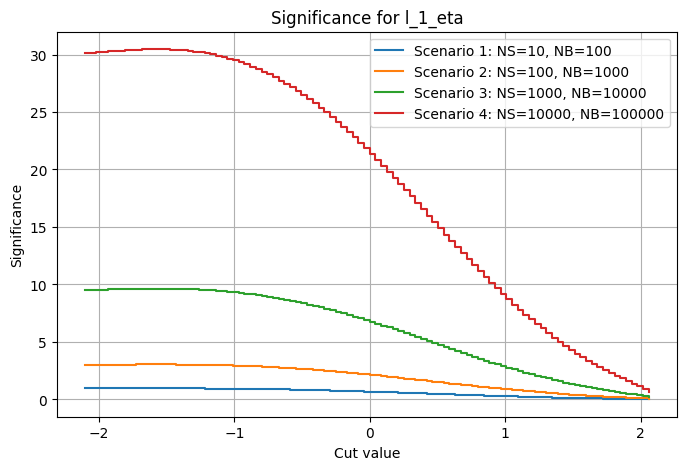

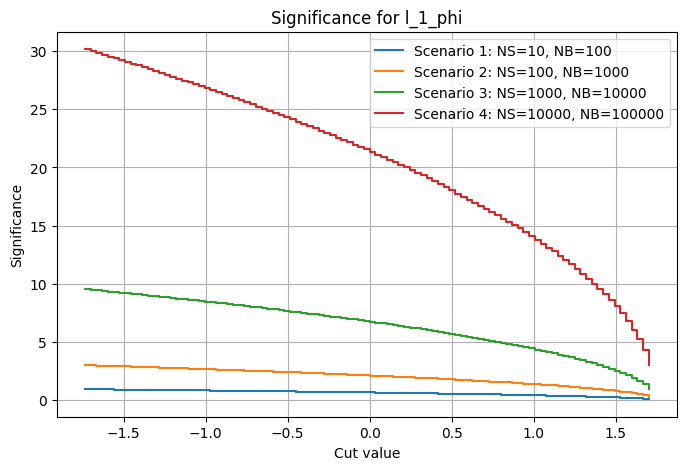

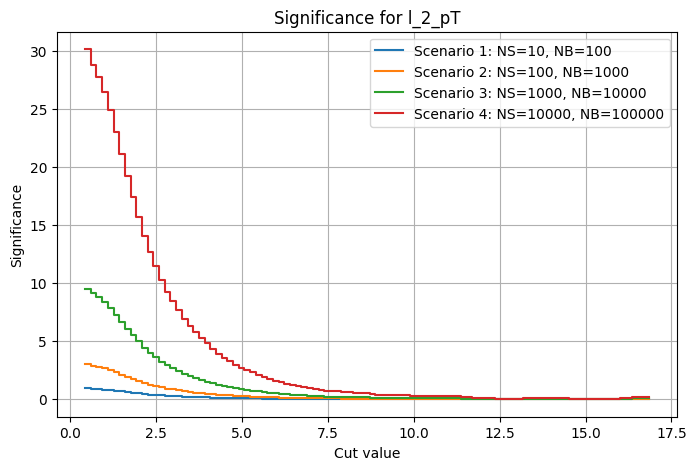

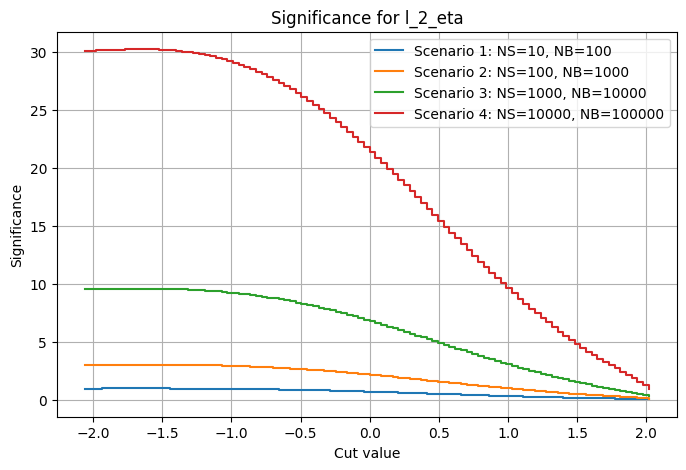

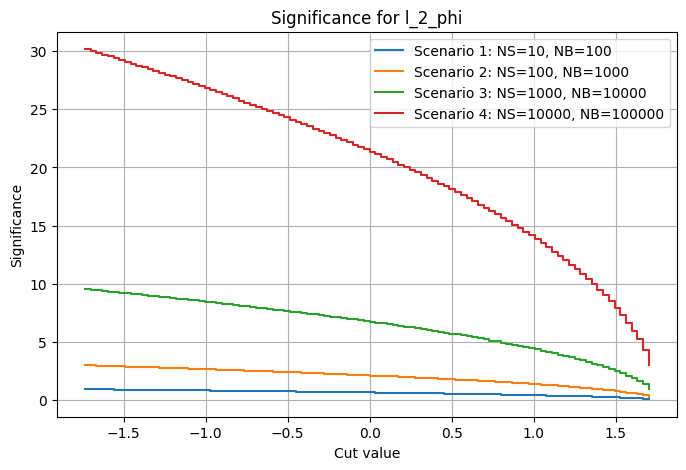

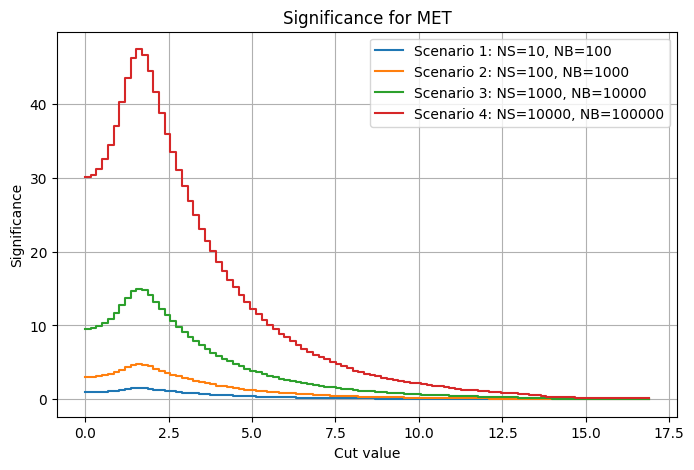

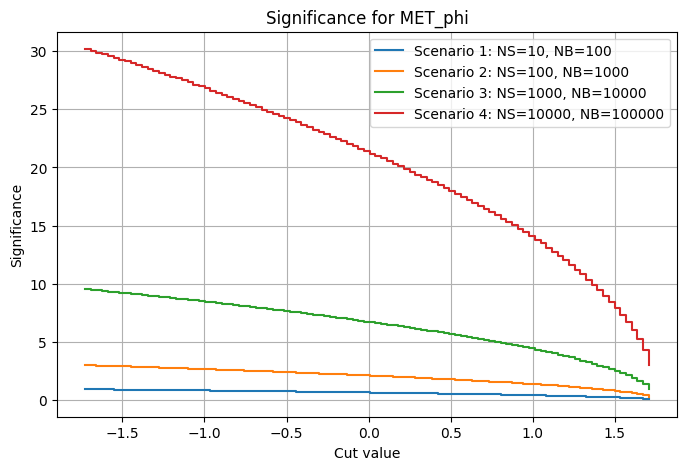

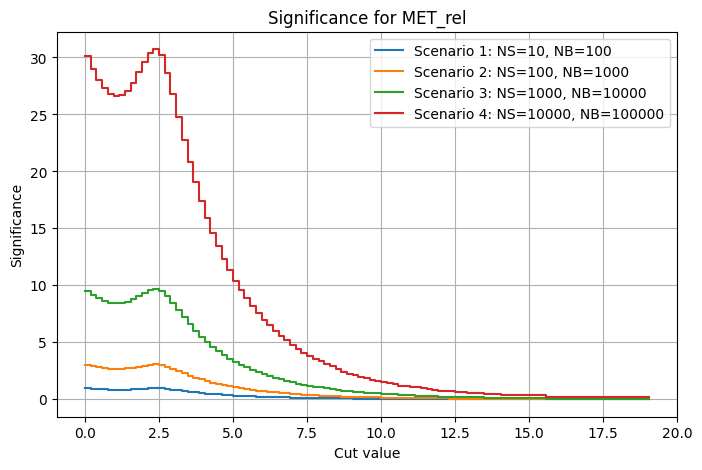

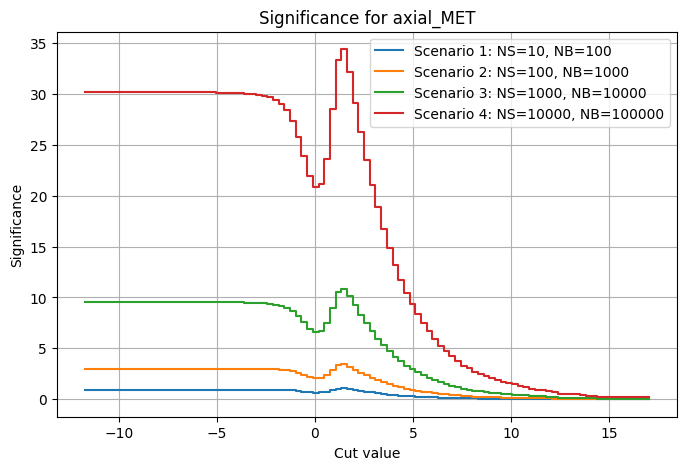

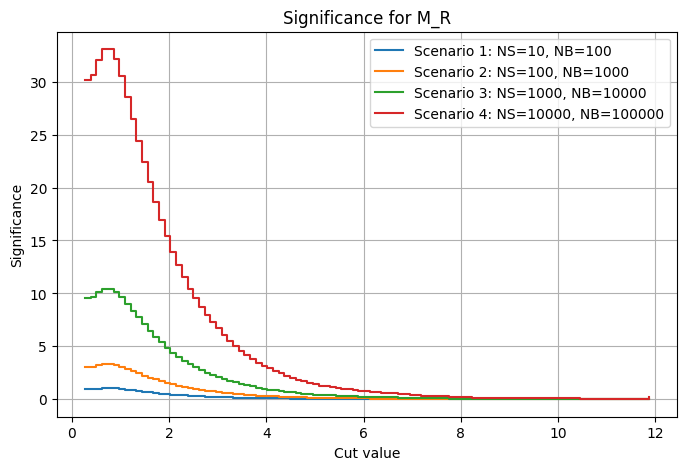

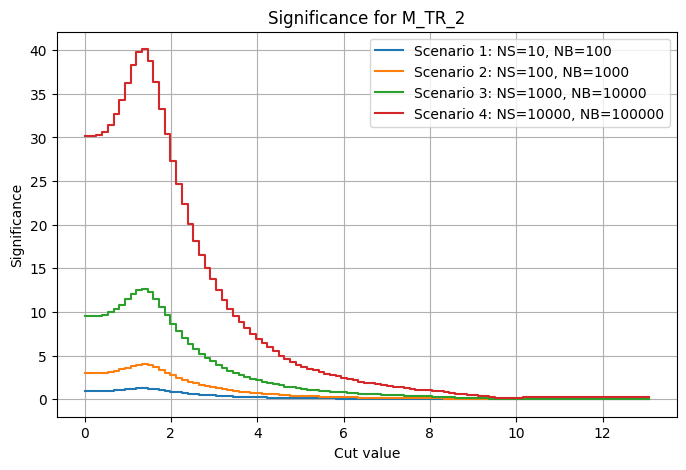

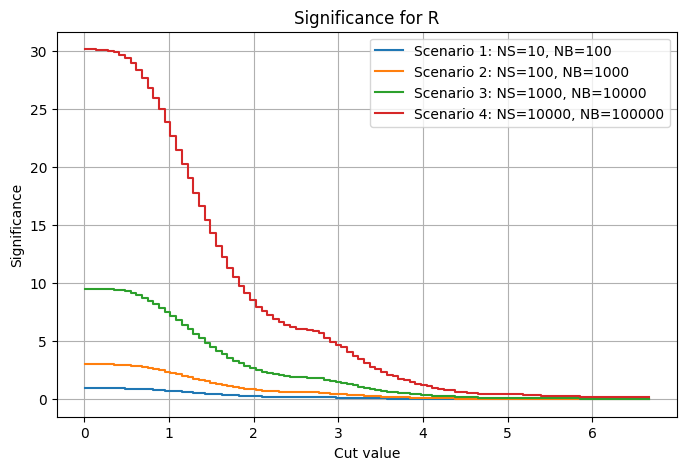

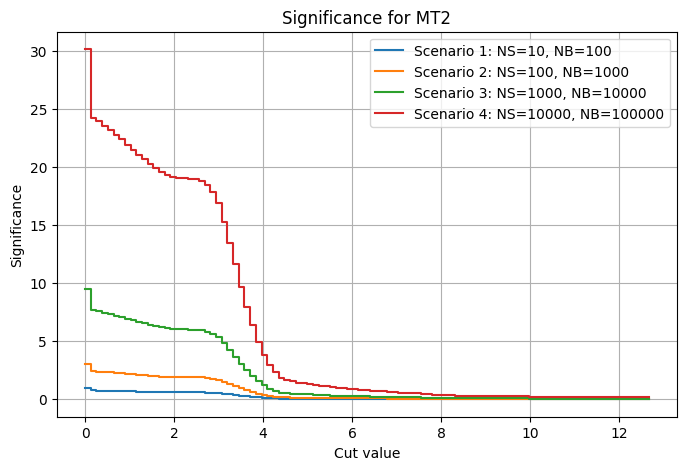

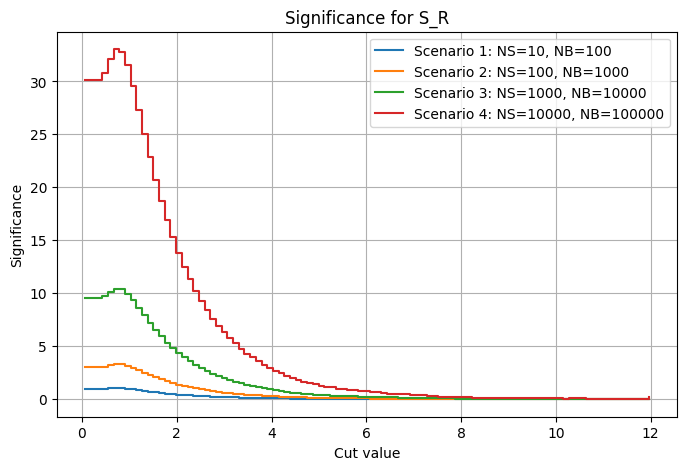

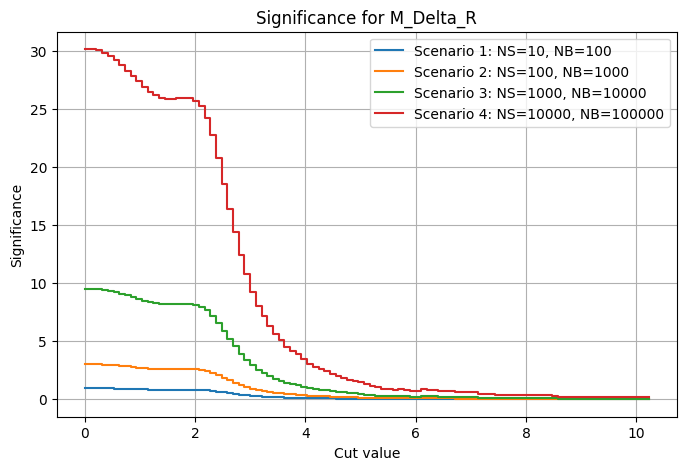

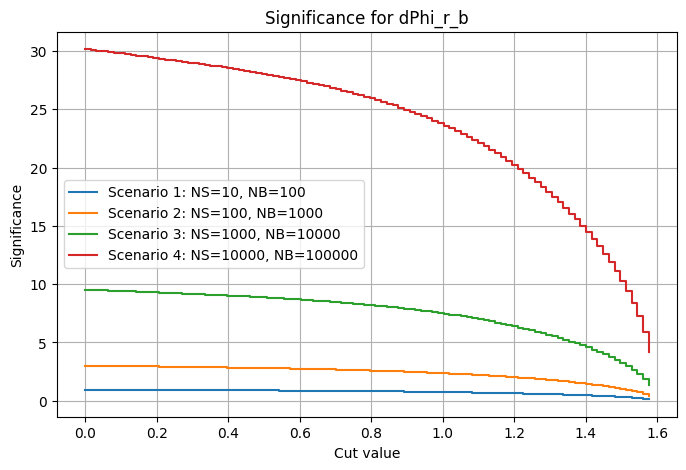

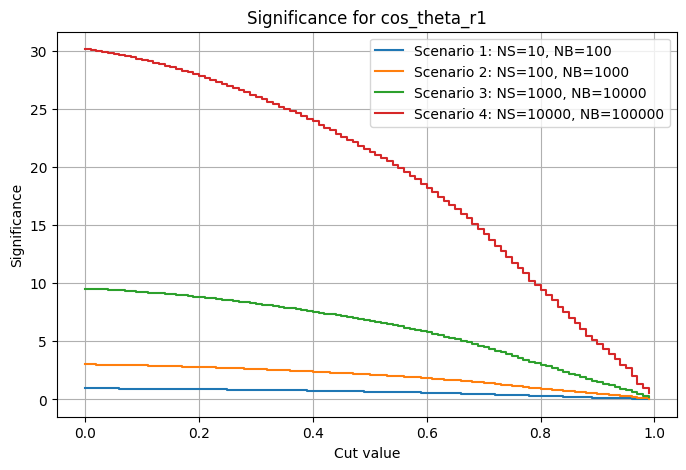

In [134]:
# 5.1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype="float64", names=VarNames)

observables = VarNames[1:]

selection_dict = {"signal": df["signal"] == 1, "background": df["signal"] == 0} # Store the dictionary to filter the signal / background

def selection_efficiency(df, var, selection, selection_type, xc, mu): #Grab the value for signal or background rows
    values = df[selection][var]

    if selection_type == "x > xc": # Apply it to check if applies to a selection rule
        passed = values > xc
    elif selection_type == "x < xc":
        passed = values < xc
    elif selection_type == "|x - mu| > xc":
        passed = np.abs(values - mu) > xc
    elif selection_type == "|x - mu| < xc":
        passed = np.abs(values - mu) < xc

    return np.mean(passed) # Return which event passed here.

def find_top_selection(df, var, nchecks=100):
    values = df[var].to_numpy() # Pull one observable
    
    mu = np.mean(values) # Compute the mean for x - mu

    x_checks = np.linspace(values.min(), values.max(), nchecks) # Try xc values across var range

    abs_values = np.abs(values - mu) #Try xc values on distance from mu
    abs_checks = np.linspace(0, abs_values.max(), nchecks)

    local_signal = df["signal"] == 1 # Creates a signal filter for the dataframe
    local_background = df["signal"] == 0 # Creates a background filter for the dataframe
    
    results = [] # Store the results

    for selection_type in ["x > xc", "x < xc"]: # Test the other selections (x > xc and x < xc)
        for xc in x_checks:
            signal_efficiency = selection_efficiency(df, var, local_signal, selection_type, xc, mu) # Signal fraction

            background_efficiency = selection_efficiency(df, var, local_background, selection_type, xc, mu) # Background fraction

            score = signal_efficiency - background_efficiency # Larger score = better signal

            results.append([var, selection_type, xc, mu, signal_efficiency, background_efficiency, score]) # Saves the result

    for selection_type in ["|x - mu| > xc", "|x - mu| < xc"]: # Tests x - mu > xc and x - mu < xc
        for xc in abs_checks:
            signal_efficiency = selection_efficiency(df, var, local_signal, selection_type, xc, mu) # Signal fraction

            background_efficiency = selection_efficiency(df, var, local_background, selection_type, xc, mu)# Background fraction

            score = signal_efficiency - background_efficiency # Larger score = better signal

            results.append([var, selection_type, xc, mu, signal_efficiency, background_efficiency, score]) # Saves the result

    results_df = pd.DataFrame(results, columns=["variable", "selection_type", "xc", "mu", "signal_efficiency", "background_efficiency", "score"]) # Converts everything back to a dataframe

    top_row = results_df.loc[results_df["score"].idxmax()] # Picks the selection w/ the highest score

    return top_row

top_selection = [] # List to store the top selection for each observable

for var in VarNames[1:]:
    print("Finding...", var)
    top_selection.append(find_top_selection(df, var))

top_selection = pd.DataFrame(top_selection) # Final observables go into a dataframe
top_selection = top_selection.sort_values("score", ascending=False) # Sorts the selections before doing so

display(top_selection)

df_sig = df[df.signal == 1]
df_bkg = df[df.signal == 0]

def compute_rate(d, bins=100): # Computes x > xc cuts
    hist, bins_ = np.histogram(d, bins = bins, density = True) # Makes the hist
    R = np.cumsum(hist[::-1])[::-1] * (bins_[1] - bins_[0]) # Adds the count from right to left.
    return R, bins_ # Returns the efficiency and bins

for var in VarNames[1:]: # Makes a histogram for each observable and skips the signal label
    plt.figure(figsize=(12, 6)) # Creates the figure
    
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step",color="red",label="signal",density=True,stacked=True)
    
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step",color="blue",label="background",density=True,stacked=True)
    
    plt.xlabel(var)
    plt.ylabel("Signal Strength")
    plt.title(f"Feature #: {var}")
    plt.legend()
    plt.show()

def plot_tpr_and_fpr(var, bins=100):
    TPR, bins_signal = compute_rate(df_signal[var], bins = bins) # Signal efficiency curve

    FPR, bins_signal = compute_rate(df_background[var], bins = bins_signal) # Background efficiency curve using same bins

    plt.figure(figsize = (8, 5)) # Creates the figure

    plt.step(bins_signal[:-1], TPR, where = "post", label = "TPR / Signal Efficiency") # Plot signal efficiency
    plt.step(bins_signal[:-1], FPR, where = "post", label = "FPR / Background Efficiency") # Plot background efficiency

    plt.xlabel(r"$x_c$")
    plt.ylabel("Efficiency")
    plt.title(f"TPR and FPR for {var}")
    plt.legend()
    plt.grid(True)
    plt.show()

for var in VarNames[1:]: # Make TPR and FPR plot for each observable
    plot_tpr_and_fpr(var)

scenarios = {
    "Scenario 1": (10, 100),
    "Scenario 2": (100, 1000),
    "Scenario 3": (1000, 10000),
    "Scenario 4": (10000, 100000)
}

def plot_significance(var, bins = 100): # Plots the significance for each scenario
    TPR, bins_signal = compute_rate(df_signal[var], bins = bins) # Shows the efficiency curve of the signal.
    FPR, bins_signal = compute_rate(df_background[var], bins = bins_signal) # Shows the background efficiency curve with bins

    plt.figure(figsize = (8, 5)) # Creates the figure

    for label, (N_S, N_B) in scenarios.items(): # Loop over the each scenarios
        N_S_prime = TPR * N_S # Signal events left after the cut
        N_B_prime = FPR * N_B # Background events left after the cut

        significance = N_S_prime / np.sqrt(N_S_prime + N_B_prime) # Compute the significance

        plt.step(bins_signal[:-1], significance, where = "post", label = f"{label}: NS={N_S}, NB={N_B}") # Plots the significance curve

    plt.xlabel("Cut value")
    plt.ylabel("Significance")
    plt.title(f"Significance for {var}")
    plt.legend()
    plt.grid(True)
    plt.show()

for var in VarNames[1:]: # Makes the significance plot for each observable
    plot_significance(var)

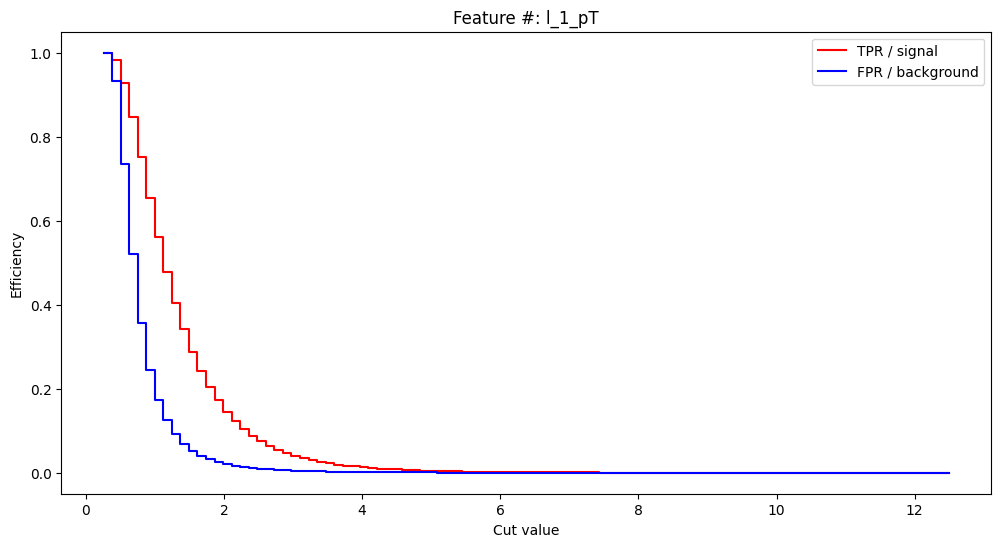

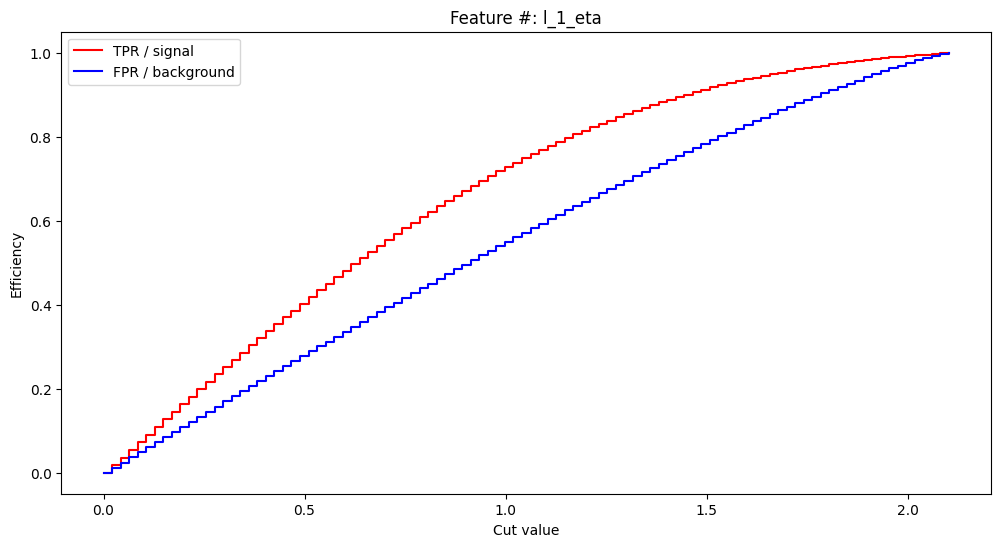

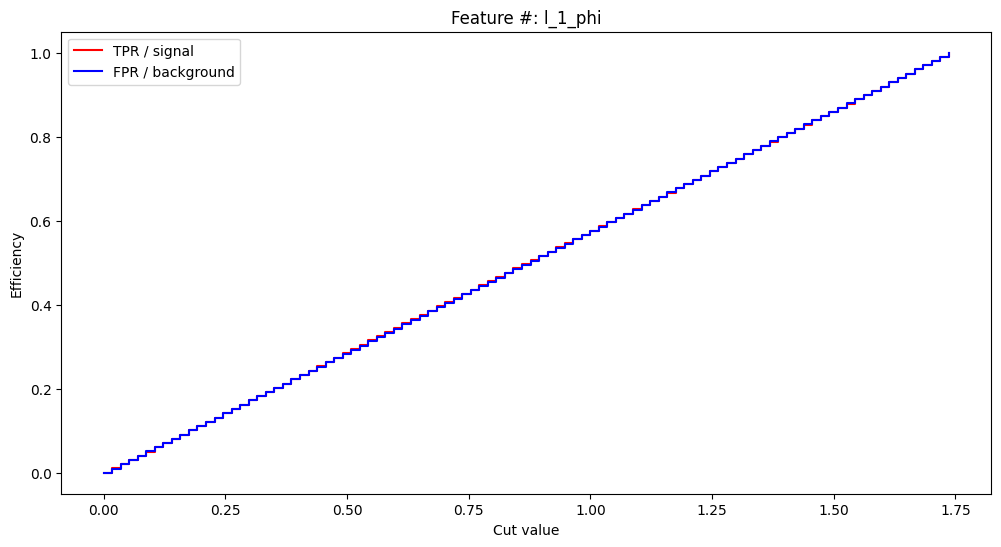

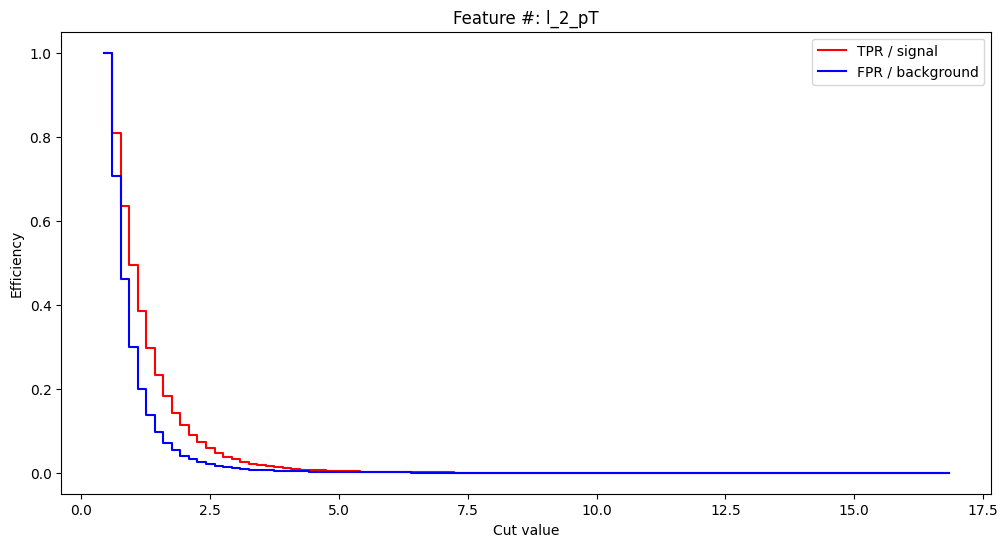

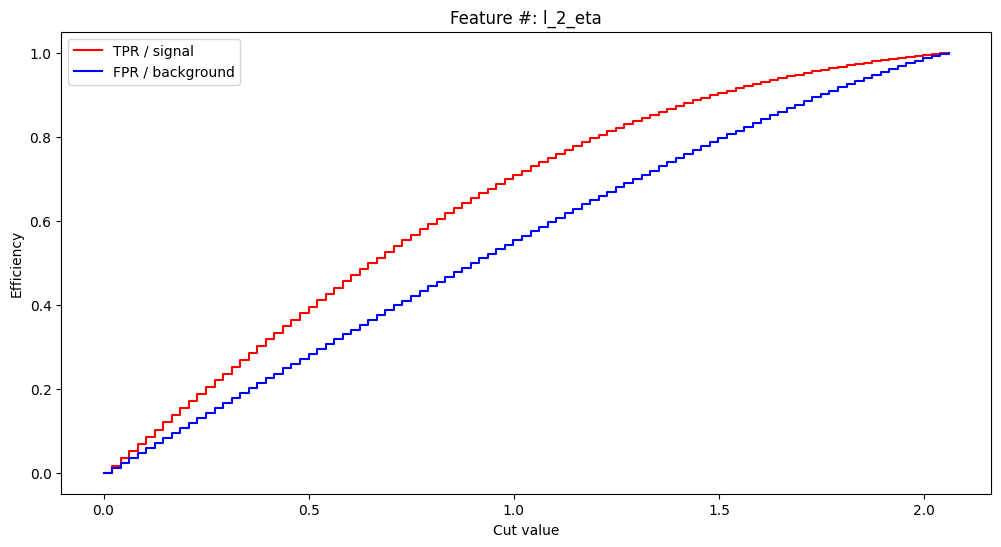

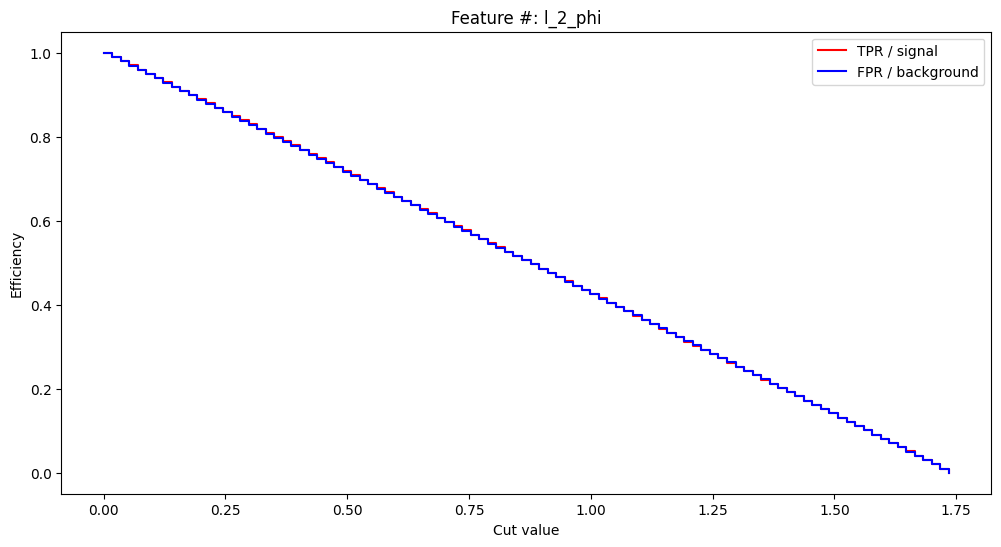

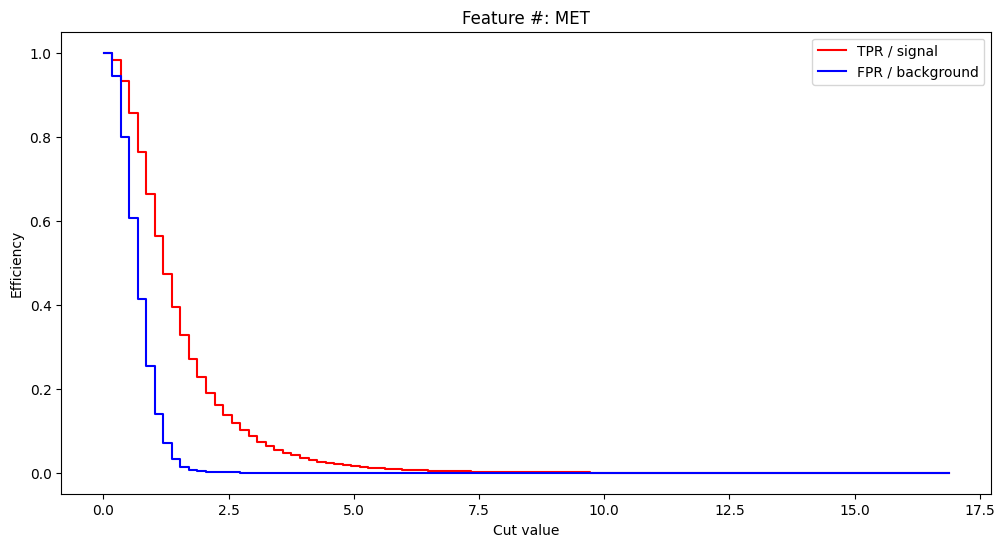

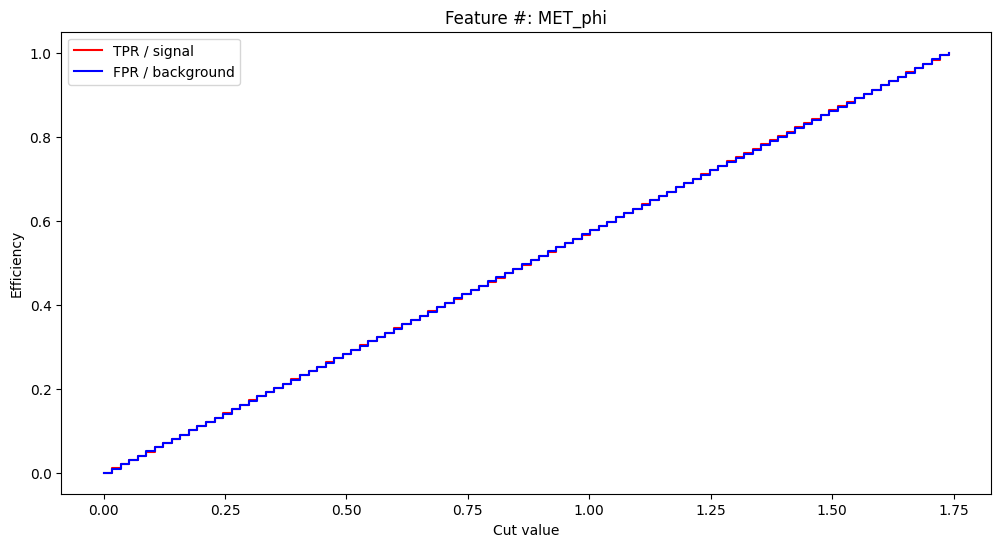

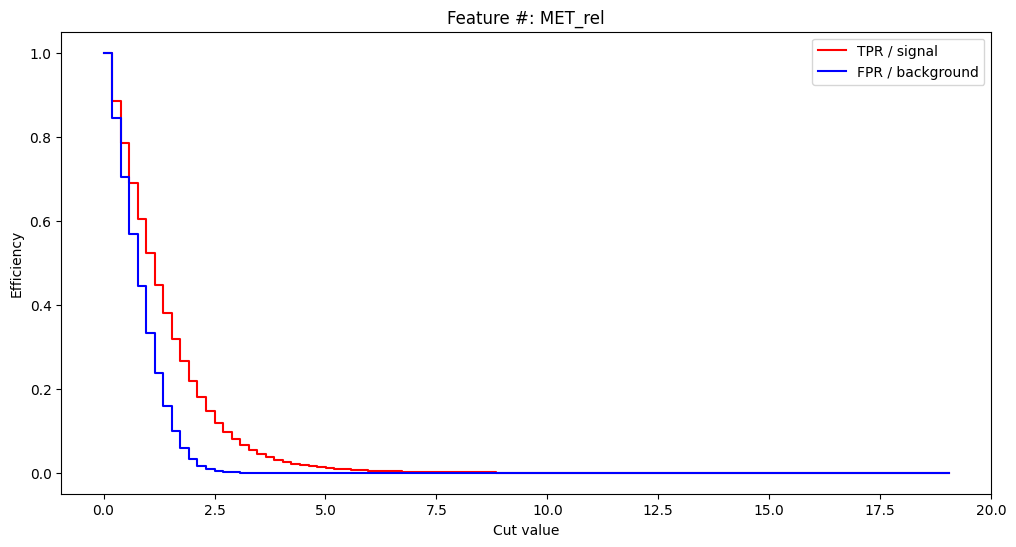

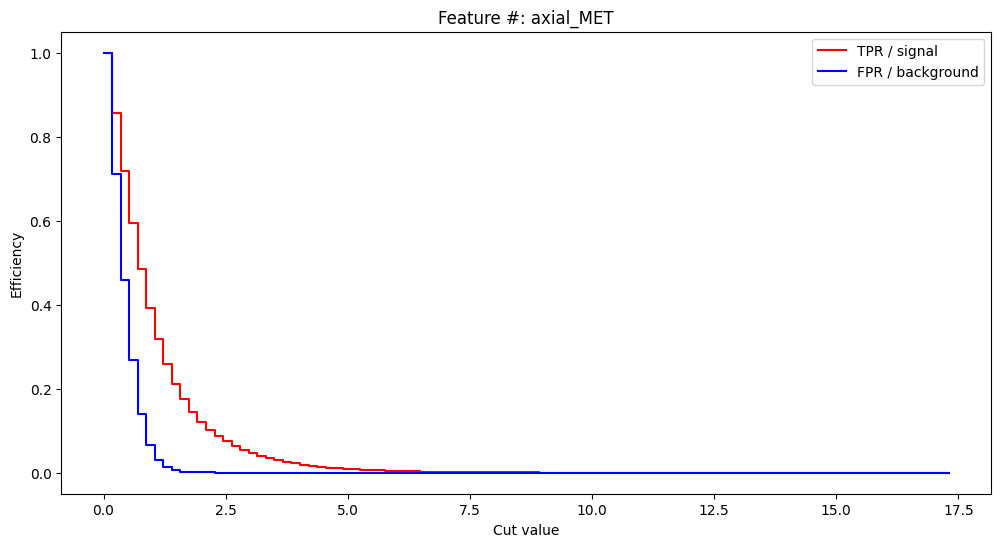

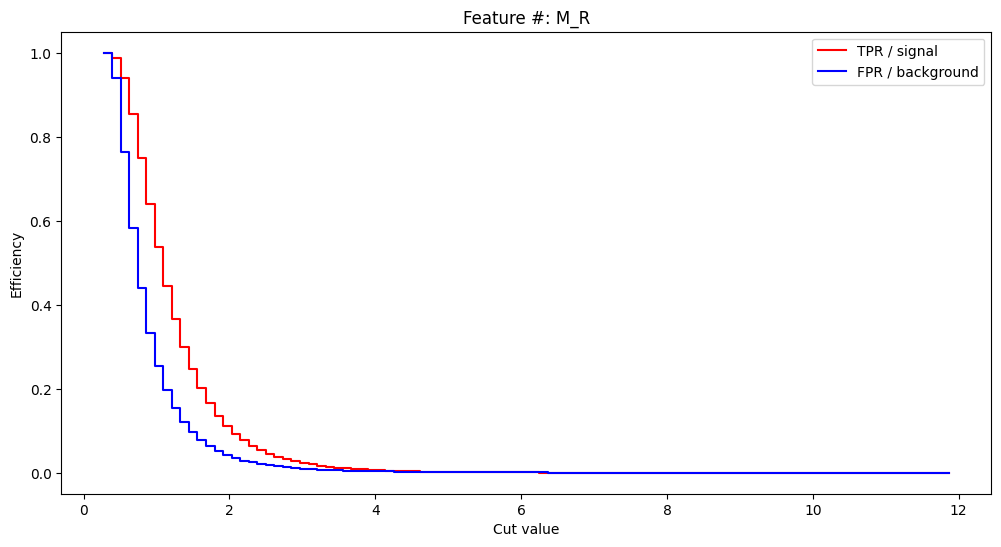

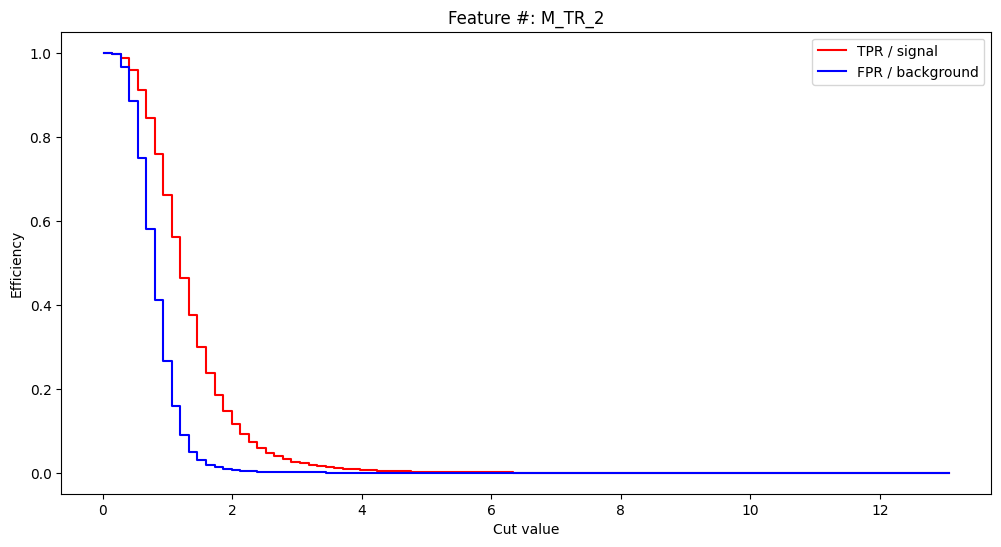

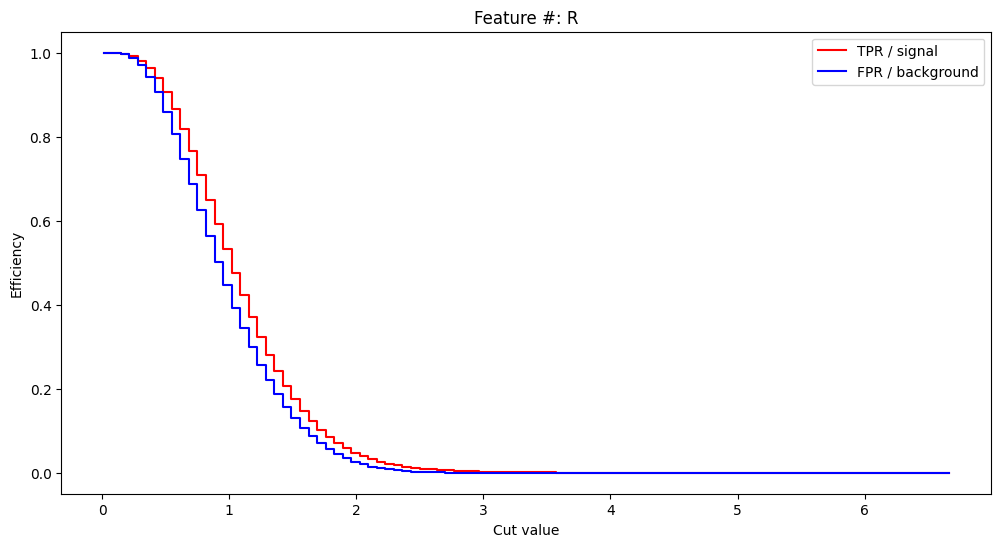

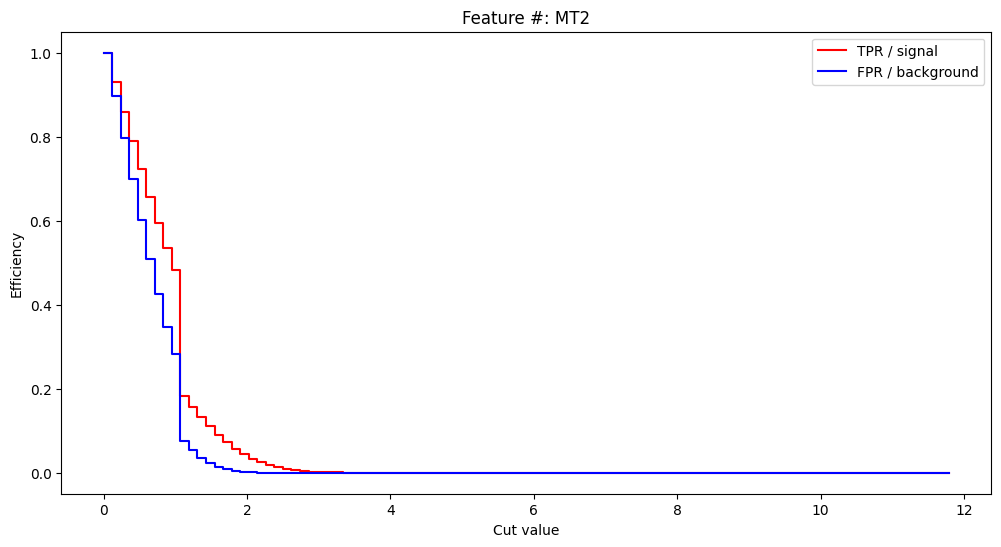

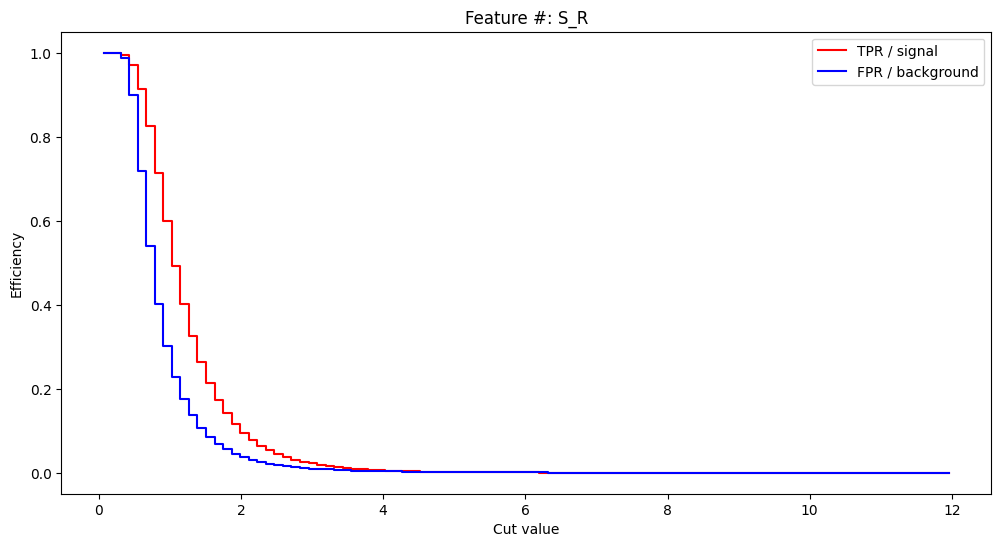

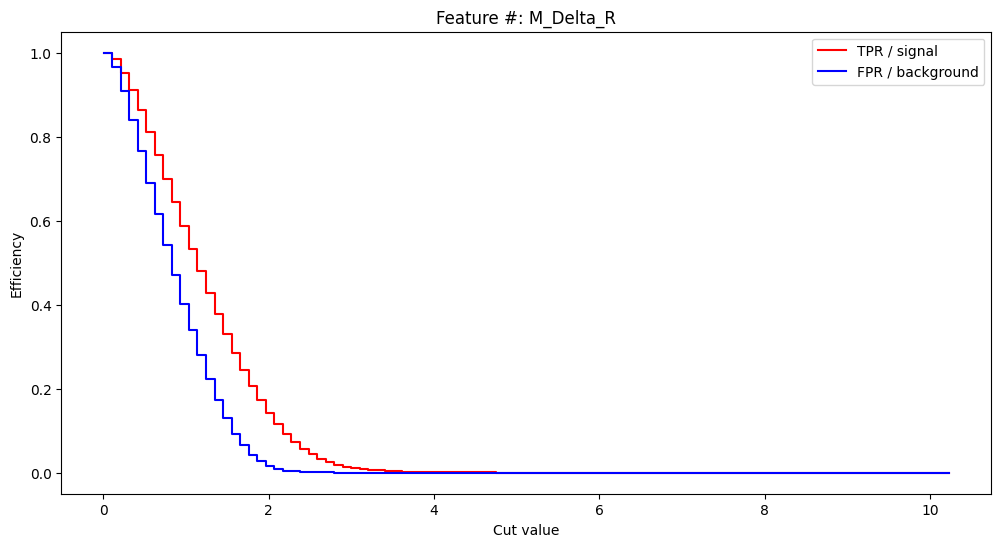

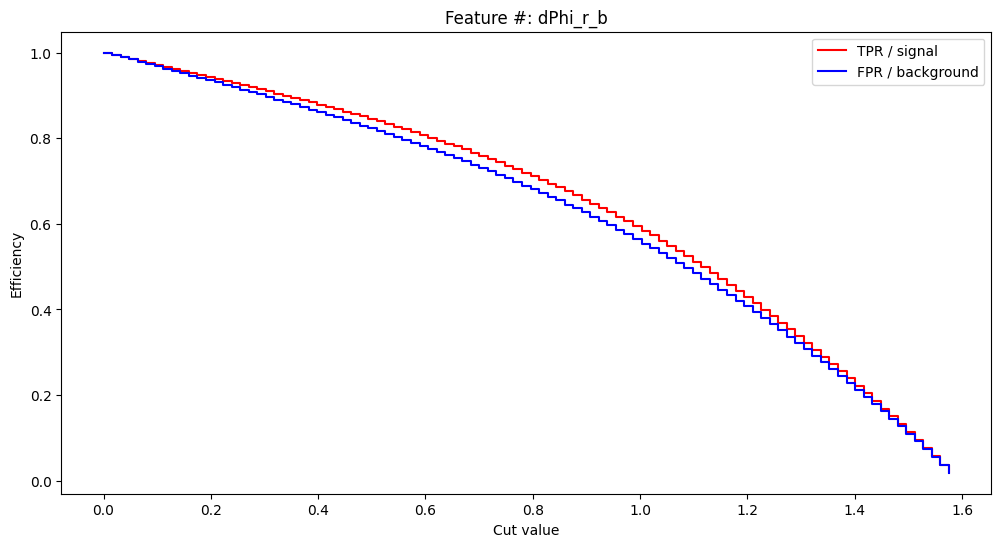

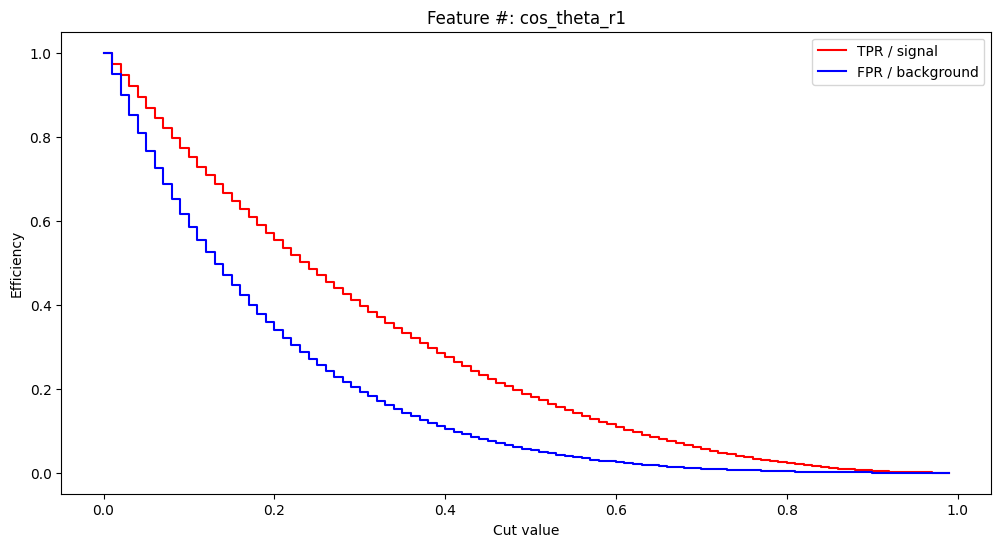

In [136]:
# 5.2
def get_curve(df, var, selection_type, num_checks = 100): # Curve for TPR / FPR
    values = df[var].to_numpy() # Pull an observable
    mu = np.mean(values) # Mean for x - mu

    if selection_type == "x > xc": # Counts each point above each cut value and reads the histogram from left to right.
        local_signal_values = df[df["signal"] == 1][var] # Signal value
        local_background_values = df[df["signal"] == 0][var] # Background values
        
        tpr_values, bins_signal = compute_rate(local_signal_values, bins = num_checks) # Signal efficiency with bins
        fpr_values, bins_signal = compute_rate(local_background_values, bins = bins_signal) # Background efficiency with bins

        xc_values = bins_signal[:-1] # Cut values from within the histogram bins

        return xc_values, tpr_values, fpr_values # Returns the curve(s)    
    
    if selection_type in ["x > xc", "x < xc"]: # Takes the observable range since the cut is directly on x.
        xc_values = np.linspace(values.min(), values.max(), num_checks)
    else:
        abs_values = np.abs(values - mu) # Distance from mean 
        xc_values = np.linspace(0, abs_values.max(), num_checks) # Checking for absolute value selection 

    local_signal = df["signal"] == 1 # Grabs signal rows in the current dataframe
    local_background = df["signal"] == 0 # Grabs background rows in the current dataframe

    tpr_values = [] # Signal efficency value
    fpr_values = [] # Background efficency value

    for xc in xc_values:
        tpr = selection_efficiency(df, var, local_signal, selection_type, xc, mu) # Signal fraction
        fpr = selection_efficiency(df, var, local_background, selection_type, xc, mu) # Background fraction

        tpr_values.append(tpr) # Stores signal efficiency 
        fpr_values.append(fpr) # Stores background efficiency

    return xc_values, tpr_values, fpr_values # Returns the XC, TPR and FPR values

find_selection = dict(zip(top_selection["variable"], top_selection["selection_type"]))

for var in VarNames[1:]: # Loops through each observable
    selection_type = find_selection[var] # Finds the best selection type

    xc_values, tpr_values, fpr_values = get_curve(df, var, selection_type, num_checks = 100) # Gets the TPR & FPR curve

    plt.figure(figsize=(12, 6)) # Creates the figure

    plt.step(xc_values, tpr_values, where = "post", color = "red", label = "TPR / signal") # Plots the signal efficiency
    plt.step(xc_values, fpr_values, where = "post", color = "blue", label = "FPR / background") # Plots the background efficiency

    plt.xlabel("Cut value")
    plt.ylabel("Efficiency")
    plt.title(f"Feature #: {var}")
    plt.legend()
    plt.show()

In [ ]:
With 5.3 I got stuck again, I used ChatGPT to figure out why.

In [ ]:
Here was my code before using ChatGPT.

/tmp/ipykernel_8053/1153350897.py:10: RuntimeWarning: invalid value encountered in divide
  significance = NS_prime / np.sqrt(NS_prime + NB_prime) # Stores sigma_S' = N'_S / sqrt(N'_S + N'_B)


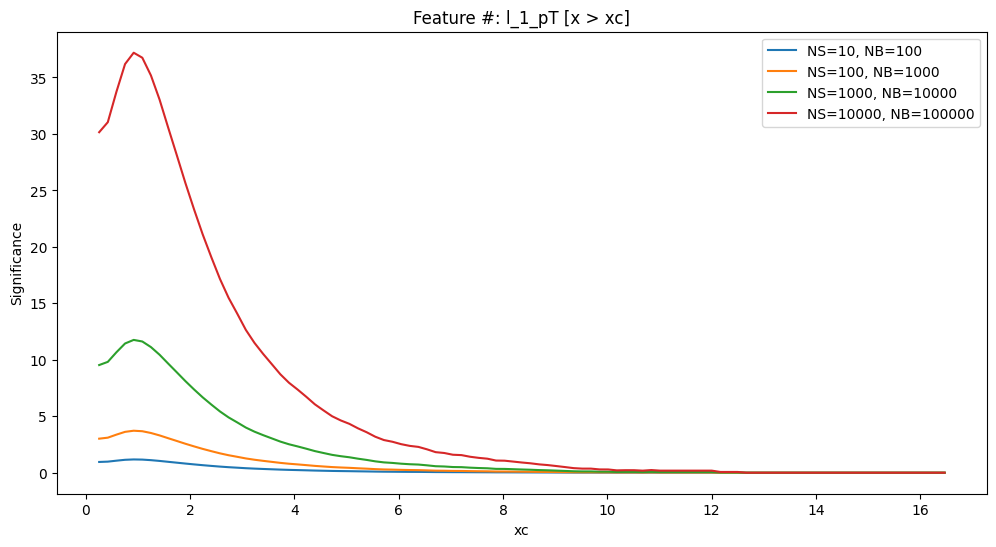

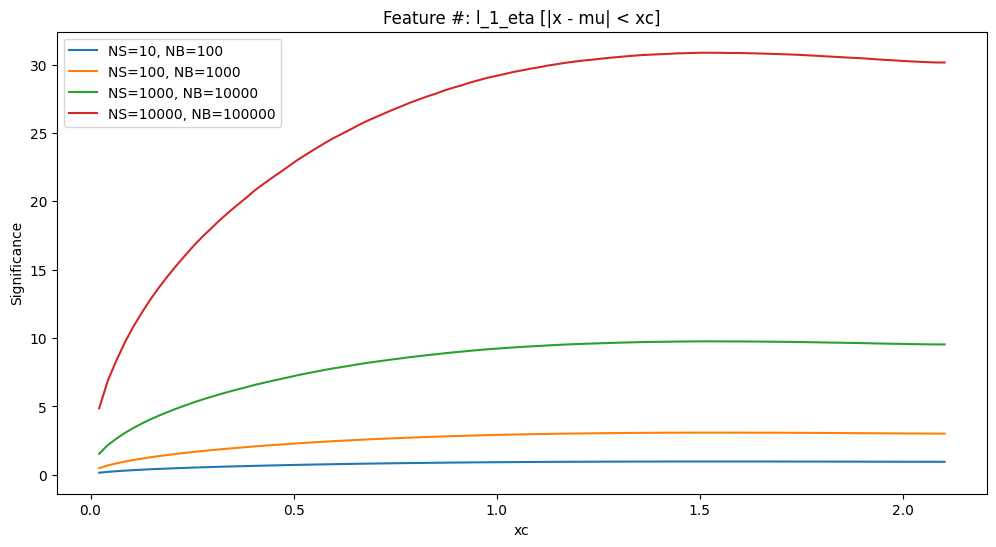

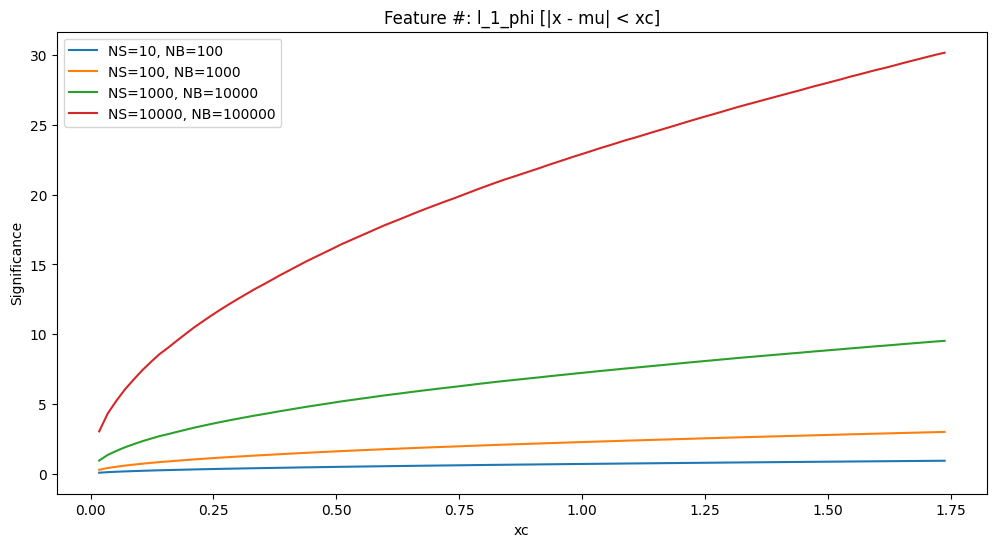

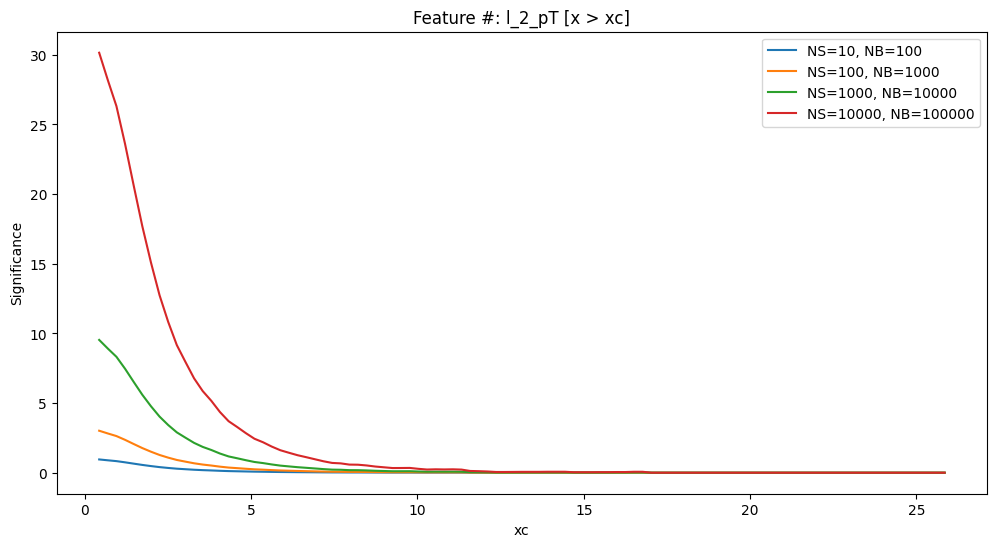

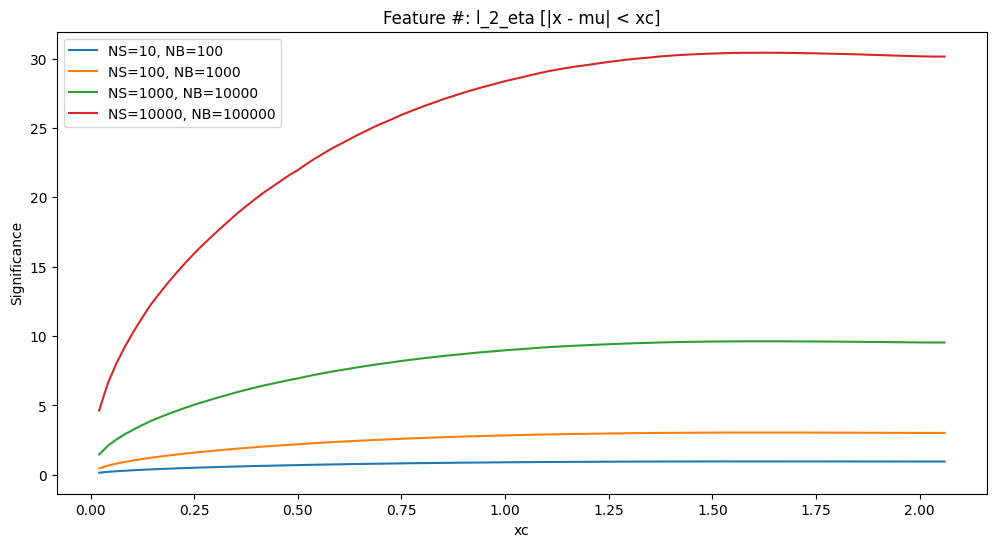

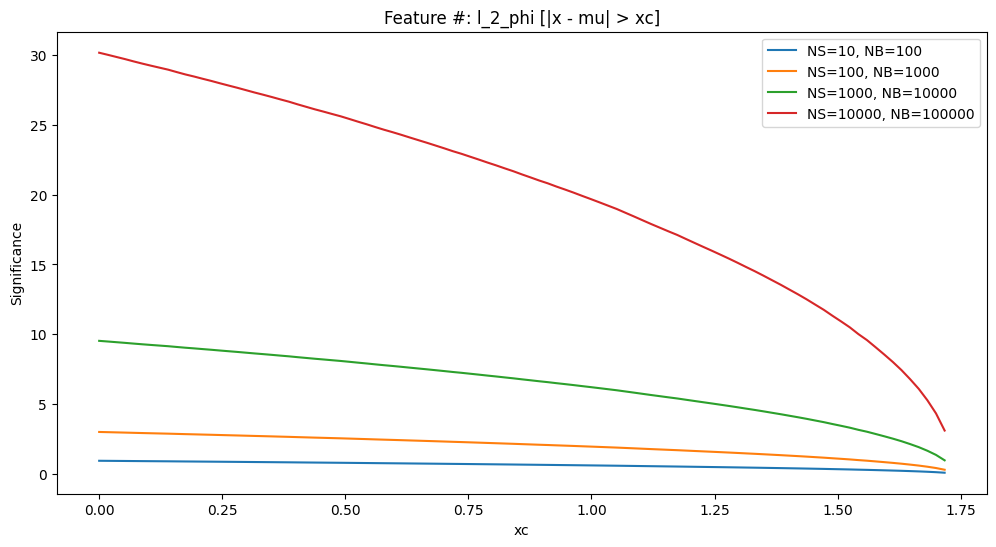

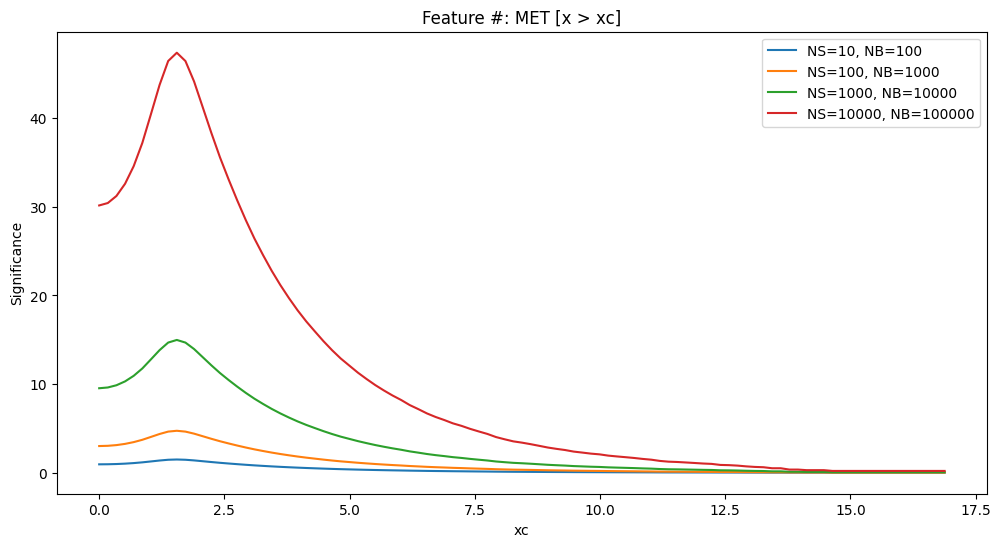

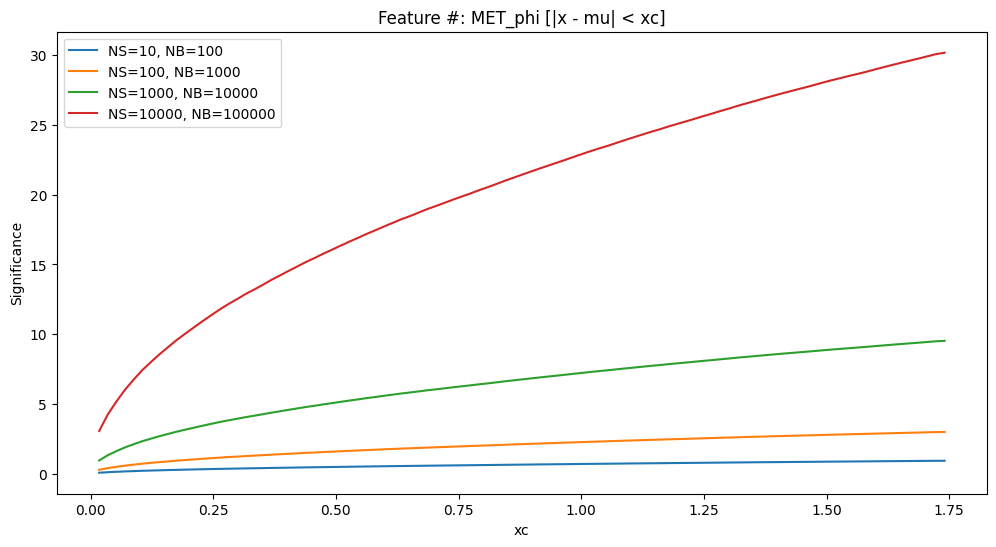

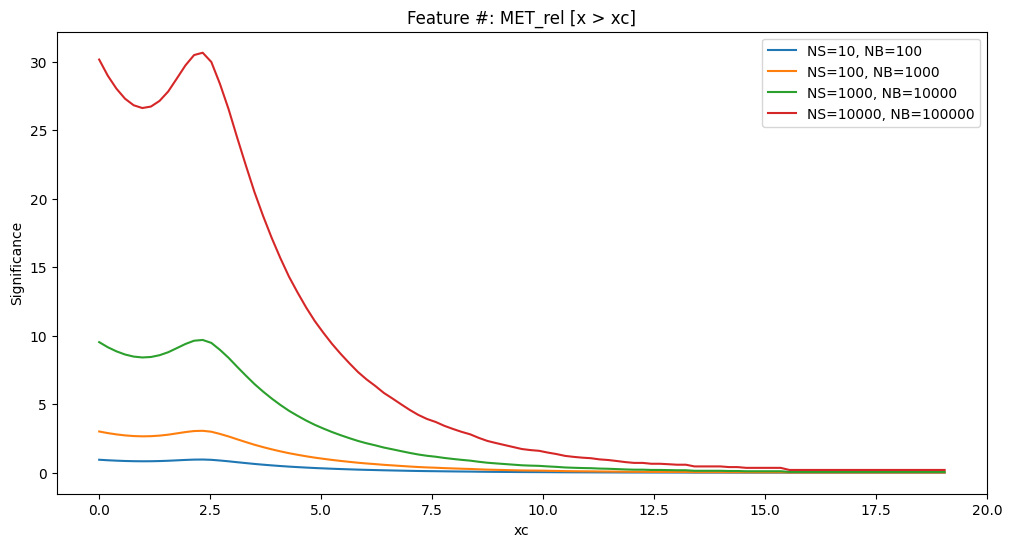

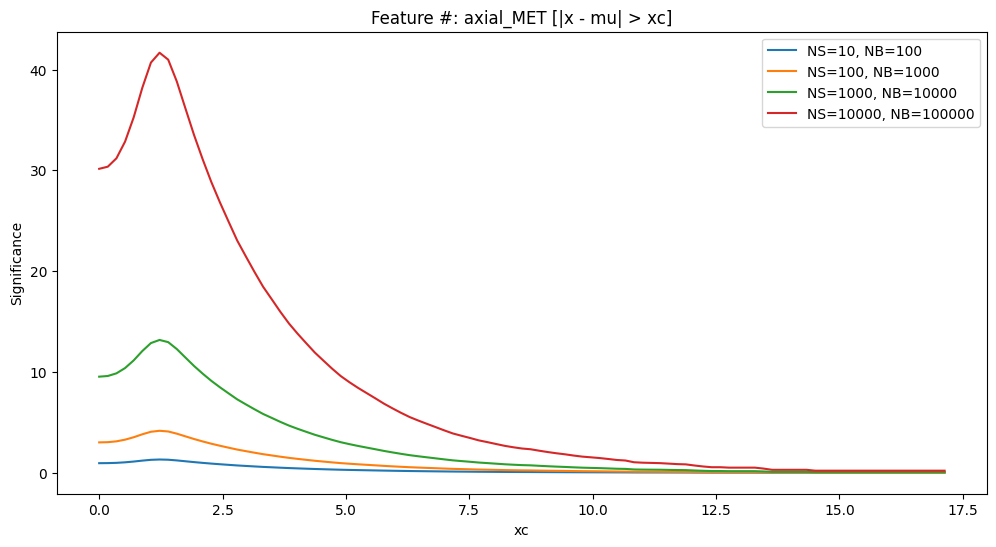

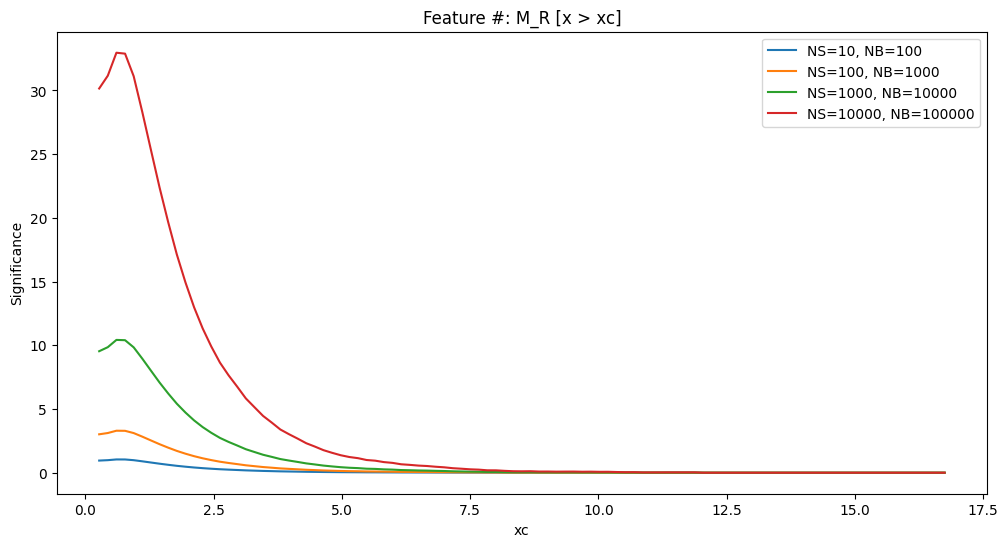

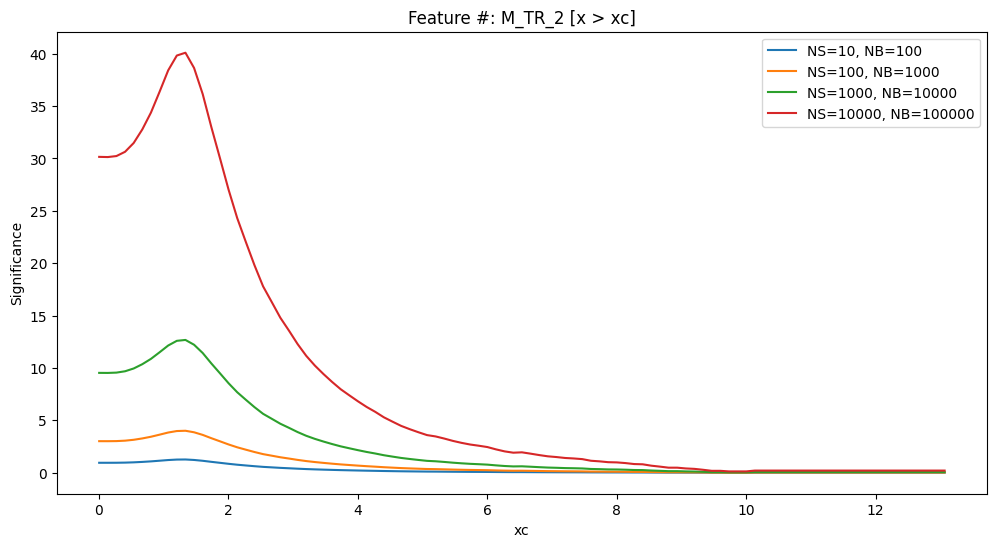

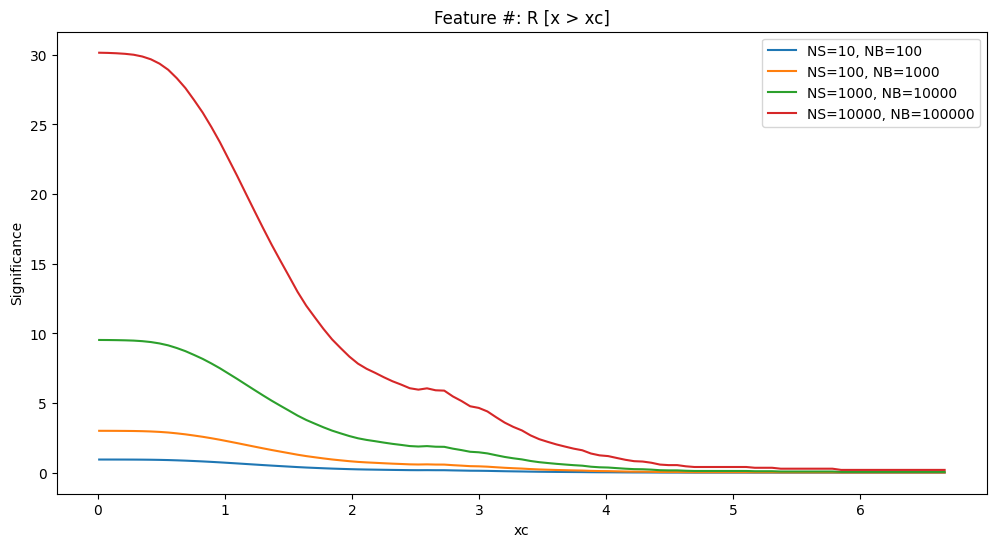

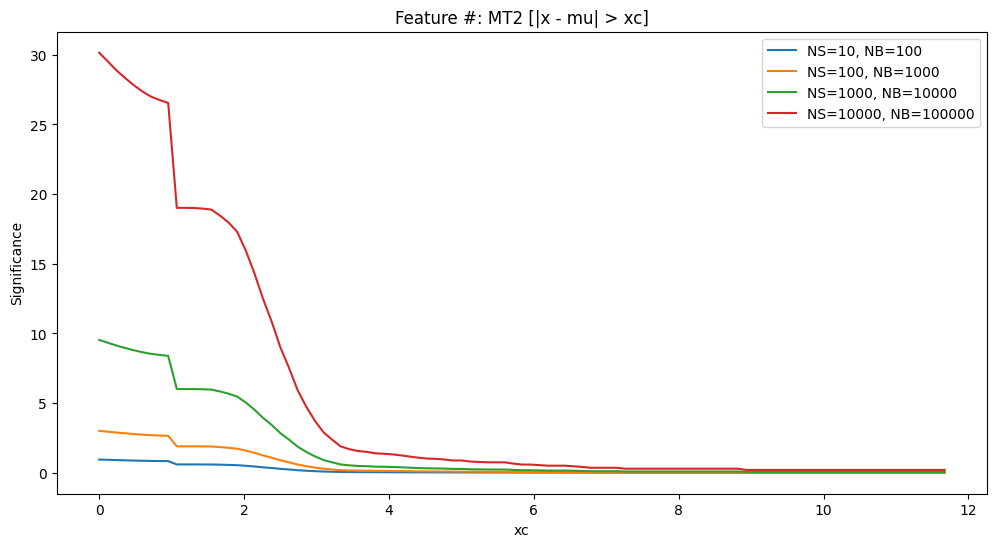

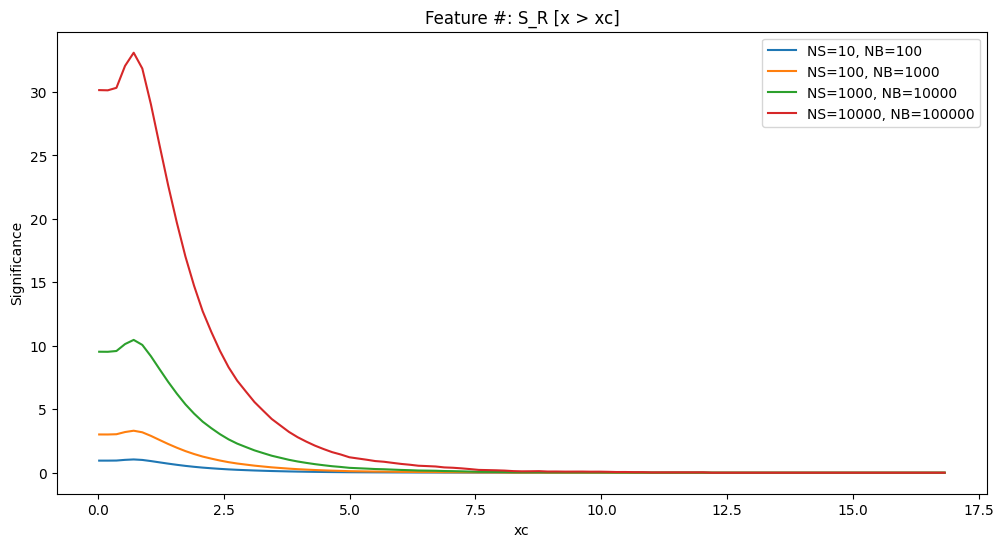

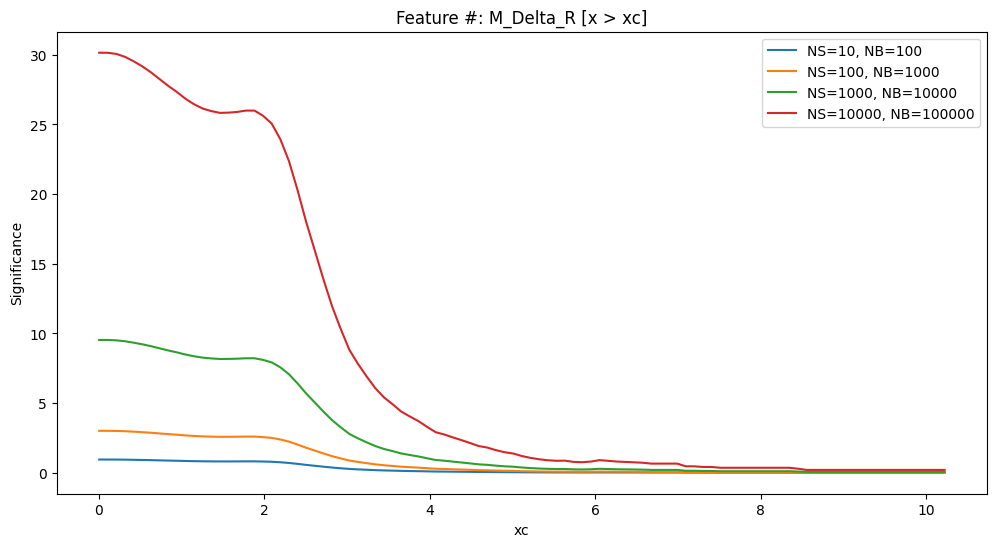

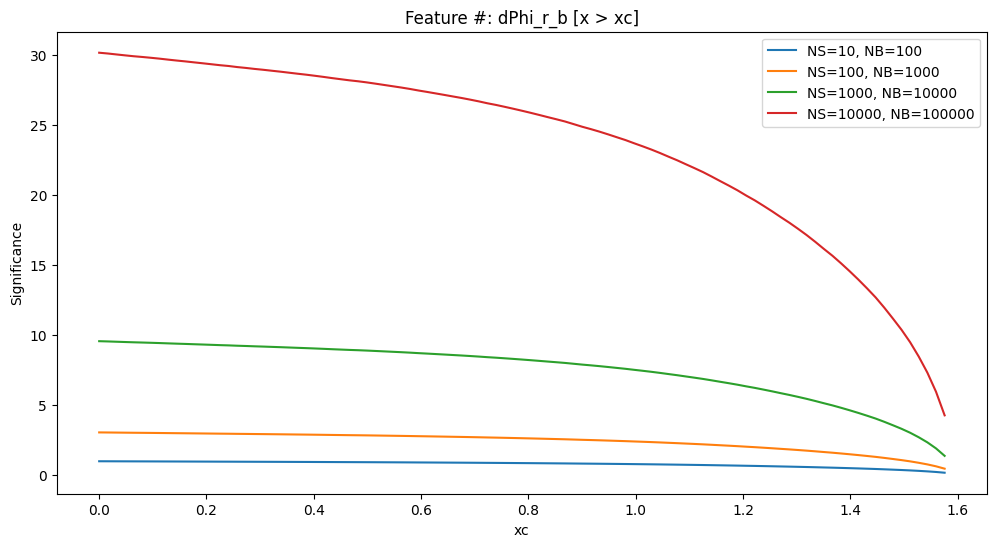

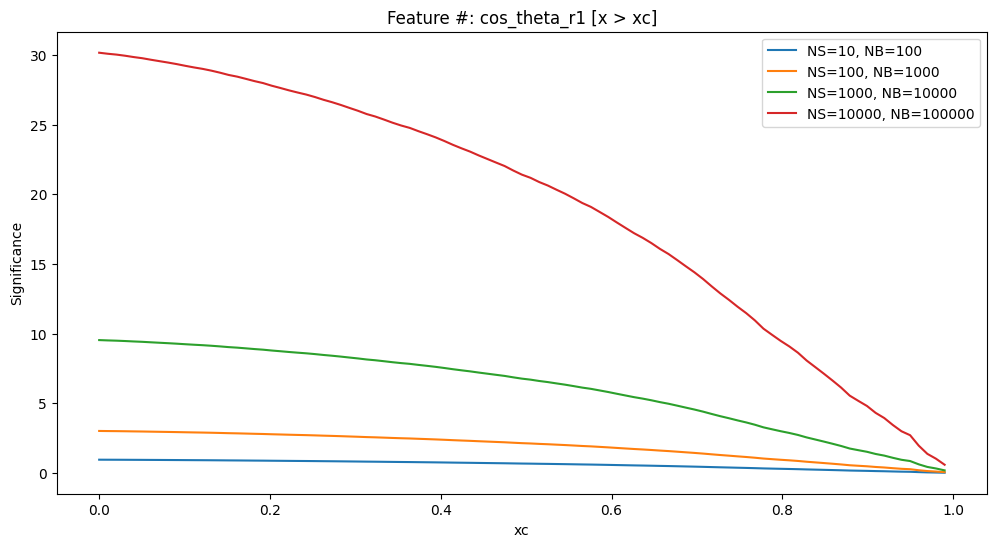

In [76]:
scenarios = [(10, 100), (100, 1000), (1000, 10000), (10000, 100000)] # Stores the req signal & background counts

def get_significance(tpr_values, fpr_values, NS, NB): # Converts lists to Numpy arrays so it can work across all values in xc and calculates it.
    tpr_values = np.array(tpr_values) # Stores epsilon_S (x_c)
    fpr_values = np.array(fpr_values) # Stores epsilon_B (x_c)

    NS_prime = tpr_values * NS # Stores N'_S = epsilon_S (x_c) * N_S
    NB_prime = fpr_values * NB # Stores N'_B = epsilon_B (x_c) * N_B

    significance = NS_prime / np.sqrt(NS_prime + NB_prime) # Stores sigma_S' = N'_S / sqrt(N'_S + N'_B)

    return significance # Returns the significance value for each XC


find_selection = dict(zip(top_selection["variable"], top_selection["selection_type"])) # Matches the variables to their best respective selection type

for var in VarNames[1:]: # Loops through each observable
    selection_type = find_selection[var] # Finds the best selection type
    xc_values, tpr_values, fpr_values = get_curve(df, var, selection_type, num_checks=100) # Gets TPR & FPR curve

    plt.figure(figsize=(12, 6)) # Creates the figure

    for NS, NB in scenarios: # Loops through each scenario of N_S and N_B's
        sigma_values = get_significance(tpr_values, fpr_values, NS, NB) # Gets significance values
        plt.plot(xc_values, sigma_values, label=f"NS={NS}, NB={NB}")

    plt.xlabel("xc")
    plt.ylabel("Significance")
    plt.title(f"Feature #: {var} [{selection_type}]")
    plt.legend()
    plt.show()

In [ ]:
ChatGPT's answer:


You are not doing anything major wrong. The warning is happening because for some cutoff values xc, zero events pass the selection.

Your formula is:

significance = NS_prime / np.sqrt(NS_prime + NB_prime)

For some strict selections:

NS_prime = 0
NB_prime = 0

So the formula becomes:

0 / sqrt(0 + 0)

which is:

0 / 0

Python does not know what to do with 0 / 0, so it gives you:

RuntimeWarning: invalid value encountered in divide

Think of it like this: you are asking, “How strong is my signal after the cut?” But for that cutoff, nothing survived the cut. No signal, no background. So the significance is not meaningful there.

The fix is to tell NumPy:

If the bottom of the fraction is zero, just put significance equal to zero.

Use this version of your function:

def get_significance(tpr_values, fpr_values, NS, NB): # Converts lists to NumPy arrays and calculates significance for each xc
    tpr_values = np.array(tpr_values) # Stores epsilon_S (x_c)
    fpr_values = np.array(fpr_values) # Stores epsilon_B (x_c)

    NS_prime = tpr_values * NS # Stores N'_S = epsilon_S (x_c) * N_S
    NB_prime = fpr_values * NB # Stores N'_B = epsilon_B (x_c) * N_B

    denominator = np.sqrt(NS_prime + NB_prime) # Stores sqrt(N'_S + N'_B)

    significance = np.divide(
        NS_prime,
        denominator,
        out=np.zeros_like(NS_prime),
        where=denominator != 0
    ) # Calculates significance and avoids dividing by zero

    return significance # Returns the significance value for each XC

Why this works:

where=denominator != 0

means:

Only divide when the bottom number is not zero.

And:

out=np.zeros_like(NS_prime)

means:

If the bottom is zero, put 0 there instead.

So your code is conceptually correct. You just needed to handle the cutoff points where no events pass. That is common in scans like this.

In [ ]:
My code after ChatGPT:

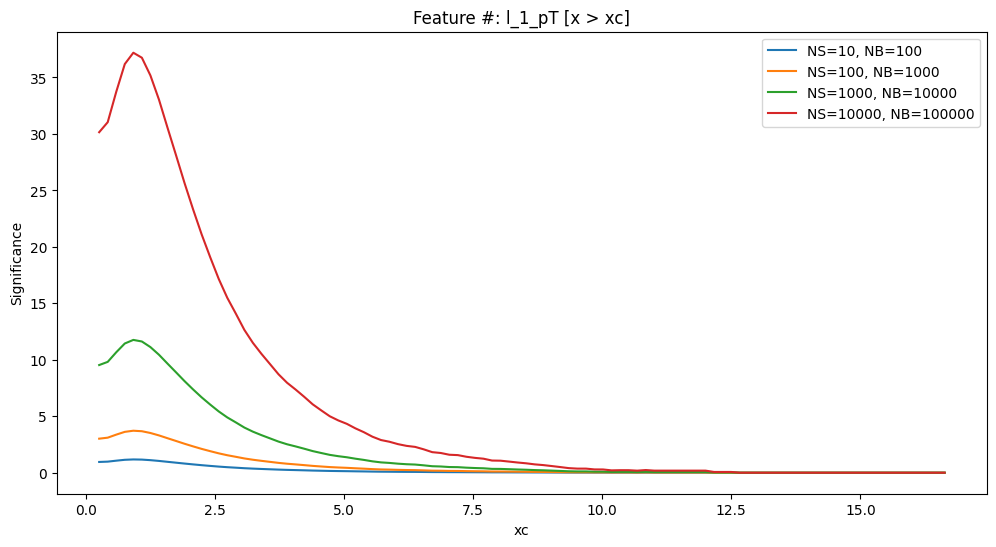

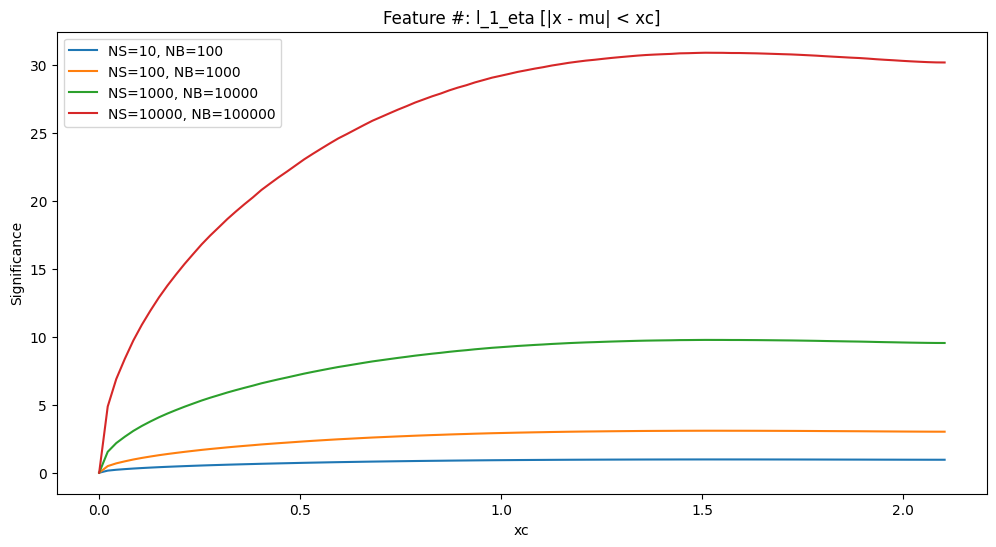

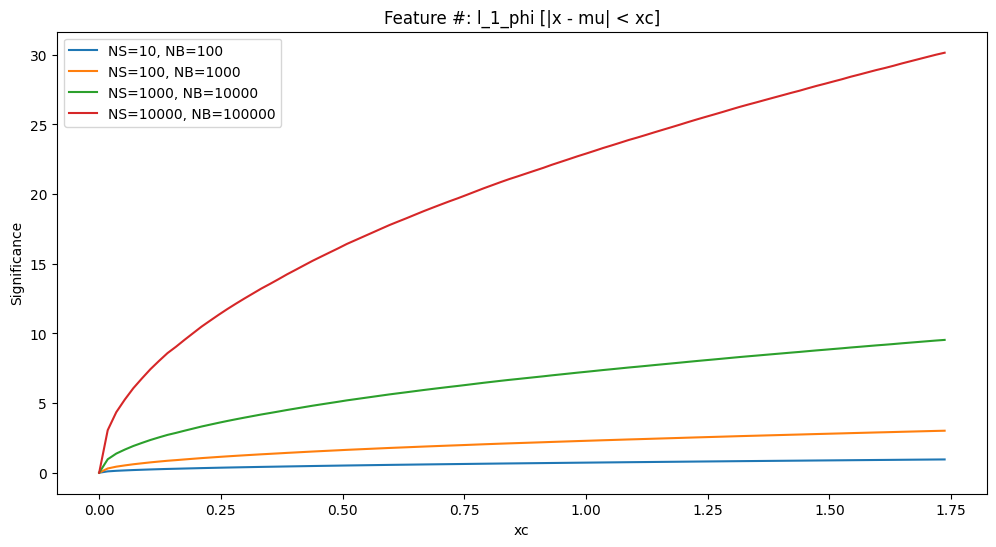

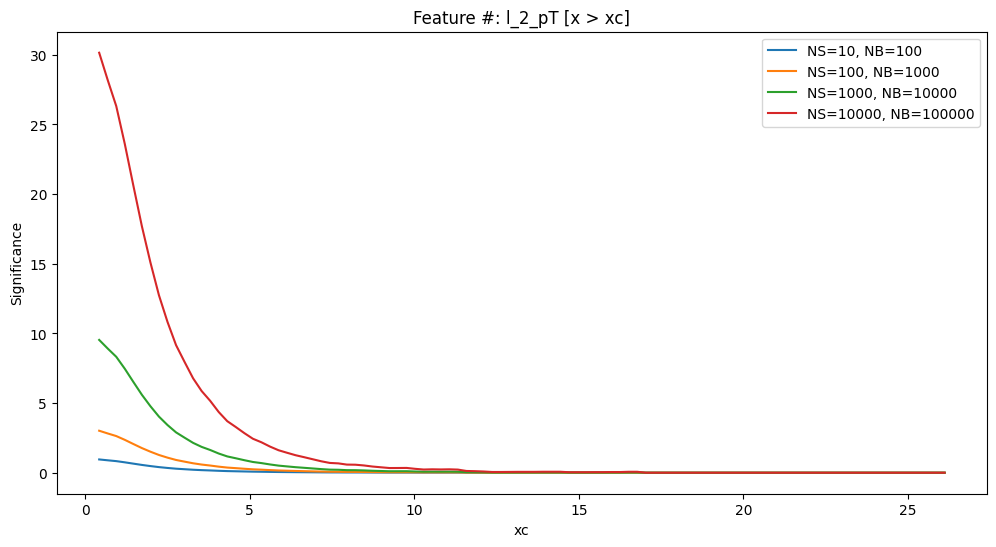

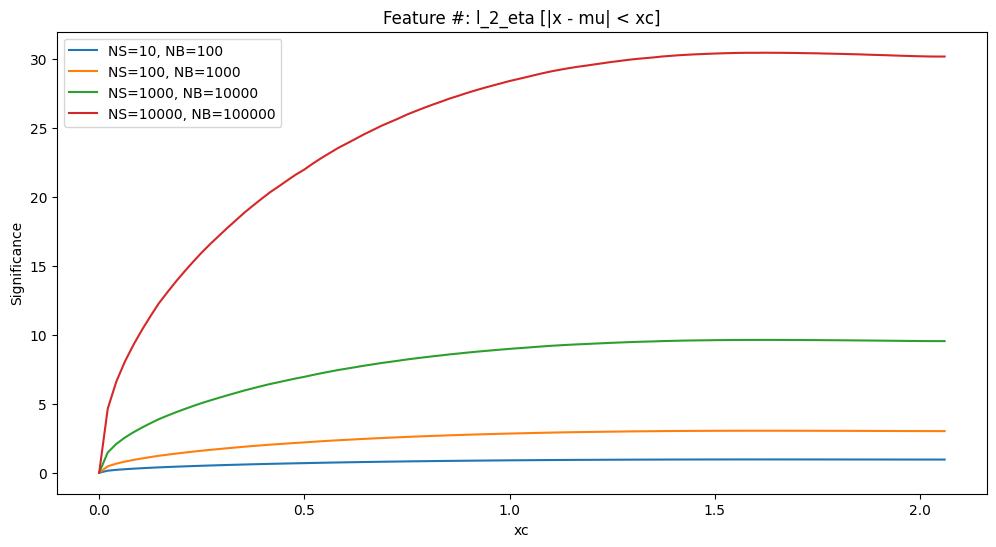

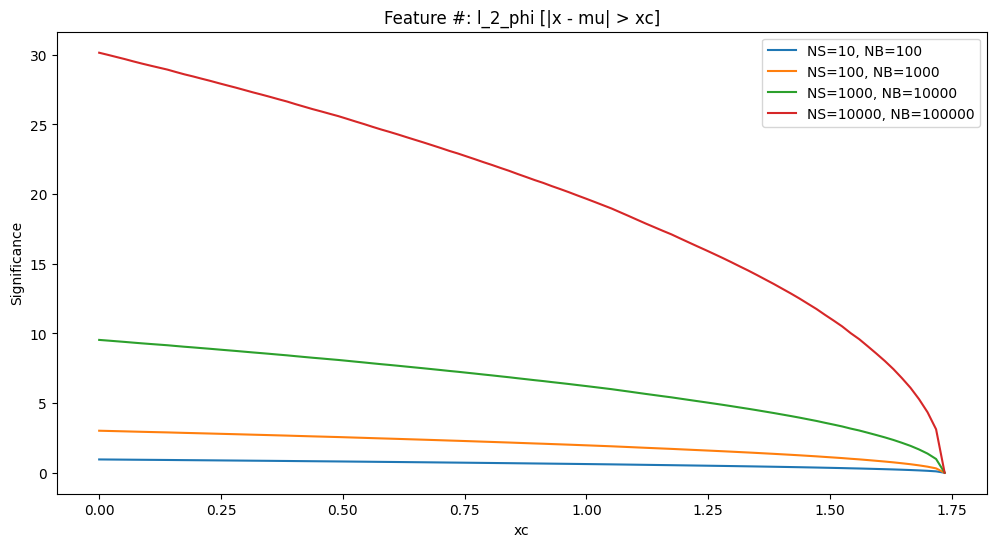

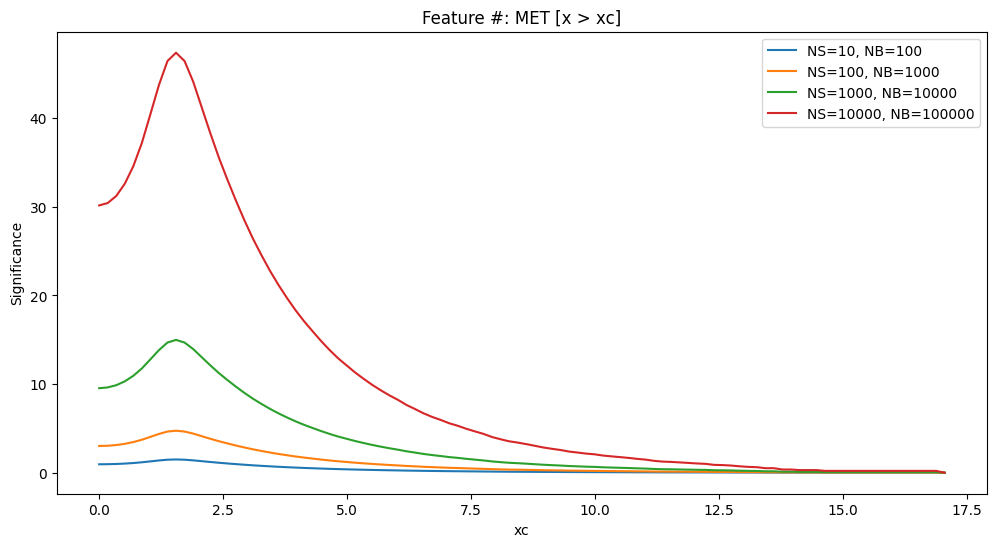

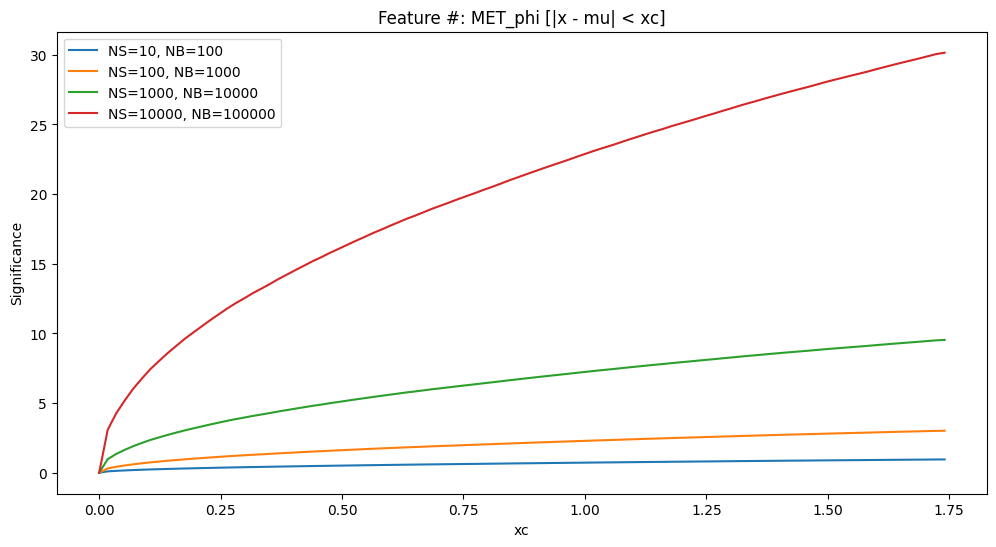

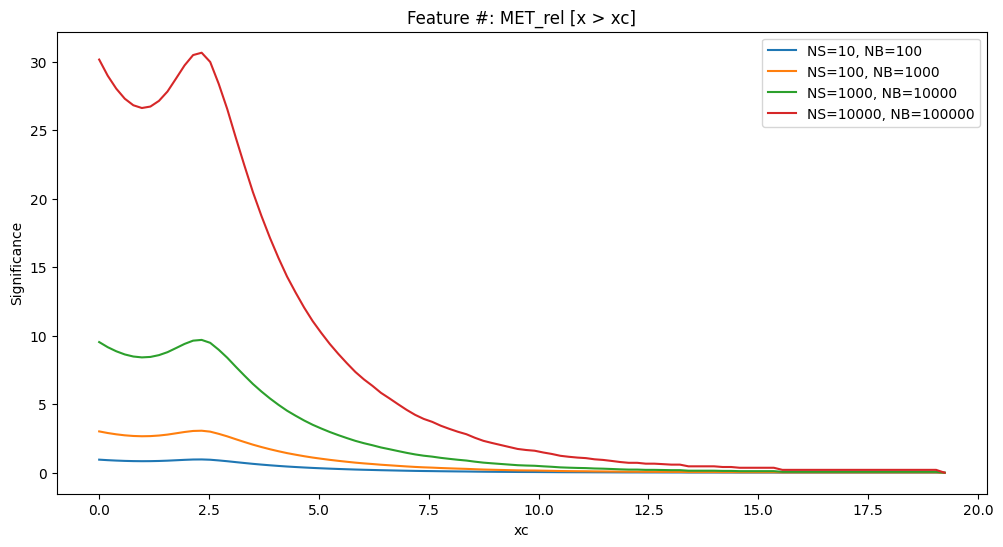

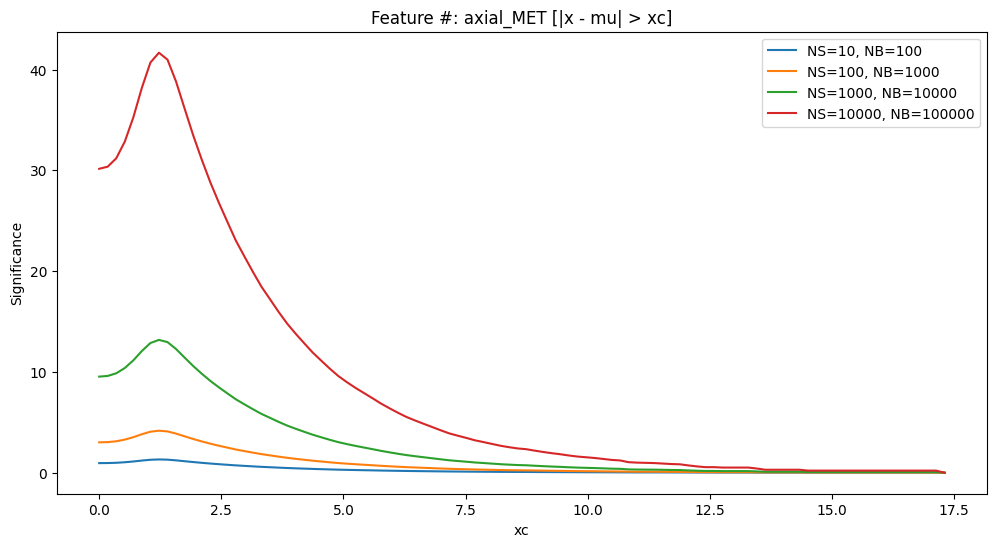

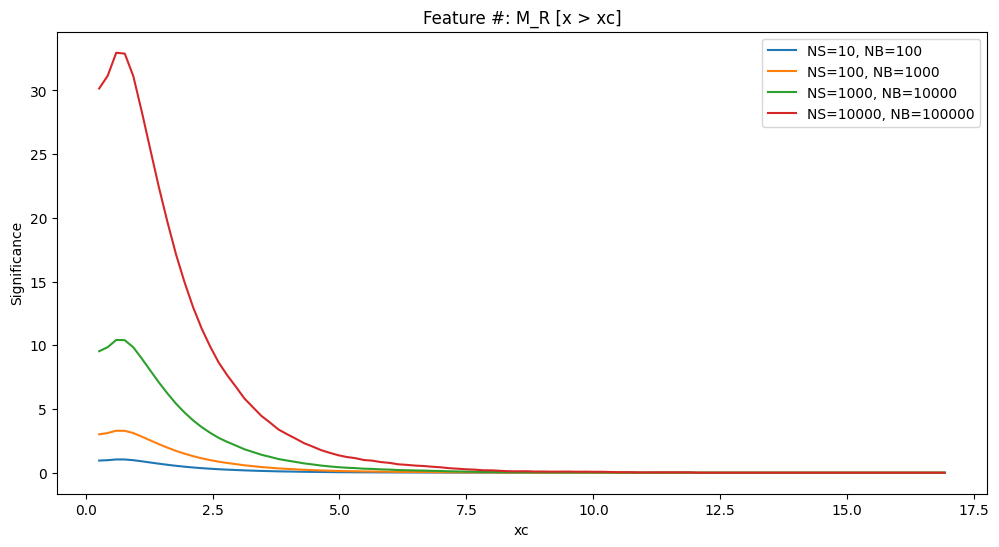

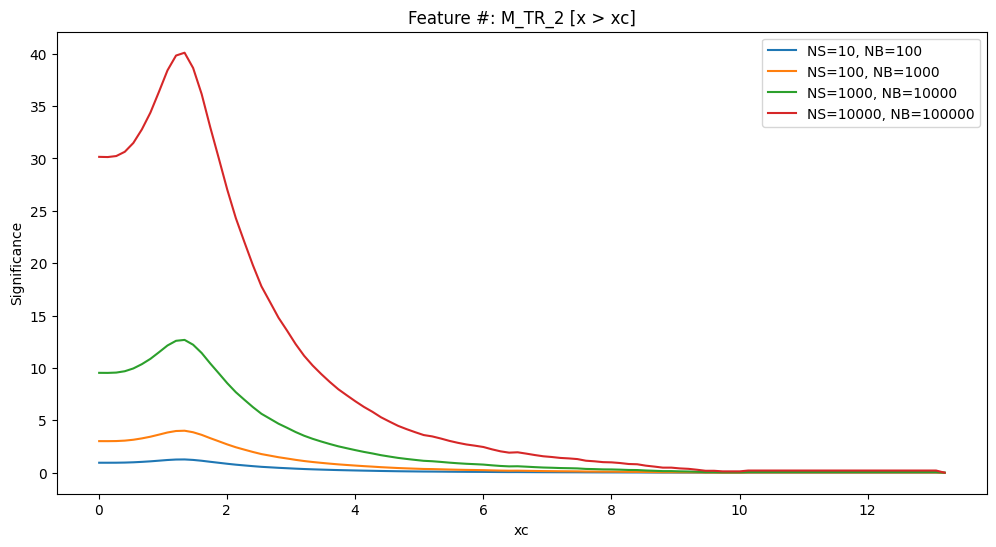

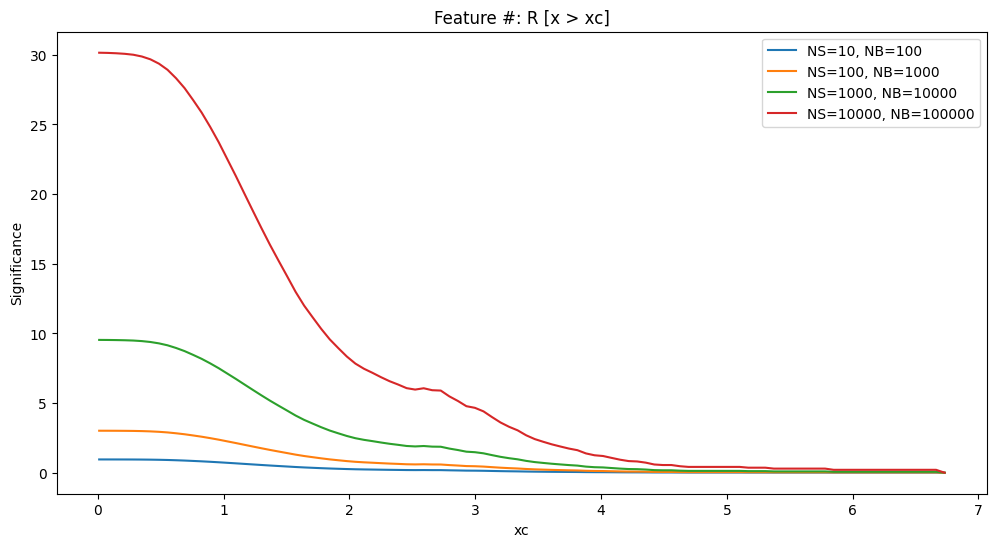

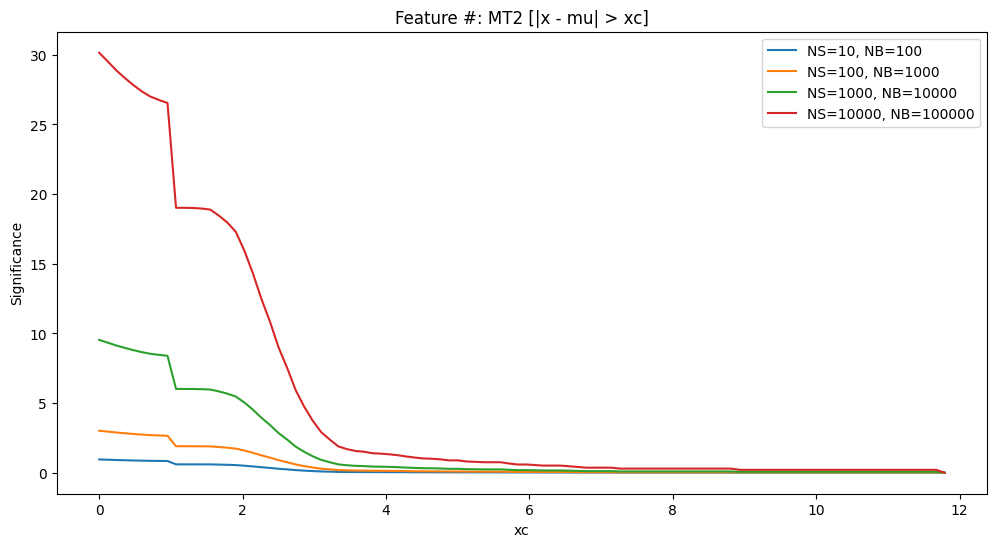

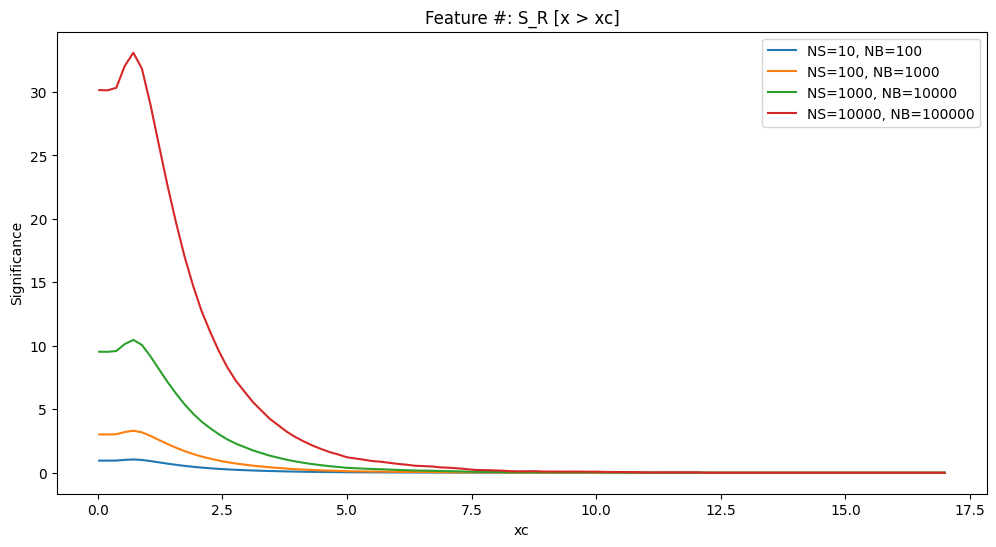

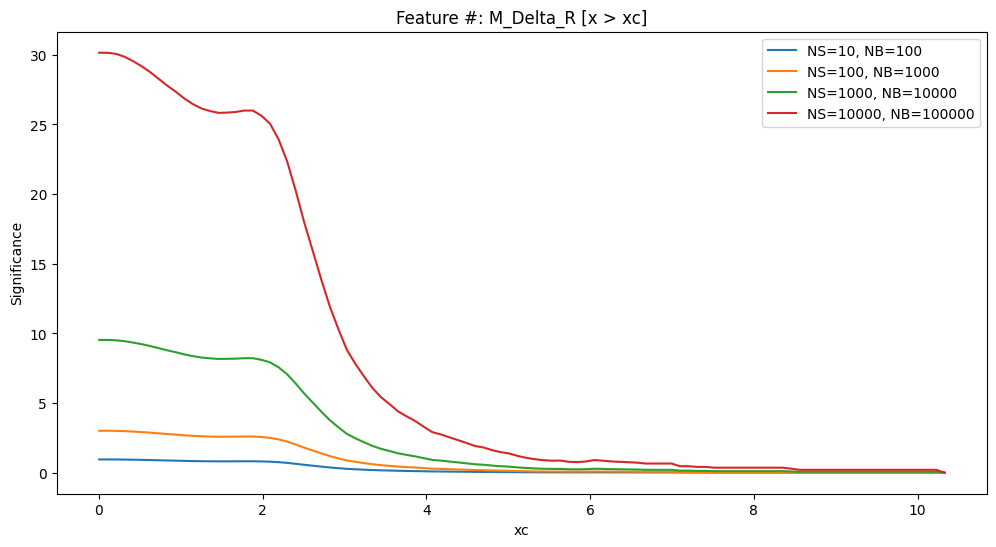

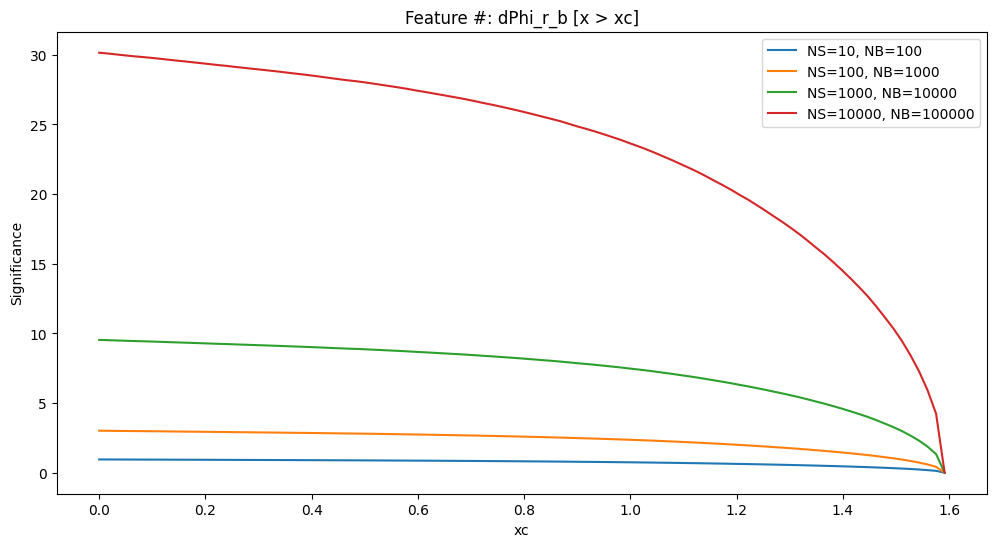

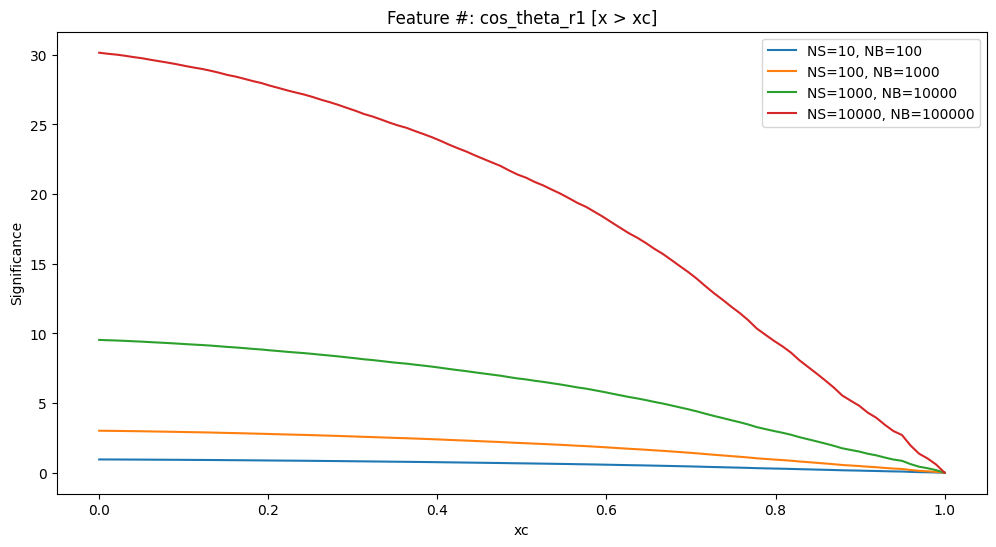

In [107]:
scenarios = [(10, 100), (100, 1000), (1000, 10000), (10000, 100000)] # Stores the req signal & background counts

def get_significance(tpr_values, fpr_values, NS, NB): # Converts lists to Numpy arrays so it can work across all values in xc and calculates it.
    tpr_values = np.array(tpr_values) # Stores epsilon_S (x_c)
    fpr_values = np.array(fpr_values) # Stores epsilon_B (x_c)

    NS_prime = tpr_values * NS # Stores N'_S = epsilon_S (x_c) * N_S
    NB_prime = fpr_values * NB # Stores N'_B = epsilon_B (x_c) * N_B

    denominator_value = np.sqrt(NS_prime + NB_prime) # Stores sqrt(N'_S + N'_B)
    
    significance = np.divide(NS_prime, denominator_value, out = np.zeros_like(NS_prime), where = denominator_value != 0) # Stores sigma_S' = N'_S / sqrt(N'_S + N'_B) and avoids 0/0.

    return significance # Returns the significance value for each XC


find_selection = dict(zip(top_selection["variable"], top_selection["selection_type"])) # Matches the variables to their best respective selection type

for var in VarNames[1:]: # Loops through each observable
    selection_type = find_selection[var] # Finds the best selection type
    xc_values, tpr_values, fpr_values = get_curve(df, var, selection_type, num_checks=100) # Gets TPR & FPR curve

    plt.figure(figsize=(12, 6)) # Creates the figure

    for NS, NB in scenarios: # Loops through each scenario of N_S and N_B's
        sigma_values = get_significance(tpr_values, fpr_values, NS, NB) # Gets significance values
        plt.plot(xc_values, sigma_values, label=f"NS={NS}, NB={NB}")

    plt.xlabel("xc")
    plt.ylabel("Significance")
    plt.title(f"Feature #: {var} [{selection_type}]")
    plt.legend()
    plt.show()

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [137]:
# 6.1
three_subsets = top_selection.head(3) # Takes the top 3 observables from the selection table
display(three_subsets[["variable", "selection_type", "xc", "signal_efficiency", "background_efficiency", "score"]]) # Displays the columns of the selection table

,variable,selection_type,xc,signal_efficiency,background_efficiency,score
6,MET,x > xc,1.034312,0.558202,0.134635,0.423567
4,l_1_pT,x > xc,0.917198,0.621527,0.217126,0.404401
8,M_TR_2,x > xc,1.075458,0.556226,0.154099,0.402127


In [ ]:
# These observables were the strongest out of their previous scan of the data, out of the table; based off of their 
# signal efficiencies being high and their background efficiencies being low overall.

In [138]:
# 6.2
def passes_selection(df, var, selection_type, xc, mu): # Finds and applies the rule to the selected observable.
    if selection_type == "x > xc": 
        return df[var] > xc
    if selection_type == "x < xc": 
        return df[var] < xc
    if selection_type == "|x - mu| > xc": 
        return np.abs(df[var] - mu) > xc
    if selection_type == "|x - mu| < xc": 
        return np.abs(df[var] - mu) < xc

def make_cutflow(df, selections, NS, NB): # Makes the cutflow table for that scenario
    current_table_values = list() #Stores the tables rows in a list.

    signal = df["signal"] == 1 # Starts w/ the signal rows
    background = df["signal"] == 0 # Starts w/ the background rows

    total_signal = np.sum(signal) # Stores the total signal datapoints before the selections.
    total_background = np.sum(background) # Stores the total background datapoints before the selections.

    current_selection = np.ones(len(df), dtype = bool) # Starts with all events passing before any cuts
    
    for i in range(len(selections)):
        var = selections["variable"].values[i] # Gets the observable name
        selection_type = selections["selection_type"].values[i] # Gets the type
        
        xc = selections["xc"].values[i] # Gets xc
        mu = selections["mu"].values[i] # Gets mu

        grab_selection = passes_selection(df, var, selection_type, xc, mu)


        current_selection = current_selection & grab_selection # Keeps only events that passed all cuts so farand stores them for now

        signal_after_cut = signal & current_selection # Stores the signal rows that passed the passed all cuts so far
        background_after_cut = background & current_selection # Stores the background rows that passed all cuts so far

        epsilon_signal = np.sum(signal_after_cut) / total_signal # Stores the signal efficiency
        epsilon_background = np.sum(background_after_cut) / total_background # Stores the background efficiency


        NS_prime = epsilon_signal * NS
        NB_prime = epsilon_background * NB

        significance = NS_prime / np.sqrt(NS_prime + NB_prime) if NS_prime + NB_prime > 0 else 0 # Stores the significance

        current_table_values.append([i + 1, var, selection_type, xc, epsilon_signal, epsilon_background, NS_prime, NB_prime, significance]) # Adds rows to the table

    return pd.DataFrame(current_table_values, columns=["Step", "Variable", "Selection", "xc", "epsilon_S", "epsilon_B", "N'_S", "N'_B", "significance"]) # Returns the table and tabulates it

for scenario_name in scenarios: # Loops through each scenario
    NS = scenarios[scenario_name][0] # Gets all signal events
    NB = scenarios[scenario_name][1] # Gets all background events

    print(f"{scenario_name}: [NS = {NS}], [NB = {NB}]") # Prints the scenario that's currently being used.

    if "scenario" in three_subsets.columns: # Finds any scenario-specific cuts if they exist
        scenario_selections = three_subsets[three_subsets["scenario"] == scenario_name]
    else:
        scenario_selections = three_subsets # Uses the same cuts for every scenario

    display(make_cutflow(df, scenario_selections, NS, NB).round(4)) # Displays the table

Scenario 1: [NS = 10], [NB = 100]


,Step,Variable,Selection,xc,epsilon_S,epsilon_B,N'_S,N'_B,significance
0,1,MET,x > xc,1.0343,0.5582,0.1346,5.5820,13.4635,1.2791
1,2,l_1_pT,x > xc,0.9172,0.3815,0.0411,3.8149,4.1129,1.3549
2,3,M_TR_2,x > xc,1.0755,0.3435,0.0402,3.4348,4.0165,1.2583


Scenario 2: [NS = 100], [NB = 1000]


,Step,Variable,Selection,xc,epsilon_S,epsilon_B,N'_S,N'_B,significance
0,1,MET,x > xc,1.0343,0.5582,0.1346,55.8202,134.6346,4.0448
1,2,l_1_pT,x > xc,0.9172,0.3815,0.0411,38.1491,41.1294,4.2846
2,3,M_TR_2,x > xc,1.0755,0.3435,0.0402,34.3475,40.1655,3.9791


Scenario 3: [NS = 1000], [NB = 10000]


,Step,Variable,Selection,xc,epsilon_S,epsilon_B,N'_S,N'_B,significance
0,1,MET,x > xc,1.0343,0.5582,0.1346,558.2019,1346.3463,12.7907
1,2,l_1_pT,x > xc,0.9172,0.3815,0.0411,381.4914,411.2943,13.5490
2,3,M_TR_2,x > xc,1.0755,0.3435,0.0402,343.4753,401.6546,12.5829


Scenario 4: [NS = 10000], [NB = 100000]


,Step,Variable,Selection,xc,epsilon_S,epsilon_B,N'_S,N'_B,significance
0,1,MET,x > xc,1.0343,0.5582,0.1346,5582.0192,13463.4633,40.4478
1,2,l_1_pT,x > xc,0.9172,0.3815,0.0411,3814.9142,4112.9434,42.8457
2,3,M_TR_2,x > xc,1.0755,0.3435,0.0402,3434.7532,4016.5463,39.7905


In [139]:
def update_selection(df, first_variable, second_variable): # Uses the first variable then re-optimizes with the second.
    find_selection = dict(zip(top_selection["variable"], top_selection["selection_type"])) # Matches the variables to their respective selections
    find_xc = dict(zip(top_selection["variable"], top_selection["xc"])) # Matches to xc val
    find_mu = dict(zip(top_selection["variable"], top_selection["mu"])) # Matches to mu val

    first_selection = find_selection[first_variable] # Grabs the 1st var's selection type
    first_xc = find_xc[first_variable] # Grabs the 1st var's xc value
    first_mu = find_mu[first_variable] # Grabs the 1st var's mu value

    first_pass = passes_selection(df, first_variable, first_selection, first_xc, first_mu) # Selects the first variable and passes it to the dataframe

    df_filtered = df[first_pass].reset_index(drop = True) # Passes the rows and resets the index

    second_result = find_top_selection(df_filtered, second_variable) # Re-optimizes the 2nd var on the filtered data

    second_result["first_variable"] = first_variable # Stores the first variable
    second_result["first_selection"] = first_selection # Stores the first selection type
    second_result["first_xc"] = first_xc # Stores the first cut value
    second_result["events_after_first_cut"] = len(df_filtered) # Stores how many events remain
    
    return second_result # Returns the new result for the second var

result_1 = update_selection(df, "MET", "M_TR_2")
result_1["Order"] = "MET first, then M_TR_2"

result_2 = update_selection(df, "M_TR_2", "MET")
result_2["Order"] = "M_TR_2 first, then MET"

display(pd.DataFrame([result_1, result_2]))

,variable,selection_type,xc,mu,signal_efficiency,background_efficiency,score,first_variable,first_selection,first_xc,events_after_first_cut,Order
10,M_TR_2,x > xc,1.349164,1.519233,0.596687,0.261433,0.335254,MET,x > xc,1.034312,164418,"MET first, then M_TR_2"
8,MET,x > xc,1.542929,1.679348,0.496118,0.087194,0.408924,M_TR_2,x > xc,1.075458,169235,"M_TR_2 first, then MET"


## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



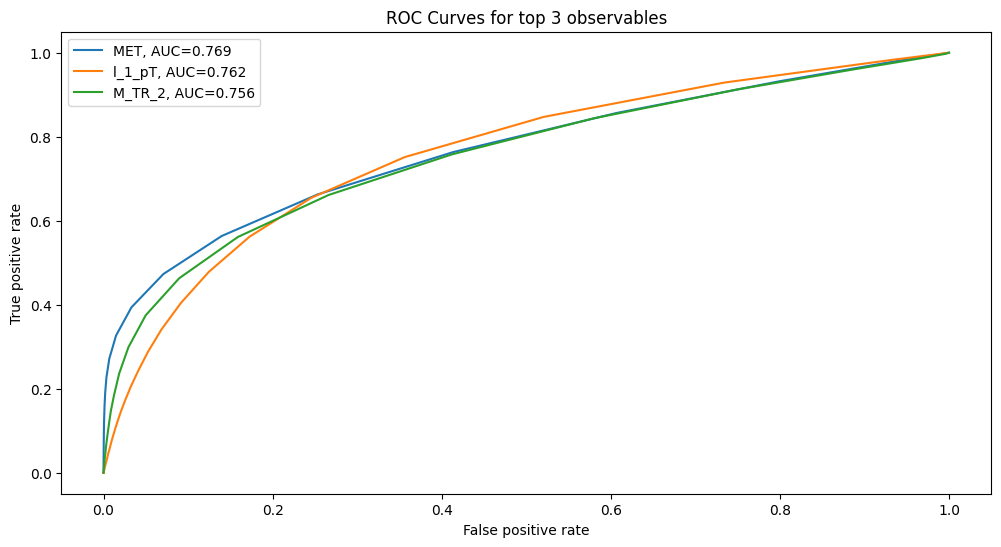

In [140]:
# 7.1
plt.figure(figsize=(12, 6)) # Creates the figure for all 3 ROC

for i in range(len(three_subsets)): # Loops through the top 3 observables
    variable = three_subsets["variable"].values[i] # Gets observable name
    selection_type = three_subsets["selection_type"].values[i] # Gets selection type

    xc_values, tpr_values, fpr_values = get_curve(df, variable, selection_type, num_checks = 100) # Gets the TPR/FPR curve

    fpr_values = np.array(fpr_values) #Converts FPR value to a numpy array
    tpr_values = np.array(tpr_values) # Converts TPR values to a numpy array

    if fpr_values[0] > fpr_values[-1]: # Makes FPR go from low to high
        fpr_values = fpr_values[::-1] # Sorts the FPR values
        tpr_values = tpr_values[::-1] # Sorts the FPR values

    area_under_curve = np.trapezoid(tpr_values, fpr_values) # Finds area under curve

    plt.plot(fpr_values, tpr_values, label=f"{variable}, AUC={area_under_curve:.3f}") # Plots the ROC curve

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC Curves for top 3 observables")
plt.legend()
plt.show()

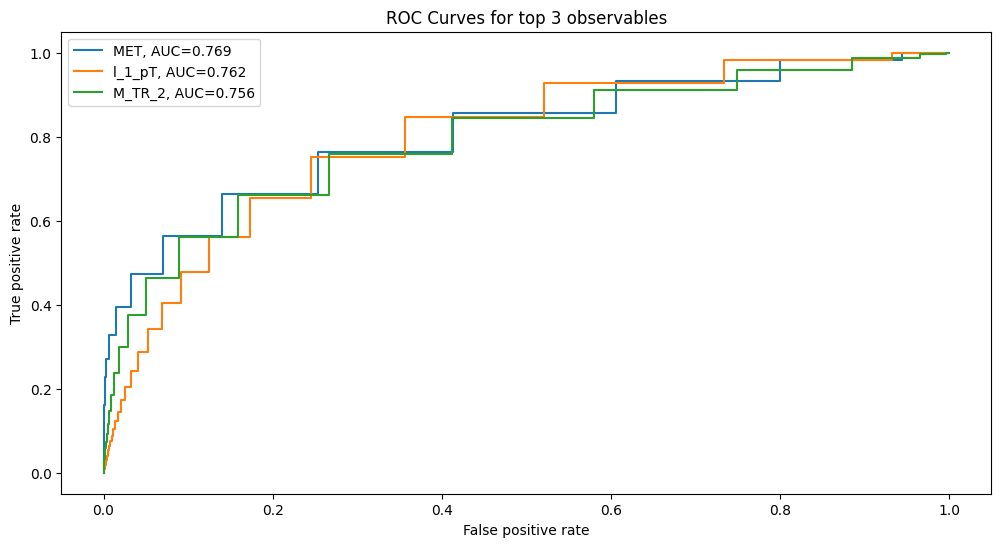

In [141]:
# 7.2
def plot_roc_curve(df, observables, title = "ROC Curves for top 3 observables", num_checks = 100): # Function to take the ROC curve
    plt.figure(figsize=(12, 6)) # Creates the figure for all 3 ROC
    
    for i in range(len(observables)): # Loops through the top 3 observables
        variable = observables["variable"].values[i] # Gets observable name
        selection_type = observables["selection_type"].values[i] # Gets selection type
    
        xc_values, tpr_values, fpr_values = get_curve(df, variable, selection_type, num_checks = num_checks) # Gets the TPR/FPR curve
    
        fpr_values = np.array(fpr_values) #Converts FPR value to a numpy array
        tpr_values = np.array(tpr_values) # Converts TPR values to a numpy array
    
        if fpr_values[0] > fpr_values[-1]: # Makes FPR go from low to high
            fpr_values = fpr_values[::-1] # Sorts the FPR values
            tpr_values = tpr_values[::-1] # Sorts the FPR values
    
        area_under_curve = np.trapezoid(tpr_values, fpr_values) # Finds area under curve
    
        plt.step(fpr_values, tpr_values, label=f"{variable}, AUC={area_under_curve:.3f}") # Plots the ROC curve
    
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(title)
    plt.legend()
    plt.show()

plot_roc_curve(df, three_subsets)

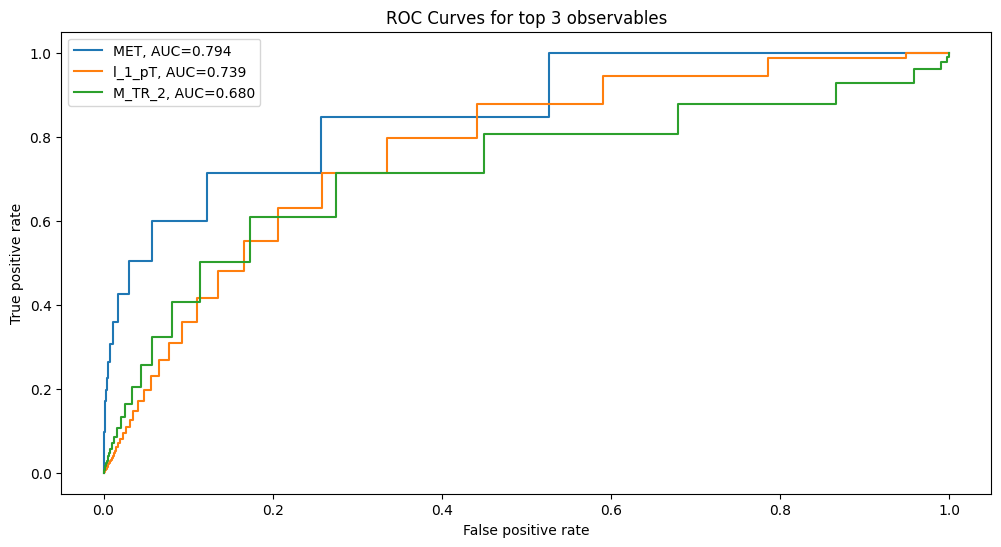

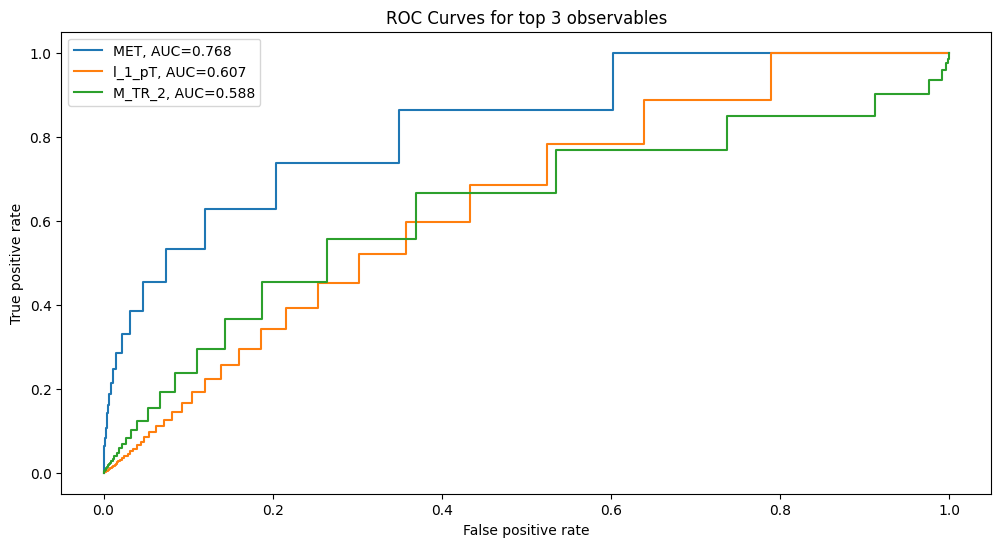

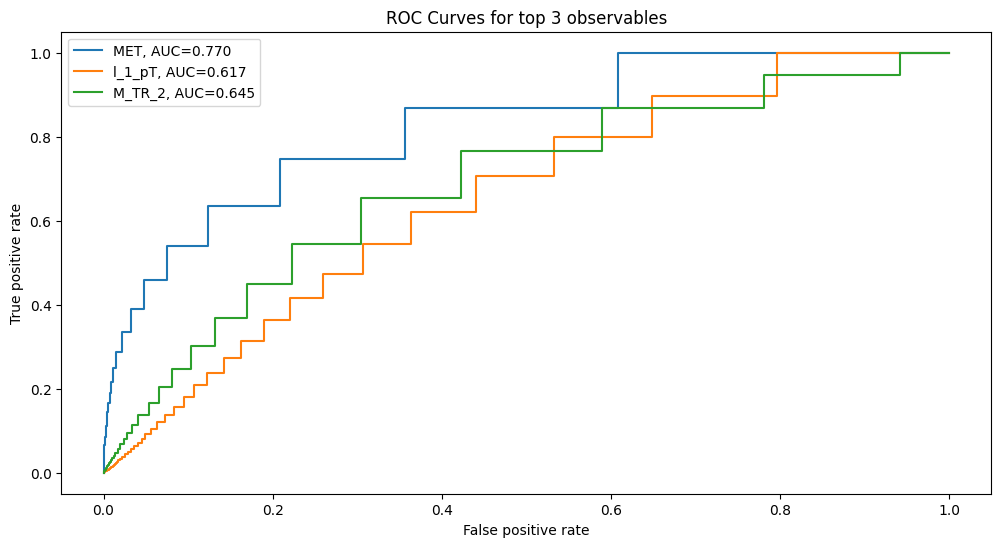

In [142]:
# 7.3
df_current = df.copy() # Starts with the full dataframe

for i in range(len(three_subsets)): # Loops through the selected observables
    variable = three_subsets["variable"].values[i] # Gets observable name
    selection_type = three_subsets["selection_type"].values[i] # Gets selection type
    
    xc = three_subsets["xc"].values[i] # Gets xc
    mu = three_subsets["mu"].values[i] # Gets mu

    current_selection = passes_selection(df_current, variable, selection_type, xc, mu) # Passes the selection

    df_current = df_current[current_selection].reset_index(drop = True) # Keeps the rows that passed selection

    plot_roc_curve(df_current, three_subsets) # Uses 7.2's function

Original order


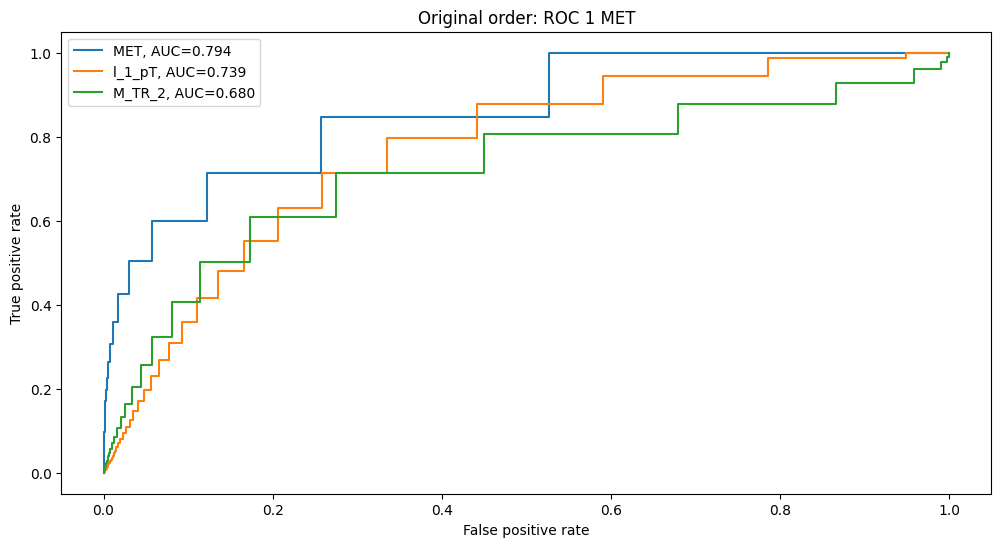

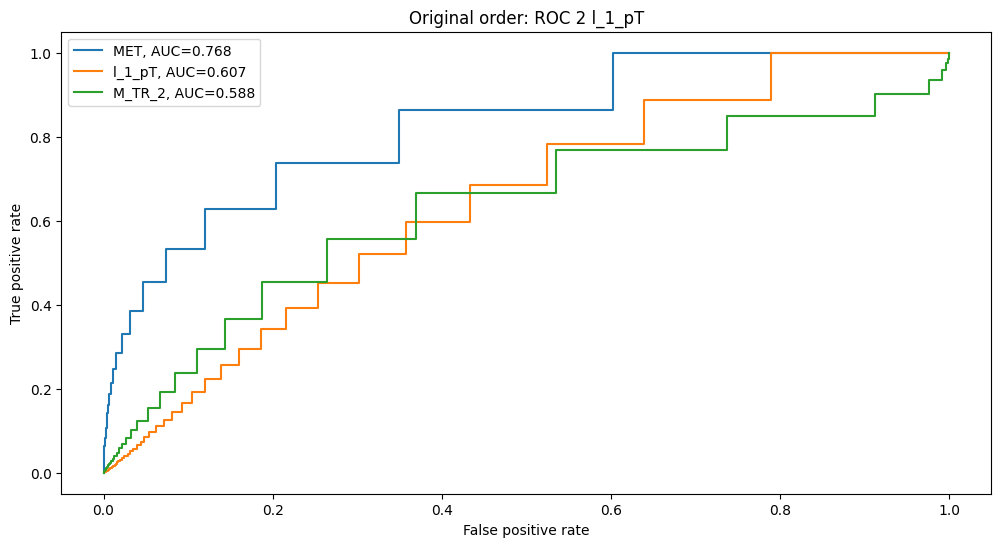

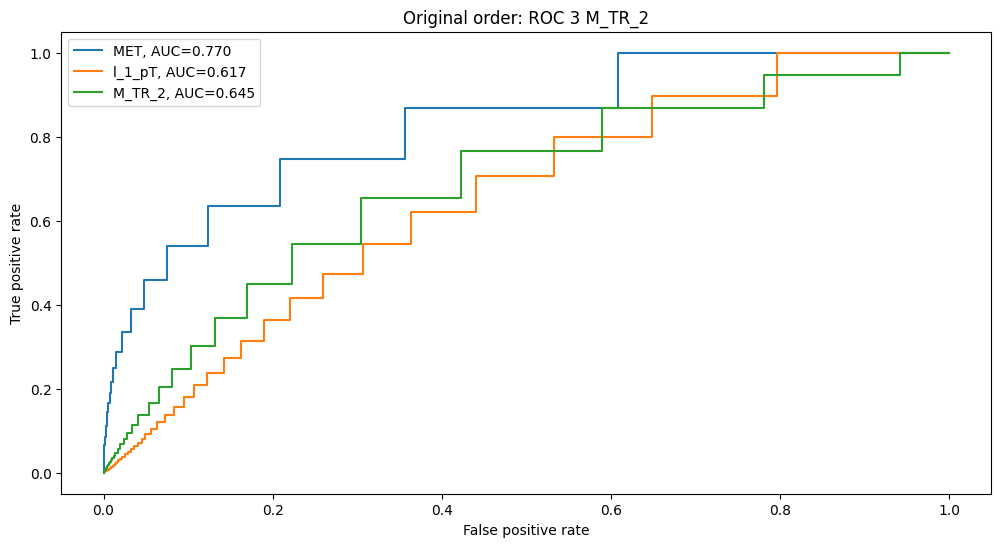

Reversed order


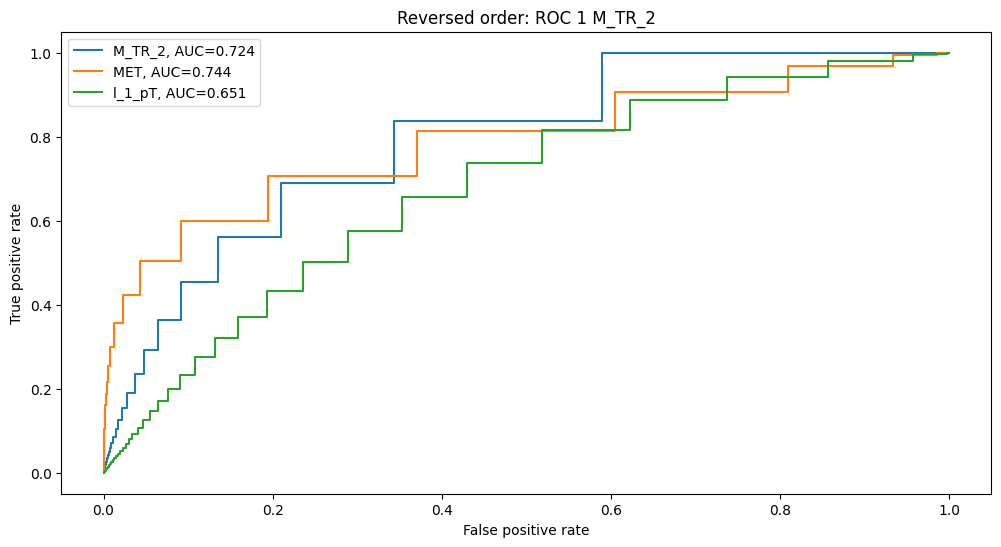

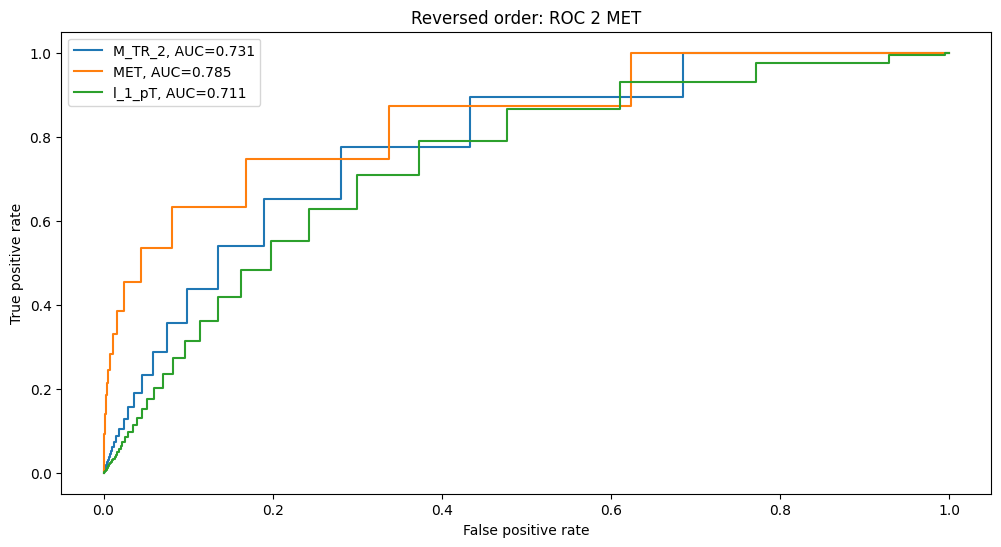

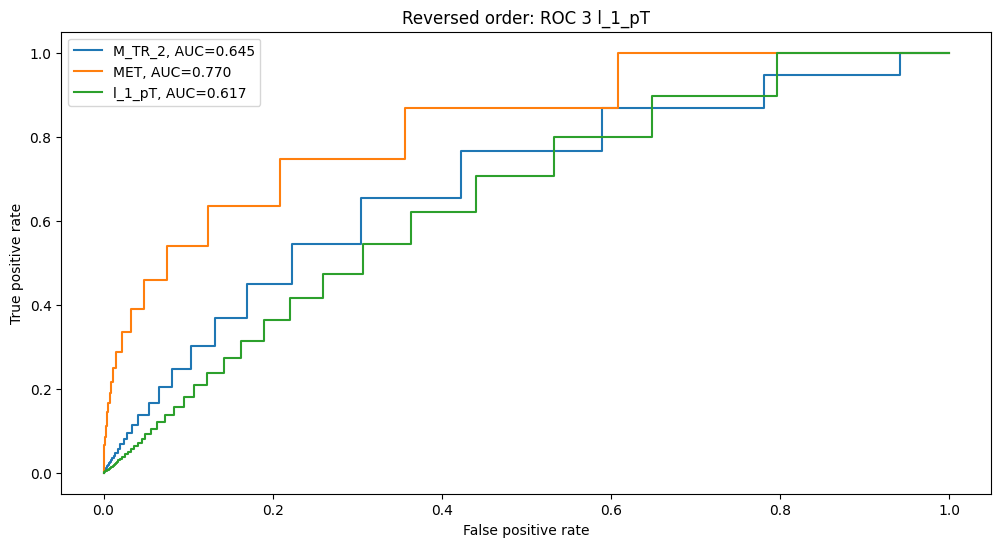

In [143]:
# 7.4
# Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.
ordered_pair = [("Original order", three_subsets), ("Reversed order", three_subsets.sort_index(ascending=False).reset_index(drop=True))]

for order_name, current_subsets in ordered_pair: # Loops through the original order and reserved order
    print(order_name)

    df_current = df.copy() # Starts with the full dataframe

    for i in range(len(current_subsets)): # Loops through selected observables
        variable = current_subsets["variable"].values[i] # Gets observable name
        selection_type = current_subsets["selection_type"].values[i] # Gets selection type

        xc = current_subsets["xc"].values[i] # Gets xc
        mu = current_subsets["mu"].values[i] # Gets mu

        current_selection = passes_selection(df_current, variable, selection_type, xc, mu) # Applies current selection

        df_current = df_current[current_selection].reset_index(drop=True) # Keeps rows that pass selection
        
        plot_roc_curve(df_current, current_subsets, title = f"{order_name}: ROC {i + 1} {variable}") # Uses 7.2's function & passes the title.

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [128]:
# 8.1
observables = FeatureNames # Uses the high-level features from earlier

signal_values = df[df["signal"] == 1][observables].to_numpy() # Grabs signal values for the selected observables
background_values = df[df["signal"] == 0][observables].to_numpy() # Grabs background values for the selected observables

signal_mean = np.mean(signal_values, axis=0) # The mean for signal
background_mean = np.mean(background_values, axis=0) # Mean for background

mean_difference = background_mean - signal_mean # Stores the difference between the background and signal means

S_B = np.outer(mean_difference, mean_difference) # Calculates the matrix between S_B

signal_centered = signal_values - signal_mean # Signal values minus the signal mean
background_centered = background_values - background_mean # Background values minus the background mean

S_W = signal_centered.T @ signal_centered + background_centered.T @ background_centered # Calculates the matrix within matrix S_W

print("S_B shape:", S_B.shape, "\nS_W shape:", S_W.shape) # Shows the sizes of S_B and S_W

S_B shape: (10, 10) 
S_W shape: (10, 10)


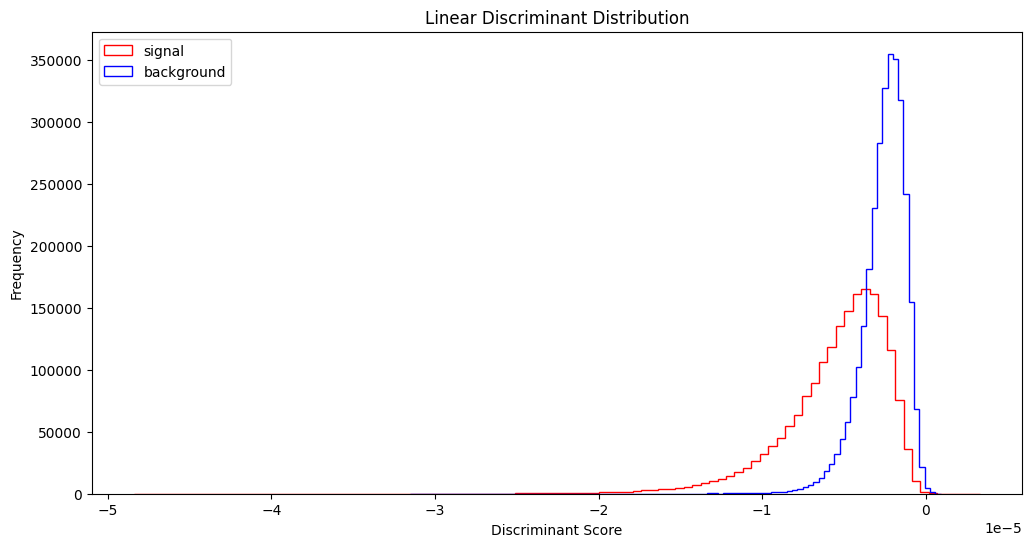

In [147]:
# 8.2
observables = FeatureNames # Using the same observables from 8.1
weights = np.linalg.solve(S_W, mean_difference) # Calculates the weight vector

all_values = df[observables].to_numpy() # Grabs all selected observable values

discriminant_score = all_values @ weights # Calculates F_n = w^T x_n

df["discriminant_score"] = discriminant_score # Stores projection values in dataframe

df_signal = df[df["signal"] == 1] # Gets signal rows
df_background = df[df["signal"] == 0] # Gets background rows

plt.figure(figsize=(12, 6)) # Creates the figure

plt.hist(np.array(df_signal["discriminant_score"]),bins=100,histtype="step",color="red",label="signal",density=True,stacked=True) # Plots signal discriminant_score

plt.hist(np.array(df_background["discriminant_score"]),bins=100,histtype="step",color="blue",label="background",density=True,stacked=True) # Plots background discriminant_score

plt.xlabel("Discriminant Score") 
plt.ylabel("Frequency")
plt.title("Linear Discriminant Distribution")
plt.legend()
plt.show()

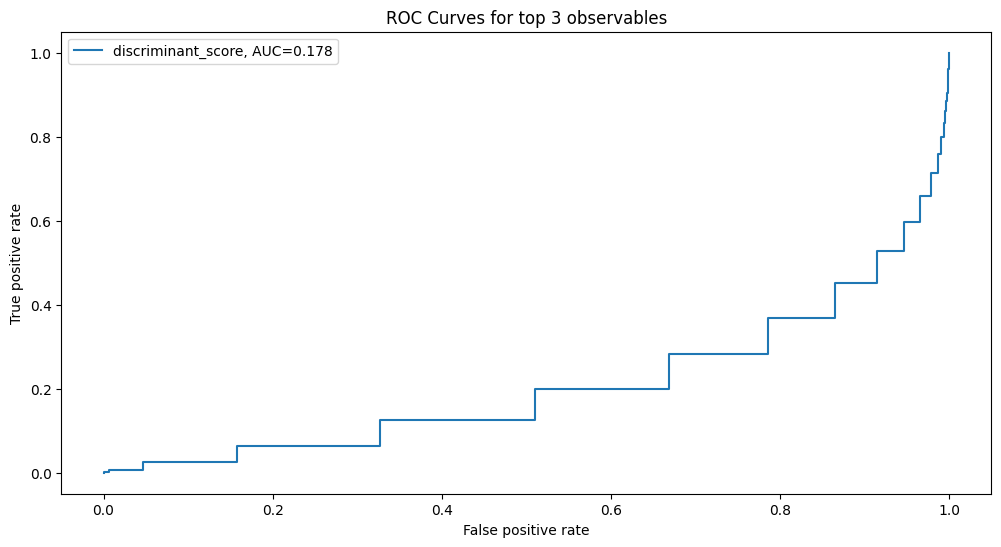

In [148]:
# 8.3
draw_roc = pd.DataFrame({"variable": ["discriminant_score"], "selection_type": ["x > xc"]}) 
# Creates a table so I can pass it into plot_roc_curve

plot_roc_curve(df, draw_roc) # Passes draw_roc into plot_roc_curve and executes.

In [150]:
# 8.4
max_significance_values = [] # Stores each scenario's ns nb xc and max significance values here so they can be turned into a table

for selection_type in ["x > xc", "x < xc"]: # Tests both directions
    xc_values, tpr_values, fpr_values = get_curve(df, "discriminant_score", selection_type, num_checks = 100) # Gets TPR/FPR curve for F_n
    
    for scenario_name in scenarios: # Loops through each scenario
        NS = scenarios[scenario_name][0] # Finds all signal events
        NB = scenarios[scenario_name][1] # Finds all Background events

        significance_values = get_significance(tpr_values, fpr_values, NS, NB) # Grabs the significance value for every xc

        max_index = np.argmax(significance_values) # Locates the xc that gives the highest significance

        max_significance_values.append([scenario_name, selection_type, NS,NB, xc_values[max_index], significance_values[max_index]]) # Finds the top value then adds it to the table.

max_significance = pd.DataFrame(max_significance_values, columns=["scenario", "selection_type", "N_S", "N_B", "best_xc", "max_significance"]) # Passes the stored results into a table

display(max_significance.round(4)) # Displays the table both ways. [x > xc and x < xc]

,scenario,selection_type,N_S,N_B,best_xc,max_significance
0,Scenario 1,x > xc,10,100,-0.0,0.9535
1,Scenario 2,x > xc,100,1000,-0.0,3.0151
2,Scenario 3,x > xc,1000,10000,-0.0,9.5346
3,Scenario 4,x > xc,10000,100000,-0.0,30.1511
4,Scenario 1,x < xc,10,100,-0.0,1.4881
5,Scenario 2,x < xc,100,1000,-0.0,4.7057
6,Scenario 3,x < xc,1000,10000,-0.0,14.8807
7,Scenario 4,x < xc,10000,100000,-0.0,47.0569
